In [2]:
from IPython import get_ipython
import winsound

def custom_exc(shell, etype, evalue, tb, tb_offset=None):
    # Play sound (frequency, duration)
    winsound.Beep(1000, 700)
    
    # Show the actual error
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)

get_ipython().set_custom_exc((Exception,), custom_exc)

# CMMA + LLM-HCG — FULL LOW‑LEVEL IMPLEMENTATION PIPELINE 
STAGE 0 — PREPARATION (DATA + CONCEPTS) 

This stage is critical because it ensures the new work is fully aligned with CLEF. 


# Step 0.1 — Load CLEF dataset (high‑dimensional medical tabular data)

#  Step 0.3 — Compute concept values 

Since we don’t reuse CLEF’s learned concept weights, we compute concept values like this: 

For each concept C: 

Standardize all features assigned to C. 

Compute the concept value as one of: 

mean of standardized features (simple, transparent) 

PCA first component (captures variation) 

clinician-agreed weighted sum (best if available) 

My recommendation (for simplicity and reproducibility in CMMA): 

Use z‑score mean of all features in the concept. 

Output of Stage 0 
✅ Concept-score vector C(x) for each patient 
✅ Concept dictionary (feature → concept mapping) 


In [3]:
!pip install openpyxl

In [4]:

#Load data
import pandas as pd
import numpy as np

df = pd.read_excel("Mortality.xlsx", engine="openpyxl")
print(df.shape)
df.head()

(35739, 71)


,studycode,dos,age,race,racewb,sex,weight,height,bmi,target_heart_rt,...,death,t_to_dth,lastseen,afib2,aflutter2,warfarin2,obesity2,sedentary2,FITDate,priorCVA
0,2777,1992-04-08,69.872688,Black,Black,Male,245.0,NaN,NaN,150.0,...,Yes,0.008214,1992-04-11,0,0,0,1.0,0.0,1992-04-08,0
1,40723,2002-09-20,48.933609,White,White,Male,195.0,NaN,NaN,171.0,...,Yes,0.010951,2002-09-24,0,0,0,0.0,1.0,2002-09-20,0
2,3716,1992-10-06,78.989731,Black,Black,Male,165.0,NaN,NaN,141.0,...,Yes,0.013689,1992-10-11,0,0,0,0.0,0.0,1992-10-06,0
3,45558,2003-06-27,56.654346,White,White,Male,165.0,70.0,23.674772,163.0,...,Yes,0.013689,2003-07-02,0,0,0,0.0,1.0,2003-06-27,0
4,16764,1996-12-05,66.713211,White,White,Male,138.0,NaN,NaN,153.0,...,Yes,0.016427,1996-12-11,0,0,0,0.0,0.0,1996-12-05,0


In [5]:
#Clean column names a little
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['studycode', 'dos', 'age', 'race', 'racewb', 'sex', 'weight', 'height', 'bmi', 'target_heart_rt', 'mets_achieved', 'mets_c', 'resting_heart_rt', 'resting_systolic', 'resting_diastolic', 'peak_heart_rt', 'peak_systolic', 'peak_diastolic', 'percent_hr_achieved', 'adequatestudy85', 'maximalstudy', 'norm_rest_ekg_flg', 'reason', 'amio', 'aspirin', 'bb', 'acei', 'arb', 'diuretic', 'ccb', 'other_htnmed', 'htnmed', 'statin', 'other_lipid', 'all_lipid', 'insulin', 'dmmed', 'depressionmed', 'smokingmeds', 'plavix', 'nitrates', 'edmeds', 'dig', 'lungdiseasemeds', 'thyroidmeds', 'htn', 'dm', 'hyperlipid', 'famhx', 'smoke', 'ldl', 'hdl', 'chol', 'vldl', 'tg', 'cr', 'a1c', 'hscrp', 'Hemoglobin', 'gfr', 'dod2013', 'death', 't_to_dth', 'lastseen', 'afib2', 'aflutter2', 'warfarin2', 'obesity2', 'sedentary2', 'FITDate', 'priorCVA']


In [6]:
concept_dict = {
    "Fitness": [
        "mets_achieved",
        "peak_systolic"
    ],

    "Hypertension": [
        "htn",
        "htnmed",
        "ccb",
        "diuretic",
        "arb",
        "acei",
        "bb"
    ],

    "Obesity/diabetes": [
        "bmi",
        "dm",
        "dmmed",
        "insulin",
        "a1c"
    ],

    "Dyslipidemia": [
        "bmi",
        "statin",
        "hyperlipid",
        "ldl",
        "hdl",
        "chol",
        "tg"
    ],

    "Cardiometabolic": [
        "bmi",
        "dm",
        "dmmed",
        "insulin",
        "a1c",
        "statin",
        "hyperlipid",
        "ldl",
        "hdl",
        "chol",
        "tg"
    ]
}

In [7]:
# Check whether all columns exist
for concept, cols in concept_dict.items():
    missing_cols = [c for c in cols if c not in df.columns]
    if missing_cols:
        print(f"{concept} is missing columns: {missing_cols}")
    else:
        print(f"{concept} OK")

Fitness OK
Hypertension OK
Obesity/diabetes OK
Dyslipidemia OK
Cardiometabolic OK


In [8]:
# Convert concept columns safely for Stage 0 concept-score computation

all_concept_cols = sorted(set(sum(concept_dict.values(), [])))

for col in all_concept_cols:
    if col not in df.columns:
        continue

    # If already numeric, keep as is
    if pd.api.types.is_numeric_dtype(df[col]):
        continue

    # Clean strings
    s = df[col].astype(str).str.strip().str.lower()

    # Map common binary text values
    binary_map = {
        "yes": 1, "no": 0,
        "y": 1, "n": 0,
        "true": 1, "false": 0,
        "1": 1, "0": 0, 
       
    }

    mapped = s.map(binary_map)

    # If binary mapping worked, use it
    if mapped.notna().sum() > 0:
        df[col] = mapped
    else:
        # Otherwise try numeric conversion
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
check_cols = ['bb', 'acei', 'arb', 'diuretic', 'ccb', 'htnmed',
              'statin', 'insulin', 'dmmed', 'htn', 'dm', 'hyperlipid']

print(df[check_cols].head())
print(df[check_cols].isnull().all())
print(df[check_cols].dtypes)

   bb  acei  arb  diuretic  ccb  htnmed  statin  insulin  dmmed  htn  dm  \
0   0     0    0         0    1       1       0        0      0    1   0   
1   0     0    0         0    1       1       0        0      0    1   0   
2   1     0    0         0    0       1       0        0      0    1   0   
3   0     0    0         0    0       0       1        0      0    0   0   
4   0     0    0         0    1       1       0        0      0    1   0   

   hyperlipid  
0           1  
1           1  
2           0  
3           1  
4           0  
bb            False
acei          False
arb           False
diuretic      False
ccb           False
htnmed        False
statin        False
insulin       False
dmmed         False
htn           False
dm            False
hyperlipid    False
dtype: bool
bb            int64
acei          int64
arb           int64
diuretic      int64
ccb           int64
htnmed        int64
statin        int64
insulin       int64
dmmed         int64
htn           i

In [10]:
#Standardize each variable with z-score
# here only those features are standardized who are used for building concepts 
z_df = pd.DataFrame(index=df.index)

for col in all_concept_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    if pd.isna(std_val) or std_val == 0:
        z_df[col + "_z"] = np.nan
    else:
        z_df[col + "_z"] = (df[col] - mean_val) / std_val

z_df.head(10)

,a1c_z,acei_z,arb_z,bb_z,bmi_z,ccb_z,chol_z,diuretic_z,dm_z,dmmed_z,hdl_z,htn_z,htnmed_z,hyperlipid_z,insulin_z,ldl_z,mets_achieved_z,peak_systolic_z,statin_z,tg_z
0,NaN,-0.411661,-0.124555,-0.435964,NaN,2.511358,NaN,-0.437554,-0.444976,-0.270214,NaN,0.811753,1.182263,1.237790,-0.191083,NaN,-0.674720,-0.109999,-0.387932,NaN
1,NaN,-0.411661,-0.124555,-0.435964,NaN,2.511358,NaN,-0.437554,-0.444976,-0.270214,NaN,0.811753,1.182263,1.237790,-0.191083,NaN,-0.674720,1.814105,-0.387932,NaN
2,NaN,-0.411661,-0.124555,2.293701,NaN,-0.398180,NaN,-0.437554,-0.444976,-0.270214,NaN,0.811753,1.182263,-0.807869,-0.191083,NaN,-0.674720,-2.404123,-0.387932,NaN
3,NaN,-0.411661,-0.124555,-0.435964,-0.958258,-0.398180,NaN,-0.437554,-0.444976,-0.270214,0.533567,-1.231868,-0.845811,1.237790,-0.191083,NaN,-0.674720,-3.070159,2.577697,NaN
4,-0.828405,-0.411661,-0.124555,-0.435964,NaN,2.511358,0.947766,-0.437554,-0.444976,-0.270214,-0.772993,0.811753,1.182263,-0.807869,-0.191083,1.343770,-2.208279,-1.146055,-0.387932,-0.072457
5,0.425657,2.429113,-0.124555,2.293701,NaN,-0.398180,-0.213016,-0.437554,2.247251,3.700666,-0.968977,0.811753,1.182263,1.237790,-0.191083,-0.001711,-1.300662,-0.406015,2.577697,0.257381
6,NaN,-0.411661,-0.124555,2.293701,NaN,-0.398180,NaN,-0.437554,2.247251,-0.270214,NaN,0.811753,1.182263,-0.807869,5.233168,NaN,1.171811,-0.109999,-0.387932,NaN
7,NaN,-0.411661,-0.124555,-0.435964,1.730452,-0.398180,0.568735,-0.437554,-0.444976,-0.270214,NaN,-1.231868,-0.845811,-0.807869,-0.191083,NaN,0.264195,-0.702031,-0.387932,NaN
8,NaN,-0.411661,-0.124555,-0.435964,NaN,-0.398180,NaN,-0.437554,-0.444976,-0.270214,NaN,0.811753,-0.845811,-0.807869,-0.191083,NaN,NaN,1.000061,-0.387932,NaN
9,NaN,-0.411661,-0.124555,-0.435964,NaN,-0.398180,NaN,-0.437554,2.247251,-0.270214,NaN,0.811753,-0.845811,-0.807869,5.233168,NaN,-2.208279,-3.070159,-0.387932,NaN


In [11]:
# Compute concept scores as row-wise mean of z-scores
for concept, cols in concept_dict.items():
    z_cols = [col + "_z" for col in cols]
    df[concept] = z_df[z_cols].mean(axis=1, skipna=True)

concept_score_cols = list(concept_dict.keys())
df[concept_score_cols].head()

,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic
0,-0.392359,0.442234,-0.302091,0.424929,-0.011283
1,0.569693,0.442234,-0.302091,0.424929,-0.011283
2,-1.539421,0.416538,-0.302091,-0.597901,-0.420415
3,-1.872439,-0.555085,-0.466133,0.847699,0.354932
4,-1.677167,0.442234,-0.433670,0.041714,-0.148439


In [12]:
# Check missingness in concept scores
concept_missing = df[concept_score_cols].isnull().mean().sort_values(ascending=False) * 100
print(concept_missing)
#This is very important. It tells us whether the concept scores are usable.

Fitness             0.069952
Hypertension        0.000000
Obesity/diabetes    0.000000
Dyslipidemia        0.000000
Cardiometabolic     0.000000
dtype: float64


In [13]:
# Quick summary of concept distributions
df[concept_score_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Fitness,35714.0,-5.543986e-03,0.729276,-3.810199,-0.462284,0.055744,0.526508,2.820632
Hypertension,35739.0,3.181030e-17,0.603009,-0.555085,-0.555085,-0.263139,0.432411,2.791699
Obesity/diabetes,35739.0,-3.269317e-02,0.649889,-1.049493,-0.302091,-0.302091,-0.071900,4.051242
Dyslipidemia,35739.0,-3.520431e-02,0.532963,-1.769441,-0.456214,-0.091765,0.314837,9.041014
Cardiometabolic,35739.0,-2.082253e-02,0.439944,-1.280325,-0.366069,-0.089421,0.204719,6.828477


In [14]:
# Save dataset with concept scores
output_path = "Mortality_with_concepts.xlsx"
df.to_excel(output_path, index=False)

print(f"Saved file to: {output_path}")


Saved file to: Mortality_with_concepts.xlsx


# STAGE 1 — TRAIN THE PREDICTIVE MODEL (INTERPRETABLE) 

Because CLEF used interpretable models (decision trees)


In [15]:
# Reload the saved concept dataset
import pandas as pd
import numpy as np

file_path = "Mortality_with_concepts.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

print(df.shape)
df.head()

(35739, 76)


,studycode,dos,age,race,racewb,sex,weight,height,bmi,target_heart_rt,...,warfarin2,obesity2,sedentary2,FITDate,priorCVA,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic
0,2777,1992-04-08,69.872688,Black,Black,Male,245.0,NaN,NaN,150.0,...,0,1.0,0.0,1992-04-08,0,-0.392359,0.442234,-0.302091,0.424929,-0.011283
1,40723,2002-09-20,48.933609,White,White,Male,195.0,NaN,NaN,171.0,...,0,0.0,1.0,2002-09-20,0,0.569693,0.442234,-0.302091,0.424929,-0.011283
2,3716,1992-10-06,78.989731,Black,Black,Male,165.0,NaN,NaN,141.0,...,0,0.0,0.0,1992-10-06,0,-1.539421,0.416538,-0.302091,-0.597901,-0.420415
3,45558,2003-06-27,56.654346,White,White,Male,165.0,70.0,23.674772,163.0,...,0,0.0,1.0,2003-06-27,0,-1.872439,-0.555085,-0.466133,0.847699,0.354932
4,16764,1996-12-05,66.713211,White,White,Male,138.0,NaN,NaN,153.0,...,0,0.0,0.0,1996-12-05,0,-1.677167,0.442234,-0.433670,0.041714,-0.148439


In [16]:
# Inspect target values
print(df["death"].value_counts(dropna=False))
print(df["death"].dtype)

death
No     31559
Yes     4180
Name: count, dtype: int64
str


In [17]:
# Convert target to binary if needed
df["death"] = df["death"].astype(str).str.strip().str.lower()

target_map = {
    "yes": 1,
    "no": 0,
    "1": 1,
    "0": 0,
    "true": 1,
    "false": 0
}

df["death_binary"] = df["death"].map(target_map)

print(df["death_binary"].value_counts(dropna=False))

death_binary
0    31559
1     4180
Name: count, dtype: int64


In [18]:
# Drop rows with missing target
df = df.dropna(subset=["death_binary"]).copy()
df["death_binary"] = df["death_binary"].astype(int)

print(df.shape)
print(df["death_binary"].value_counts())

(35739, 77)
death_binary
0    31559
1     4180
Name: count, dtype: int64


In [19]:
# CLEF-aligned concept score columns
concept_score_cols = [
    "Fitness",
    "Hypertension",
    "Obesity/diabetes",
    "Dyslipidemia",
    "Cardiometabolic"
]

exclude_cols = [
    "studycode", "death", "death_binary", "dod2013",
    "t_to_dth", "lastseen", "dos", "FITDate"
] + concept_score_cols

feature_cols = [c for c in df.columns if c not in exclude_cols]

In [20]:
print("Any concept columns leaking into training features?")
print(set(concept_score_cols).intersection(set(feature_cols)))
print("Number of raw training features:", len(feature_cols))

Any concept columns leaking into training features?
set()
Number of raw training features: 64


In [21]:
#Build raw feature matrix
X = df.drop(columns=[col for col in exclude_cols if col in df.columns]).copy()
y = df["death_binary"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.columns.tolist())

X shape: (35739, 64)
y shape: (35739,)
['age', 'race', 'racewb', 'sex', 'weight', 'height', 'bmi', 'target_heart_rt', 'mets_achieved', 'mets_c', 'resting_heart_rt', 'resting_systolic', 'resting_diastolic', 'peak_heart_rt', 'peak_systolic', 'peak_diastolic', 'percent_hr_achieved', 'adequatestudy85', 'maximalstudy', 'norm_rest_ekg_flg', 'reason', 'amio', 'aspirin', 'bb', 'acei', 'arb', 'diuretic', 'ccb', 'other_htnmed', 'htnmed', 'statin', 'other_lipid', 'all_lipid', 'insulin', 'dmmed', 'depressionmed', 'smokingmeds', 'plavix', 'nitrates', 'edmeds', 'dig', 'lungdiseasemeds', 'thyroidmeds', 'htn', 'dm', 'hyperlipid', 'famhx', 'smoke', 'ldl', 'hdl', 'chol', 'vldl', 'tg', 'cr', 'a1c', 'hscrp', 'Hemoglobin', 'gfr', 'afib2', 'aflutter2', 'warfarin2', 'obesity2', 'sedentary2', 'priorCVA']


In [22]:
# Drop columns that are completely missing
all_missing_cols = [col for col in X.columns if X[col].isnull().all()]

print("All-missing columns:", all_missing_cols)
print("Count:", len(all_missing_cols))

X = X.drop(columns=all_missing_cols).copy()

# Recompute column groups after dropping them
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Updated numeric columns:", len(numeric_cols))
print("Updated categorical columns:", len(categorical_cols))

All-missing columns: []
Count: 0
Updated numeric columns: 45
Updated categorical columns: 19


In [23]:
#Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Categorical:", categorical_cols)

Numeric columns: 45
Categorical columns: 19
Categorical: ['race', 'racewb', 'sex', 'reason', 'amio', 'aspirin', 'other_htnmed', 'other_lipid', 'all_lipid', 'depressionmed', 'smokingmeds', 'plavix', 'nitrates', 'edmeds', 'dig', 'lungdiseasemeds', 'thyroidmeds', 'famhx', 'smoke']


In [24]:
#Simple preprocessing

#For a decision tree:

#numeric missing values -> median
#categorical missing values -> most frequent
#categorical -> one-hot encode
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [25]:
#Split into train, validation, and test, 60/20/20
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (21443, 64) (21443,)
Val: (7148, 64) (7148,)
Test: (7148, 64) (7148,)


In [26]:
#Train a simple interpretable decision tree
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=100,
        random_state=42,
        class_weight="balanced"
    ))
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [27]:
#Validate the model
val_pred = clf.predict(X_val)
val_proba = clf.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_proba))
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.7916899832120873
Validation ROC-AUC: 0.8113393604344425
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      6312
           1       0.32      0.69      0.44       836

    accuracy                           0.79      7148
   macro avg       0.64      0.75      0.65      7148
weighted avg       0.88      0.79      0.82      7148



In [28]:
#Test the model
test_pred = clf.predict(X_test)
test_proba = clf.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))
print(classification_report(y_test, test_pred))

Test Accuracy: 0.7923894795747062
Test ROC-AUC: 0.8109468901037592
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      6312
           1       0.32      0.69      0.44       836

    accuracy                           0.79      7148
   macro avg       0.64      0.75      0.66      7148
weighted avg       0.88      0.79      0.82      7148



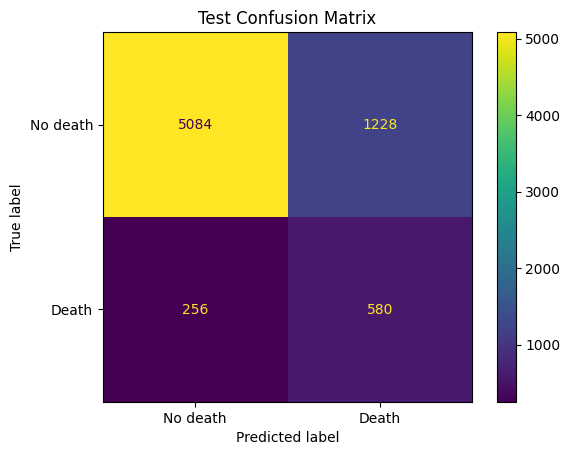

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No death", "Death"])
disp.plot()
plt.title("Test Confusion Matrix")
plt.show()

In [30]:
# Save the trained pipeline cell 32
import joblib

joblib.dump(clf, "decision_tree_mortality.pkl")
print("Model saved as decision_tree_mortality.pkl")

Model saved as decision_tree_mortality.pkl


In [31]:
import itertools
import networkx as nx
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from causallearn.search.ConstraintBased.PC import pc

In [32]:
def pc_graph_to_edge_df(cg, col_names):
    rows = []

    name_map = {f"X{i+1}": col for i, col in enumerate(col_names)}

    for edge in cg.G.get_graph_edges():
        n1_raw = edge.get_node1().get_name()
        n2_raw = edge.get_node2().get_name()

        n1 = name_map.get(n1_raw, n1_raw)
        n2 = name_map.get(n2_raw, n2_raw)

        ep1 = str(edge.get_endpoint1())
        ep2 = str(edge.get_endpoint2())

        edge_type = "undirected"
        source = None
        target = None

        if ep1 == "TAIL" and ep2 == "ARROW":
            edge_type = "directed"
            source, target = n1, n2
        elif ep1 == "ARROW" and ep2 == "TAIL":
            edge_type = "directed"
            source, target = n2, n1

        rows.append({
            "node1": n1,
            "node2": n2,
            "endpoint1": ep1,
            "endpoint2": ep2,
            "edge_type": edge_type,
            "source": source,
            "target": target
        })

    return pd.DataFrame(rows)

 # STAGE 2 — EXTRACT THE MODEL CAUSAL GRAPH (MCG)
 This is the graph that reflects how the ML model behaves causally in the concept space. 

## Step 2.1. Concept-level interventional probing


In [33]:
concept_dict = {
    "Fitness": [
        "mets_achieved",
        "peak_systolic"
    ],

    "Hypertension": [
        "htn",
        "htnmed",
        "ccb",
        "diuretic",
        "arb",
        "acei",
        "bb"
    ],

    "Obesity/diabetes": [
        "bmi",
        "dm",
        "dmmed",
        "insulin",
        "a1c"
    ],

    "Dyslipidemia": [
        "bmi",
        "statin",
        "hyperlipid",
        "ldl",
        "hdl",
        "chol",
        "tg"
    ],

    "Cardiometabolic": [
        "bmi",
        "dm",
        "dmmed",
        "insulin",
        "a1c",
        "statin",
        "hyperlipid",
        "ldl",
        "hdl",
        "chol",
        "tg"
    ]
}

In [34]:
# Keep only concept features that actually exist in X
concept_dict_X = {}
for concept, cols in concept_dict.items():
    available_cols = [c for c in cols if c in X.columns]
    concept_dict_X[concept] = available_cols

for concept, cols in concept_dict_X.items():
    print(concept, "->", cols)

Fitness -> ['mets_achieved', 'peak_systolic']
Hypertension -> ['htn', 'htnmed', 'ccb', 'diuretic', 'arb', 'acei', 'bb']
Obesity/diabetes -> ['bmi', 'dm', 'dmmed', 'insulin', 'a1c']
Dyslipidemia -> ['bmi', 'statin', 'hyperlipid', 'ldl', 'hdl', 'chol', 'tg']
Cardiometabolic -> ['bmi', 'dm', 'dmmed', 'insulin', 'a1c', 'statin', 'hyperlipid', 'ldl', 'hdl', 'chol', 'tg']


In [35]:
# Compute training standard deviations for intervention size. 1SD means 12.96 years for age intervention.
#  This will likely be used to decide how much to perturb/intervene on each feature.
train_std = X_train.std(numeric_only=True)

print(train_std.head())

age                12.962161
weight             40.862425
height              4.096859
bmi                 5.862744
target_heart_rt    12.965162
dtype: float64


In [36]:
def intervene_on_concept(X_df, concept_name, alpha, concept_dict_X, concept_feature_stats):
    X_new = X_df.copy()

    for col in concept_dict_X[concept_name]:
        if col not in X_new.columns:
            continue
        if col not in concept_feature_stats:
            continue
        if not pd.api.types.is_numeric_dtype(X_new[col]):
            continue

        std_val = concept_feature_stats[col]["std"]

        if pd.isna(std_val) or std_val == 0:
            continue

        X_new[col] = X_new[col] + alpha * std_val

    return X_new

In [37]:
concept_feature_stats = {}

all_concept_features = sorted(set(sum(concept_dict_X.values(), [])))

for col in all_concept_features:
    if col in X_train.columns and pd.api.types.is_numeric_dtype(X_train[col]):
        concept_feature_stats[col] = {
            "mean": X_train[col].mean(),
            "std": X_train[col].std()
        }

concept_feature_stats

{'a1c': {'mean': np.float64(7.189224141151056),
  'std': np.float64(1.9277303440056694)},
 'acei': {'mean': np.float64(0.14498904071258686),
  'std': np.float64(0.3520979981477108)},
 'arb': {'mean': np.float64(0.014596838128993145),
  'std': np.float64(0.11993515442883283)},
 'bb': {'mean': np.float64(0.1607051252156881),
  'std': np.float64(0.3672673118532033)},
 'bmi': {'mean': np.float64(29.232546723709802),
  'std': np.float64(5.862743771618214)},
 'ccb': {'mean': np.float64(0.135475446532668),
  'std': np.float64(0.34223867721628637)},
 'chol': {'mean': np.float64(209.77427722237232),
  'std': np.float64(42.16597724014981)},
 'diuretic': {'mean': np.float64(0.16028540782539757),
  'std': np.float64(0.36687909859124207)},
 'dm': {'mean': np.float64(0.165322016508884),
  'std': np.float64(0.37147958611063886)},
 'dmmed': {'mean': np.float64(0.06813412302383062),
  'std': np.float64(0.2519817957743182)},
 'hdl': {'mean': np.float64(49.876084673630686),
  'std': np.float64(15.2148773

In [38]:
# Baseline predictions on test set on class 1
baseline_proba = clf.predict_proba(X_test)[:, 1]
print("Baseline mean predicted mortality:", baseline_proba.mean())

Baseline mean predicted mortality: 0.3708058433170031


In [39]:
# Intervene low and high for each concept
# If ace is positive:
# Higher concept value increases predicted mortality
# If ace is negative:
# Higher concept value decreases predicted mortality
# If ace is zero:
# The model prediction does not change under that concept intervention

baseline_proba = clf.predict_proba(X_test)[:, 1]

concept_effects = []

for concept, cols in concept_dict_X.items():
    X_low = intervene_on_concept(X_test, concept, -2.0, concept_dict_X, concept_feature_stats)
    X_high = intervene_on_concept(X_test, concept, +2.0, concept_dict_X, concept_feature_stats)

    proba_low = clf.predict_proba(X_low)[:, 1]
    proba_high = clf.predict_proba(X_high)[:, 1]

    ace = proba_high.mean() - proba_low.mean()

    concept_effects.append({
        "concept": concept,
        "baseline_mean_proba": baseline_proba.mean(),
        "low_mean_proba": proba_low.mean(),
        "high_mean_proba": proba_high.mean(),
        "ACE_high_minus_low": ace
    })

concept_effects_df = pd.DataFrame(concept_effects).sort_values(
    by="ACE_high_minus_low",
    ascending=False
)

concept_effects_df

,concept,baseline_mean_proba,low_mean_proba,high_mean_proba,ACE_high_minus_low
1,Hypertension,0.370806,0.370806,0.370806,0.000000
3,Dyslipidemia,0.370806,0.372754,0.369155,-0.003599
2,Obesity/diabetes,0.370806,0.372754,0.369155,-0.003599
4,Cardiometabolic,0.370806,0.372754,0.369155,-0.003599
0,Fitness,0.370806,0.555224,0.291355,-0.263869


In [40]:
alpha_grid = [-2, -1, 0, 1, 2]

grid_records = []

for concept, cols in concept_dict_X.items():
    for alpha in alpha_grid:
        X_do = intervene_on_concept(X_test, concept, alpha, concept_dict_X, concept_feature_stats)
        proba_do = clf.predict_proba(X_do)[:, 1]

        grid_records.append({
            "concept": concept,
            "alpha": alpha,
            "mean_predicted_proba": proba_do.mean()
        })

concept_grid_df = pd.DataFrame(grid_records)
concept_grid_df

,concept,alpha,mean_predicted_proba
0,Fitness,-2,0.555224
1,Fitness,-1,0.464073
2,Fitness,0,0.370806
3,Fitness,1,0.306944
4,Fitness,2,0.291355
5,Hypertension,-2,0.370806
6,Hypertension,-1,0.370806
7,Hypertension,0,0.370806
8,Hypertension,1,0.370806
9,Hypertension,2,0.370806


In [41]:
# Absolute effect ranking rank concept by strength of effect
concept_effects_df["abs_ACE"] = concept_effects_df["ACE_high_minus_low"].abs()
concept_effects_df = concept_effects_df.sort_values(by="abs_ACE", ascending=False)

concept_effects_df

,concept,baseline_mean_proba,low_mean_proba,high_mean_proba,ACE_high_minus_low,abs_ACE
0,Fitness,0.370806,0.555224,0.291355,-0.263869,0.263869
2,Obesity/diabetes,0.370806,0.372754,0.369155,-0.003599,0.003599
3,Dyslipidemia,0.370806,0.372754,0.369155,-0.003599,0.003599
4,Cardiometabolic,0.370806,0.372754,0.369155,-0.003599,0.003599
1,Hypertension,0.370806,0.370806,0.370806,0.000000,0.000000


In [42]:
#Save the concept effects
concept_effects_df.to_excel("stage2_concept_direct_effects.xlsx", index=False)
print("Saved: stage2_concept_direct_effects.xlsx")

Saved: stage2_concept_direct_effects.xlsx


## Step 2.2: Build concept-to-concept influence matrix

In [43]:
concept_feature_stats = {}

all_concept_features = sorted(set(sum(concept_dict_X.values(), [])))

for col in all_concept_features:
    if col in X_train.columns and pd.api.types.is_numeric_dtype(X_train[col]):
        concept_feature_stats[col] = {
            "mean": X_train[col].mean(),
            "std": X_train[col].std()
        }

concept_feature_stats

{'a1c': {'mean': np.float64(7.189224141151056),
  'std': np.float64(1.9277303440056694)},
 'acei': {'mean': np.float64(0.14498904071258686),
  'std': np.float64(0.3520979981477108)},
 'arb': {'mean': np.float64(0.014596838128993145),
  'std': np.float64(0.11993515442883283)},
 'bb': {'mean': np.float64(0.1607051252156881),
  'std': np.float64(0.3672673118532033)},
 'bmi': {'mean': np.float64(29.232546723709802),
  'std': np.float64(5.862743771618214)},
 'ccb': {'mean': np.float64(0.135475446532668),
  'std': np.float64(0.34223867721628637)},
 'chol': {'mean': np.float64(209.77427722237232),
  'std': np.float64(42.16597724014981)},
 'diuretic': {'mean': np.float64(0.16028540782539757),
  'std': np.float64(0.36687909859124207)},
 'dm': {'mean': np.float64(0.165322016508884),
  'std': np.float64(0.37147958611063886)},
 'dmmed': {'mean': np.float64(0.06813412302383062),
  'std': np.float64(0.2519817957743182)},
 'hdl': {'mean': np.float64(49.876084673630686),
  'std': np.float64(15.2148773

In [44]:
# New fixed-score function
def compute_concept_scores_fixed(df_input, concept_dict, feature_stats):
    df_temp = df_input.copy()
    concept_scores = pd.DataFrame(index=df_temp.index)

    for concept, cols in concept_dict.items():
        available_cols = [c for c in cols if c in df_temp.columns and c in feature_stats]

        if len(available_cols) == 0:
            concept_scores[concept] = np.nan
            continue

        z_block = pd.DataFrame(index=df_temp.index)

        for col in available_cols:
            if pd.api.types.is_numeric_dtype(df_temp[col]):
                mean_val = feature_stats[col]["mean"]
                std_val = feature_stats[col]["std"]

                if pd.notna(std_val) and std_val > 0:
                    z_block[col] = (df_temp[col] - mean_val) / std_val
                else:
                    z_block[col] = np.nan
            else:
                z_block[col] = np.nan

        concept_scores[concept] = z_block.mean(axis=1, skipna=True)

    return concept_scores

In [45]:
# Baseline concept scores on test set
baseline_concepts_test = compute_concept_scores_fixed(X_test, concept_dict_X, concept_feature_stats)
baseline_concepts_test.head()

,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic
31239,1.046449,-0.553984,-0.301759,-0.765424,-0.610869
5056,-0.461643,0.416815,-0.328696,-0.361411,-0.343515
31692,0.093181,-0.553984,-0.138862,-0.048921,-0.124772
18111,0.463872,-0.553984,0.147901,-0.111763,-0.168762
26968,0.534080,0.417226,0.076791,-0.082483,-0.148266


In [46]:
# Recompute concept-to-concept changes correctly
concept_edge_records = []

for source_concept, source_cols in concept_dict_X.items():
    X_low = intervene_on_concept(X_test, source_concept, -2.0, concept_dict_X, concept_feature_stats)
    X_high = intervene_on_concept(X_test, source_concept, +2.0, concept_dict_X, concept_feature_stats)

    concepts_low = compute_concept_scores_fixed(X_low, concept_dict_X, concept_feature_stats)
    concepts_high = compute_concept_scores_fixed(X_high, concept_dict_X, concept_feature_stats)

    for target_concept in concept_dict_X.keys():
        low_mean = concepts_low[target_concept].mean()
        high_mean = concepts_high[target_concept].mean()
        delta = high_mean - low_mean

        concept_edge_records.append({
            "source_concept": source_concept,
            "target_concept": target_concept,
            "low_mean_target_score": low_mean,
            "high_mean_target_score": high_mean,
            "delta_high_minus_low": delta,
            "abs_delta": abs(delta)
        })

concept_edges_df = pd.DataFrame(concept_edge_records)
concept_edges_df.head(10)

,source_concept,target_concept,low_mean_target_score,high_mean_target_score,delta_high_minus_low,abs_delta
0,Fitness,Fitness,-2.005293,1.994707,4.0,4.0
1,Fitness,Hypertension,0.003252,0.003252,0.0,0.0
2,Fitness,Obesity/diabetes,-0.020651,-0.020651,0.0,0.0
3,Fitness,Dyslipidemia,-0.036651,-0.036651,0.0,0.0
4,Fitness,Cardiometabolic,-0.016668,-0.016668,0.0,0.0
5,Hypertension,Fitness,-0.005293,-0.005293,0.0,0.0
6,Hypertension,Hypertension,-1.996748,2.003252,4.0,4.0
7,Hypertension,Obesity/diabetes,-0.020651,-0.020651,0.0,0.0
8,Hypertension,Dyslipidemia,-0.036651,-0.036651,0.0,0.0
9,Hypertension,Cardiometabolic,-0.016668,-0.016668,0.0,0.0


In [47]:
# Off-diagonal edges
offdiag_edges_df = concept_edges_df[
    concept_edges_df["source_concept"] != concept_edges_df["target_concept"]
].copy()

offdiag_edges_df = offdiag_edges_df.sort_values(by="abs_delta", ascending=False)
offdiag_edges_df.head(20)

,source_concept,target_concept,low_mean_target_score,high_mean_target_score,delta_high_minus_low,abs_delta
22,Cardiometabolic,Obesity/diabetes,-2.020651,1.979349,4.000000,4.000000
23,Cardiometabolic,Dyslipidemia,-2.036651,1.963349,4.000000,4.000000
19,Dyslipidemia,Cardiometabolic,-1.284156,1.250821,2.534976,2.534976
14,Obesity/diabetes,Cardiometabolic,-0.864474,0.831139,1.695613,1.695613
17,Dyslipidemia,Obesity/diabetes,-0.293007,0.251705,0.544712,0.544712
13,Obesity/diabetes,Dyslipidemia,-0.208878,0.135576,0.344455,0.344455
2,Fitness,Obesity/diabetes,-0.020651,-0.020651,0.000000,0.000000
1,Fitness,Hypertension,0.003252,0.003252,0.000000,0.000000
4,Fitness,Cardiometabolic,-0.016668,-0.016668,0.000000,0.000000
3,Fitness,Dyslipidemia,-0.036651,-0.036651,0.000000,0.000000


In [48]:
# Adjacency matrix. Fitness have no common features from others. 
adjacency_matrix = offdiag_edges_df.pivot(
    index="source_concept",
    columns="target_concept",
    values="delta_high_minus_low"
)

adjacency_matrix

target_concept,Cardiometabolic,Dyslipidemia,Fitness,Hypertension,Obesity/diabetes
source_concept,,,,,
Cardiometabolic,NaN,4.000000,0.0,0.0,4.000000
Dyslipidemia,2.534976,NaN,0.0,0.0,0.544712
Fitness,0.000000,0.000000,NaN,0.0,0.000000
Hypertension,0.000000,0.000000,0.0,NaN,0.000000
Obesity/diabetes,1.695613,0.344455,0.0,0.0,NaN


## Step 2.3 & 2.4

In [49]:
#Start from the direct effects table.
# MCG construction by using concept effects and 
# then building a linear surrogate model that approximates the trained decision tree’s predictions using concept scores.
concept_effects_df

,concept,baseline_mean_proba,low_mean_proba,high_mean_proba,ACE_high_minus_low,abs_ACE
0,Fitness,0.370806,0.555224,0.291355,-0.263869,0.263869
2,Obesity/diabetes,0.370806,0.372754,0.369155,-0.003599,0.003599
3,Dyslipidemia,0.370806,0.372754,0.369155,-0.003599,0.003599
4,Cardiometabolic,0.370806,0.372754,0.369155,-0.003599,0.003599
1,Hypertension,0.370806,0.370806,0.370806,0.000000,0.000000


In [50]:
concept_effects_df.to_excel("stage2_direct_concept_effects.xlsx", index=False)

In [51]:
# Step 2.3A: baseline concept scores on X_test and baseline tree predictions
concept_names = list(concept_dict_X.keys())

baseline_concepts = compute_concept_scores_fixed(X_test, concept_dict_X, concept_feature_stats)
baseline_pred = clf.predict_proba(X_test)[:, 1]

baseline_concepts.head()

,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic
31239,1.046449,-0.553984,-0.301759,-0.765424,-0.610869
5056,-0.461643,0.416815,-0.328696,-0.361411,-0.343515
31692,0.093181,-0.553984,-0.138862,-0.048921,-0.124772
18111,0.463872,-0.553984,0.147901,-0.111763,-0.168762
26968,0.534080,0.417226,0.076791,-0.082483,-0.148266


In [52]:
from sklearn.linear_model import LinearRegression

# Build clean surrogate training data
surrogate_df = baseline_concepts[concept_names].copy()
surrogate_df["baseline_pred"] = baseline_pred

# Drop rows with any missing concept scores
surrogate_df = surrogate_df.dropna().copy()

print("Rows used for surrogate:", surrogate_df.shape[0])

X_sur = surrogate_df[concept_names]
y_sur = surrogate_df["baseline_pred"]

surrogate = LinearRegression()
surrogate.fit(X_sur, y_sur)

surrogate_r2 = surrogate.score(X_sur, y_sur)
print("Surrogate R^2:", round(surrogate_r2, 4))

print("Surrogate coefficients:")
for c, coef in zip(concept_names, surrogate.coef_):
    print(f"{c}: {coef:.6f}")

Rows used for surrogate: 7145
Surrogate R^2: 0.2784
Surrogate coefficients:
Fitness: -0.145046
Hypertension: 0.105223
Obesity/diabetes: -0.055928
Dyslipidemia: -0.120584
Cardiometabolic: 0.197761


In [53]:
def compute_concept_contributions(concept_df, surrogate_model, concept_names):
    contrib = pd.DataFrame(index=concept_df.index)
    for i, c in enumerate(concept_names):
        contrib[c] = surrogate_model.coef_[i] * concept_df[c]
    return contrib

In [54]:
# help(intervene_on_concept)

In [55]:
# Step 2.3B: for each source concept, measure how target concept contribution changes
edge_rows = []
for source in concept_names:
    X_low  = intervene_on_concept(X_test, source, -2, concept_dict_X, concept_feature_stats)
    X_high = intervene_on_concept(X_test, source, +2, concept_dict_X, concept_feature_stats)
    low_concepts  = compute_concept_scores_fixed(X_low, concept_dict_X, concept_feature_stats)
    high_concepts = compute_concept_scores_fixed(X_high, concept_dict_X, concept_feature_stats)
    low_contrib  = compute_concept_contributions(low_concepts[concept_names], surrogate, concept_names)
    high_contrib = compute_concept_contributions(high_concepts[concept_names], surrogate, concept_names)
    for target in concept_names:
        if source == target:
            continue
        delta_attr = high_contrib[target].mean() - low_contrib[target].mean()

        edge_rows.append({
            "source": source,
            "target": target,
            "delta_attr_high_minus_low": delta_attr,
            "abs_delta_attr": abs(delta_attr)
        })
concept_attr_edges_df = pd.DataFrame(edge_rows)
concept_attr_edges_df.sort_values("abs_delta_attr", ascending=False).head(15)

,source,target,delta_attr_high_minus_low,abs_delta_attr
15,Dyslipidemia,Cardiometabolic,0.501320,0.501320
19,Cardiometabolic,Dyslipidemia,-0.482337,0.482337
11,Obesity/diabetes,Cardiometabolic,0.335327,0.335327
18,Cardiometabolic,Obesity/diabetes,-0.223710,0.223710
10,Obesity/diabetes,Dyslipidemia,-0.041536,0.041536
14,Dyslipidemia,Obesity/diabetes,-0.030464,0.030464
1,Fitness,Obesity/diabetes,0.000000,0.000000
0,Fitness,Hypertension,0.000000,0.000000
3,Fitness,Cardiometabolic,0.000000,0.000000
2,Fitness,Dyslipidemia,0.000000,0.000000


In [56]:
print("Surrogate R^2:", surrogate_r2)
print("Coefficients:", surrogate.coef_)
print(pd.Series(surrogate.coef_, index=concept_names))

Surrogate R^2: 0.27843122773492235
Coefficients: [-0.14504581  0.10522302 -0.05592755 -0.12058414  0.19776136]
Fitness            -0.145046
Hypertension        0.105223
Obesity/diabetes   -0.055928
Dyslipidemia       -0.120584
Cardiometabolic     0.197761
dtype: float64


In [57]:
source = "Fitness"
X_low  = intervene_on_concept(X_test, source, -2, concept_dict_X, concept_feature_stats)
X_high = intervene_on_concept(X_test, source, +2, concept_dict_X, concept_feature_stats)
low_concepts  = compute_concept_scores_fixed(X_low, concept_dict_X, concept_feature_stats)
high_concepts = compute_concept_scores_fixed(X_high, concept_dict_X, concept_feature_stats)
print("LOW means")
print(low_concepts[concept_names].mean())
print("\nHIGH means")
print(high_concepts[concept_names].mean())
print("\nHIGH - LOW")
print(high_concepts[concept_names].mean() - low_concepts[concept_names].mean())

LOW means
Fitness            -2.005293
Hypertension        0.003252
Obesity/diabetes   -0.020651
Dyslipidemia       -0.036651
Cardiometabolic    -0.016668
dtype: float64

HIGH means
Fitness             1.994707
Hypertension        0.003252
Obesity/diabetes   -0.020651
Dyslipidemia       -0.036651
Cardiometabolic    -0.016668
dtype: float64

HIGH - LOW
Fitness             4.0
Hypertension        0.0
Obesity/diabetes    0.0
Dyslipidemia        0.0
Cardiometabolic     0.0
dtype: float64


In [58]:
# Step 2.3C: empirical threshold from attribution-change distribution
edge_threshold = concept_attr_edges_df["abs_delta_attr"].quantile(0.75)
print("Empirical edge threshold:", edge_threshold)

Empirical edge threshold: 0.033232238184851534


In [59]:
mcg_concept_edges = concept_attr_edges_df[
    concept_attr_edges_df["abs_delta_attr"] > edge_threshold
].copy()

mcg_concept_edges = mcg_concept_edges.sort_values("abs_delta_attr", ascending=False)
mcg_concept_edges

,source,target,delta_attr_high_minus_low,abs_delta_attr
15,Dyslipidemia,Cardiometabolic,0.501320,0.501320
19,Cardiometabolic,Dyslipidemia,-0.482337,0.482337
11,Obesity/diabetes,Cardiometabolic,0.335327,0.335327
18,Cardiometabolic,Obesity/diabetes,-0.223710,0.223710
10,Obesity/diabetes,Dyslipidemia,-0.041536,0.041536


In [60]:
max_abs = mcg_concept_edges["abs_delta_attr"].max()

if pd.notna(max_abs) and max_abs > 0:
    mcg_concept_edges["weight"] = mcg_concept_edges["abs_delta_attr"] / max_abs
else:
    mcg_concept_edges["weight"] = 0.0

mcg_concept_edges[["source", "target", "delta_attr_high_minus_low", "abs_delta_attr", "weight"]]

,source,target,delta_attr_high_minus_low,abs_delta_attr,weight
15,Dyslipidemia,Cardiometabolic,0.501320,0.501320,1.000000
19,Cardiometabolic,Dyslipidemia,-0.482337,0.482337,0.962132
11,Obesity/diabetes,Cardiometabolic,0.335327,0.335327,0.668887
18,Cardiometabolic,Obesity/diabetes,-0.223710,0.223710,0.446242
10,Obesity/diabetes,Dyslipidemia,-0.041536,0.041536,0.082853


In [61]:
mcg_concept_adj = pd.DataFrame(0.0, index=concept_names, columns=concept_names)

for _, row in mcg_concept_edges.iterrows():
    mcg_concept_adj.loc[row["source"], row["target"]] = row["weight"]

mcg_concept_adj

,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic
Fitness,0.0,0.0,0.000000,0.000000,0.000000
Hypertension,0.0,0.0,0.000000,0.000000,0.000000
Obesity/diabetes,0.0,0.0,0.000000,0.082853,0.668887
Dyslipidemia,0.0,0.0,0.000000,0.000000,1.000000
Cardiometabolic,0.0,0.0,0.446242,0.962132,0.000000


In [62]:
# Step 2.4 final outputs

# Direct concept -> Mortality effects from Step 2.2
concept_effects_df.to_excel("stage2_direct_concept_effects.xlsx", index=False)

# True concept -> concept MCG outputs
mcg_concept_edges.to_excel("stage2_mcg_concept_edges.xlsx", index=False)
mcg_concept_adj.to_excel("stage2_mcg_concept_adjacency.xlsx")

print("Saved stage2_direct_concept_effects.xlsx")
print("Saved stage2_mcg_concept_edges.xlsx")
print("Saved stage2_mcg_concept_adjacency.xlsx")

Saved stage2_direct_concept_effects.xlsx
Saved stage2_mcg_concept_edges.xlsx
Saved stage2_mcg_concept_adjacency.xlsx


In [63]:
for _, row in mcg_concept_edges.iterrows():
    print(f"{row['source']} -> {row['target']}   weight={row['weight']:.6f}")

Dyslipidemia -> Cardiometabolic   weight=1.000000
Cardiometabolic -> Dyslipidemia   weight=0.962132
Obesity/diabetes -> Cardiometabolic   weight=0.668887
Cardiometabolic -> Obesity/diabetes   weight=0.446242
Obesity/diabetes -> Dyslipidemia   weight=0.082853


# STEP 3: mostly to ask from LLM

You are a medical expert reasoning like a typical clinician. 
I am building a Human Causal Graph (HCG) for mortality risk using the following clinical concepts from the CLEF framework:
 1. Fitness 
 2. Hypertension 
 3. Obesity/diabetes 
 4. Dyslipidemia 
 5. Cardiometabolic 
 6. Mortality 
 Task: Construct a directed causal graph showing how a typical clinician would believe these concepts influence each other and mortality risk.
 Instructions: 
 1. Use only the concept names above as nodes. 
 2. Propose directed edges in the form source -> target. 
 3. For each edge, assign an integer strength from 1 to 5, where 1 is weak and 5 is very strong. 
 4. Identify likely mediators for any concept-to-mortality relationships. 
 5. Identify likely confounders for the proposed relationships. 
 6. Simplify the graph to the 5 to 7 most clinically meaningful edges. 
 7. Do not use statistical language or refer to any model outputs. This should reflect clinician-style causal reasoning, not machine learning behavior. 
 8. Do not invent any new nodes. 
 9. Return the result strictly in valid JSON.
  Required JSON format: 
  { 
    "nodes": ["..."],
     "edges": [
         { "source": "...",
          "target": "...", 
          "strength": 1,
           "rationale": "..." 
           } 
           ], 
    "mediators": [
        { "source": "...",
         "target": "...",
          "mediators": ["..."]
           } 
           ],
    "confounders": [
         { "source": "...",
          "target": "...",
           "confounders": ["..."]
            } 
            ],
    "simplified_edges": [
        { "source": "...",
         "target": "...",
          "strength": 1 
          } 
          ] 
          }

In [64]:
# Paste LLM JSON output
import json

hcg_json = r'''
{
  "nodes": [
    "Fitness",
    "Hypertension",
    "Obesity/diabetes",
    "Dyslipidemia",
    "Cardiometabolic",
    "Mortality"
  ],
  "edges": [
    {
      "source": "Fitness",
      "target": "Obesity/diabetes",
      "strength": 4,
      "rationale": "Poor fitness is commonly seen by clinicians as contributing to excess weight, insulin resistance, and diabetes risk."
    },
    {
      "source": "Obesity/diabetes",
      "target": "Hypertension",
      "strength": 4,
      "rationale": "Obesity and diabetes frequently promote elevated blood pressure through increased vascular and metabolic strain."
    },
    {
      "source": "Obesity/diabetes",
      "target": "Dyslipidemia",
      "strength": 4,
      "rationale": "Clinicians commonly view obesity and diabetes as major drivers of adverse lipid patterns."
    },
    {
      "source": "Hypertension",
      "target": "Cardiometabolic",
      "strength": 4,
      "rationale": "Hypertension is a core contributor to cardiometabolic disease burden and end-organ risk."
    },
    {
      "source": "Dyslipidemia",
      "target": "Cardiometabolic",
      "strength": 5,
      "rationale": "Abnormal lipids are a strong clinical driver of atherosclerotic and broader cardiometabolic disease."
    },
    {
      "source": "Cardiometabolic",
      "target": "Mortality",
      "strength": 5,
      "rationale": "Cardiometabolic disease is seen as a major direct pathway to death through cardiovascular and metabolic complications."
    },
    {
      "source": "Fitness",
      "target": "Mortality",
      "strength": 3,
      "rationale": "Low fitness is often viewed clinically as increasing mortality risk, partly through worsening overall cardiometabolic health."
    }
  ],
  "mediators": [
    {
      "source": "Fitness",
      "target": "Mortality",
      "mediators": [
        "Obesity/diabetes",
        "Hypertension",
        "Dyslipidemia",
        "Cardiometabolic"
      ]
    },
    {
      "source": "Obesity/diabetes",
      "target": "Mortality",
      "mediators": [
        "Hypertension",
        "Dyslipidemia",
        "Cardiometabolic"
      ]
    },
    {
      "source": "Hypertension",
      "target": "Mortality",
      "mediators": [
        "Cardiometabolic"
      ]
    },
    {
      "source": "Dyslipidemia",
      "target": "Mortality",
      "mediators": [
        "Cardiometabolic"
      ]
    }
  ],
  "confounders": [
    {
      "source": "Fitness",
      "target": "Mortality",
      "confounders": [
        "Obesity/diabetes",
        "Hypertension",
        "Dyslipidemia"
      ]
    },
    {
      "source": "Obesity/diabetes",
      "target": "Mortality",
      "confounders": [
        "Fitness"
      ]
    },
    {
      "source": "Hypertension",
      "target": "Mortality",
      "confounders": [
        "Obesity/diabetes",
        "Fitness",
        "Dyslipidemia"
      ]
    },
    {
      "source": "Dyslipidemia",
      "target": "Mortality",
      "confounders": [
        "Obesity/diabetes",
        "Fitness",
        "Hypertension"
      ]
    },
    {
      "source": "Cardiometabolic",
      "target": "Mortality",
      "confounders": [
        "Fitness",
        "Obesity/diabetes"
      ]
    }
  ],
  "simplified_edges": [
    {
      "source": "Fitness",
      "target": "Obesity/diabetes",
      "strength": 4
    },
    {
      "source": "Obesity/diabetes",
      "target": "Hypertension",
      "strength": 4
    },
    {
      "source": "Obesity/diabetes",
      "target": "Dyslipidemia",
      "strength": 4
    },
    {
      "source": "Hypertension",
      "target": "Cardiometabolic",
      "strength": 4
    },
    {
      "source": "Dyslipidemia",
      "target": "Cardiometabolic",
      "strength": 5
    },
    {
      "source": "Cardiometabolic",
      "target": "Mortality",
      "strength": 5
    }
  ]
}
'''

hcg = json.loads(hcg_json)

print(type(hcg))
print(hcg.keys())

<class 'dict'>
dict_keys(['nodes', 'edges', 'mediators', 'confounders', 'simplified_edges'])


In [65]:
# Extract edges, mediators, confounders
import pandas as pd

hcg_edges_df = pd.DataFrame(hcg["edges"])
hcg_mediators_df = pd.DataFrame(hcg["mediators"])
hcg_confounders_df = pd.DataFrame(hcg["confounders"])
hcg_simplified_df = pd.DataFrame(hcg["simplified_edges"])

print("Edges")
display(hcg_edges_df)

print("Simplified edges")
display(hcg_simplified_df)

Edges


,source,target,strength,rationale
0,Fitness,Obesity/diabetes,4,Poor fitness is commonly seen by clinicians as...
1,Obesity/diabetes,Hypertension,4,Obesity and diabetes frequently promote elevat...
2,Obesity/diabetes,Dyslipidemia,4,Clinicians commonly view obesity and diabetes ...
3,Hypertension,Cardiometabolic,4,Hypertension is a core contributor to cardiome...
4,Dyslipidemia,Cardiometabolic,5,Abnormal lipids are a strong clinical driver o...
5,Cardiometabolic,Mortality,5,Cardiometabolic disease is seen as a major dir...
6,Fitness,Mortality,3,Low fitness is often viewed clinically as incr...


Simplified edges


,source,target,strength
0,Fitness,Obesity/diabetes,4
1,Obesity/diabetes,Hypertension,4
2,Obesity/diabetes,Dyslipidemia,4
3,Hypertension,Cardiometabolic,4
4,Dyslipidemia,Cardiometabolic,5
5,Cardiometabolic,Mortality,5


In [66]:

# Build adjacency matrix
nodes = hcg["nodes"]

hcg_adj = pd.DataFrame(0.0, index=nodes, columns=nodes)

for _, row in hcg_simplified_df.iterrows():
    src = row["source"]
    tgt = row["target"]
    strength = row["strength"] / 5.0   # normalize to 0-1 if you want
    hcg_adj.loc[src, tgt] = strength

display(hcg_adj)

,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,Mortality
Fitness,0.0,0.0,0.8,0.0,0.0,0.0
Hypertension,0.0,0.0,0.0,0.0,0.8,0.0
Obesity/diabetes,0.0,0.8,0.0,0.8,0.0,0.0
Dyslipidemia,0.0,0.0,0.0,0.0,1.0,0.0
Cardiometabolic,0.0,0.0,0.0,0.0,0.0,1.0
Mortality,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
# Optional readable edge print
for _, row in hcg_simplified_df.iterrows():
    print(f"{row['source']} -> {row['target']}   strength={row['strength']}")

Fitness -> Obesity/diabetes   strength=4
Obesity/diabetes -> Hypertension   strength=4
Obesity/diabetes -> Dyslipidemia   strength=4
Hypertension -> Cardiometabolic   strength=4
Dyslipidemia -> Cardiometabolic   strength=5
Cardiometabolic -> Mortality   strength=5


# Step 4: COMPUTE CAUSAL DIVERGENCE BETWEEN MCG AND HCG

In [68]:
# cell 1 Stage 4 setup: use corrected Stage 2 MCG and Stage 3 HCG

# Corrected MCG from Stage 2
mcg_df = mcg_concept_edges.copy()

# HCG from Stage 3
hcg_df = hcg_simplified_df.copy()

# Build edge labels
mcg_df["edge"] = mcg_df["source"] + " -> " + mcg_df["target"]
hcg_df["edge"] = hcg_df["source"] + " -> " + hcg_df["target"]

print("MCG edges:", set(mcg_df["edge"]))
print("HCG edges:", set(hcg_df["edge"]))

MCG edges: {'Cardiometabolic -> Obesity/diabetes', 'Cardiometabolic -> Dyslipidemia', 'Obesity/diabetes -> Cardiometabolic', 'Obesity/diabetes -> Dyslipidemia', 'Dyslipidemia -> Cardiometabolic'}
HCG edges: {'Hypertension -> Cardiometabolic', 'Fitness -> Obesity/diabetes', 'Cardiometabolic -> Mortality', 'Obesity/diabetes -> Hypertension', 'Obesity/diabetes -> Dyslipidemia', 'Dyslipidemia -> Cardiometabolic'}


In [69]:
# cell 2 Stage 4.1: Structural mismatch

mcg_edges_set = set(mcg_df["edge"])
hcg_edges_set = set(hcg_df["edge"])

all_edges = sorted(mcg_edges_set.union(hcg_edges_set))

structural_rows = []
for edge in all_edges:
    in_mcg = int(edge in mcg_edges_set)
    in_hcg = int(edge in hcg_edges_set)

    structural_rows.append({
        "edge": edge,
        "in_MCG": in_mcg,
        "in_HCG": in_hcg,
        "structural_mismatch": int(in_mcg != in_hcg)
    })

structural_mismatch_df = pd.DataFrame(structural_rows)
structural_mismatch_df

,edge,in_MCG,in_HCG,structural_mismatch
0,Cardiometabolic -> Dyslipidemia,1,0,1
1,Cardiometabolic -> Mortality,0,1,1
2,Cardiometabolic -> Obesity/diabetes,1,0,1
3,Dyslipidemia -> Cardiometabolic,1,1,0
4,Fitness -> Obesity/diabetes,0,1,1
5,Hypertension -> Cardiometabolic,0,1,1
6,Obesity/diabetes -> Cardiometabolic,1,0,1
7,Obesity/diabetes -> Dyslipidemia,1,1,0
8,Obesity/diabetes -> Hypertension,0,1,1


In [70]:
# cell 3 
total_structural_mismatches = structural_mismatch_df["structural_mismatch"].sum()
total_unique_edges = len(structural_mismatch_df)

D_struct = (
    total_structural_mismatches / total_unique_edges
    if total_unique_edges > 0 else 0.0
)

print("Total structural mismatches:", total_structural_mismatches)
print("Total unique edges compared:", total_unique_edges)
print("Structural mismatch ratio:", D_struct)

Total structural mismatches: 7
Total unique edges compared: 9
Structural mismatch ratio: 0.7777777777777778


In [71]:
# cell 4
structural_mismatch_df.to_excel("stage4_structural_mismatch.xlsx", index=False)
print("Saved stage4_structural_mismatch.xlsx")

Saved stage4_structural_mismatch.xlsx


In [72]:
# cell 5 Stage 4.2: Strength mismatch

mcg_strength_df = mcg_df.copy()

# Rebuild normalized MCG strength if weight column is missing
if "weight" not in mcg_strength_df.columns:
    if "abs_delta_attr" in mcg_strength_df.columns:
        max_abs = mcg_strength_df["abs_delta_attr"].max()
        if pd.notna(max_abs) and max_abs > 0:
            mcg_strength_df["norm_strength_mcg"] = mcg_strength_df["abs_delta_attr"] / max_abs
        else:
            mcg_strength_df["norm_strength_mcg"] = 0.0
    else:
        raise ValueError("MCG dataframe has neither 'weight' nor 'abs_delta_attr'.")
else:
    mcg_strength_df["norm_strength_mcg"] = mcg_strength_df["weight"]

hcg_strength_df = hcg_df.copy()
hcg_strength_df["norm_strength_hcg"] = hcg_strength_df["strength"] / 5.0

print(mcg_strength_df[["source", "target", "norm_strength_mcg"]])
print(hcg_strength_df[["source", "target", "strength", "norm_strength_hcg"]])

              source            target  norm_strength_mcg
15      Dyslipidemia   Cardiometabolic           1.000000
19   Cardiometabolic      Dyslipidemia           0.962132
11  Obesity/diabetes   Cardiometabolic           0.668887
18   Cardiometabolic  Obesity/diabetes           0.446242
10  Obesity/diabetes      Dyslipidemia           0.082853
             source            target  strength  norm_strength_hcg
0           Fitness  Obesity/diabetes         4                0.8
1  Obesity/diabetes      Hypertension         4                0.8
2  Obesity/diabetes      Dyslipidemia         4                0.8
3      Hypertension   Cardiometabolic         4                0.8
4      Dyslipidemia   Cardiometabolic         5                1.0
5   Cardiometabolic         Mortality         5                1.0


In [73]:
# cell 6
shared_edges = sorted(set(mcg_strength_df["edge"]).intersection(set(hcg_strength_df["edge"])))

strength_rows = []
for edge in shared_edges:
    mcg_row = mcg_strength_df[mcg_strength_df["edge"] == edge].iloc[0]
    hcg_row = hcg_strength_df[hcg_strength_df["edge"] == edge].iloc[0]

    strength_rows.append({
        "edge": edge,
        "mcg_norm_strength": mcg_row["norm_strength_mcg"],
        "hcg_norm_strength": hcg_row["norm_strength_hcg"],
        "strength_mismatch": abs(mcg_row["norm_strength_mcg"] - hcg_row["norm_strength_hcg"])
    })

strength_mismatch_df = pd.DataFrame(strength_rows)
strength_mismatch_df

,edge,mcg_norm_strength,hcg_norm_strength,strength_mismatch
0,Dyslipidemia -> Cardiometabolic,1.000000,1.0,0.000000
1,Obesity/diabetes -> Dyslipidemia,0.082853,0.8,0.717147


In [74]:
# cell 7
total_strength_mismatch = strength_mismatch_df["strength_mismatch"].sum()
avg_strength_mismatch = (
    strength_mismatch_df["strength_mismatch"].mean()
    if len(strength_mismatch_df) > 0 else 0.0
)

D_strength = avg_strength_mismatch

print("Shared edges:", shared_edges)
print("Total strength mismatch:", total_strength_mismatch)
print("Average strength mismatch:", avg_strength_mismatch)

Shared edges: ['Dyslipidemia -> Cardiometabolic', 'Obesity/diabetes -> Dyslipidemia']
Total strength mismatch: 0.7171472483711196
Average strength mismatch: 0.3585736241855598


In [75]:
# cell 8
strength_mismatch_df.to_excel("stage4_strength_mismatch.xlsx", index=False)
print("Saved stage4_strength_mismatch.xlsx")

Saved stage4_strength_mismatch.xlsx


problem 9-13

In [76]:
# Stage 4.3: Build MCG mediator paths toward Mortality

# Keep concepts that have nonzero direct mortality effect as possible mediator -> Mortality links
mcg_target_df = concept_effects_df.copy()
mcg_target_df = mcg_target_df[mcg_target_df["abs_ACE"] > 0].copy()

mcg_mediator_rows = []

for source in concept_names:
    for mediator in concept_names:
        if mediator == source:
            continue

        # source -> mediator must exist in corrected MCG
        cond_1 = ((mcg_df["source"] == source) & (mcg_df["target"] == mediator)).any()
        if not cond_1:
            continue

        # mediator must have a direct concept -> Mortality effect
        cond_2 = (mcg_target_df["concept"] == mediator).any()
        if cond_2:
            mcg_mediator_rows.append({
                "source": source,
                "target": "Mortality",
                "mediator": mediator,
                "outcome_path": "Mortality"
            })

mcg_mediator_df = pd.DataFrame(mcg_mediator_rows)

if len(mcg_mediator_df) > 0:
    mcg_mediator_df["mediator_key"] = (
        mcg_mediator_df["source"] + " -> " +
        mcg_mediator_df["mediator"] + " -> " +
        mcg_mediator_df["target"]
    )
else:
    mcg_mediator_df = pd.DataFrame(columns=["source", "target", "mediator", "outcome_path", "mediator_key"])

mcg_mediator_df

,source,target,mediator,outcome_path,mediator_key
0,Obesity/diabetes,Mortality,Dyslipidemia,Mortality,Obesity/diabetes -> Dyslipidemia -> Mortality
1,Obesity/diabetes,Mortality,Cardiometabolic,Mortality,Obesity/diabetes -> Cardiometabolic -> Mortality
2,Dyslipidemia,Mortality,Cardiometabolic,Mortality,Dyslipidemia -> Cardiometabolic -> Mortality
3,Cardiometabolic,Mortality,Obesity/diabetes,Mortality,Cardiometabolic -> Obesity/diabetes -> Mortality
4,Cardiometabolic,Mortality,Dyslipidemia,Mortality,Cardiometabolic -> Dyslipidemia -> Mortality


In [77]:
# Build HCG mediator paths toward Mortality

hcg_mediators_long = hcg_mediators_df.explode("mediators").copy()
hcg_mediators_long = hcg_mediators_long.rename(columns={"mediators": "mediator"})
hcg_mediators_long["outcome_path"] = hcg_mediators_long["target"]

hcg_mediators_long["mediator_key"] = (
    hcg_mediators_long["source"] + " -> " +
    hcg_mediators_long["mediator"] + " -> " +
    hcg_mediators_long["target"]
)

hcg_mediators_long

,source,target,mediator,outcome_path,mediator_key
0,Fitness,Mortality,Obesity/diabetes,Mortality,Fitness -> Obesity/diabetes -> Mortality
0,Fitness,Mortality,Hypertension,Mortality,Fitness -> Hypertension -> Mortality
0,Fitness,Mortality,Dyslipidemia,Mortality,Fitness -> Dyslipidemia -> Mortality
0,Fitness,Mortality,Cardiometabolic,Mortality,Fitness -> Cardiometabolic -> Mortality
1,Obesity/diabetes,Mortality,Hypertension,Mortality,Obesity/diabetes -> Hypertension -> Mortality
1,Obesity/diabetes,Mortality,Dyslipidemia,Mortality,Obesity/diabetes -> Dyslipidemia -> Mortality
1,Obesity/diabetes,Mortality,Cardiometabolic,Mortality,Obesity/diabetes -> Cardiometabolic -> Mortality
2,Hypertension,Mortality,Cardiometabolic,Mortality,Hypertension -> Cardiometabolic -> Mortality
3,Dyslipidemia,Mortality,Cardiometabolic,Mortality,Dyslipidemia -> Cardiometabolic -> Mortality


In [78]:
# Compare mediator sets pairwise

mcg_mediator_set = set(mcg_mediator_df["mediator_key"])
hcg_mediator_set = set(hcg_mediators_long["mediator_key"])

all_mediators = sorted(mcg_mediator_set.union(hcg_mediator_set))

mediation_rows = []
for mediator_key in all_mediators:
    in_mcg = int(mediator_key in mcg_mediator_set)
    in_hcg = int(mediator_key in hcg_mediator_set)

    mediation_rows.append({
        "mediator_path": mediator_key,
        "in_MCG": in_mcg,
        "in_HCG": in_hcg,
        "mediation_mismatch": int(in_mcg != in_hcg)
    })

mediation_mismatch_df = pd.DataFrame(mediation_rows)
mediation_mismatch_df

,mediator_path,in_MCG,in_HCG,mediation_mismatch
0,Cardiometabolic -> Dyslipidemia -> Mortality,1,0,1
1,Cardiometabolic -> Obesity/diabetes -> Mortality,1,0,1
2,Dyslipidemia -> Cardiometabolic -> Mortality,1,1,0
3,Fitness -> Cardiometabolic -> Mortality,0,1,1
4,Fitness -> Dyslipidemia -> Mortality,0,1,1
5,Fitness -> Hypertension -> Mortality,0,1,1
6,Fitness -> Obesity/diabetes -> Mortality,0,1,1
7,Hypertension -> Cardiometabolic -> Mortality,0,1,1
8,Obesity/diabetes -> Cardiometabolic -> Mortality,1,1,0
9,Obesity/diabetes -> Dyslipidemia -> Mortality,1,1,0


In [79]:
total_mediation_mismatches = mediation_mismatch_df["mediation_mismatch"].sum()
total_mediator_paths = len(mediation_mismatch_df)

D_mediation = (
    total_mediation_mismatches / total_mediator_paths
    if total_mediator_paths > 0 else 0.0
)

print("Total mediation mismatches:", total_mediation_mismatches)
print("Total mediator paths compared:", total_mediator_paths)
print("Mediation mismatch ratio:", D_mediation)

Total mediation mismatches: 8
Total mediator paths compared: 11
Mediation mismatch ratio: 0.7272727272727273


In [80]:
mediation_mismatch_df.to_excel("stage4_mediation_mismatch.xlsx", index=False)
print("Saved stage4_mediation_mismatch.xlsx")

Saved stage4_mediation_mismatch.xlsx


In [81]:
# cell 14 Stage 4.4: Total causal divergence

alpha = 1/3
beta = 1/3
gamma = 1/3

CD = alpha * D_struct + beta * D_strength + gamma * D_mediation

print("D_struct =", D_struct)
print("D_strength =", D_strength)
print("D_mediation =", D_mediation)
print("Total Causal Divergence (CD) =", CD)

D_struct = 0.7777777777777778
D_strength = 0.3585736241855598
D_mediation = 0.7272727272727273
Total Causal Divergence (CD) = 0.6212080430786883


In [82]:
# cell 16
mediation_mismatch_df.to_excel("stage4_mediation_mismatch.xlsx", index=False)
print("Saved stage4_mediation_mismatch.xlsx")

Saved stage4_mediation_mismatch.xlsx


## Baseline Creation

In [83]:
from sklearn.preprocessing import StandardScaler
concept_pc_scaler = StandardScaler()

In [84]:
# STAGE 5B. BASELINE. PC + IDA ON CONCEPTS, THEN COMPARE WITH MCG, HCG, AND CACG
# Build concept-level dataframe from training data
# Use the same concept definitions already used in your notebook.
# Target is again the model's predicted mortality probability.
concept_train_df = compute_concept_scores_fixed(X_train, concept_dict_X, concept_feature_stats).copy()
concept_train_df["Mortality"] = clf.predict_proba(X_train)[:, 1]

concept_train_df = concept_train_df.dropna().copy()

concept_train_df[concept_names + ["Mortality"]] = concept_pc_scaler.fit_transform(
    concept_train_df[concept_names + ["Mortality"]]
)
print("Concept baseline dataframe shape:", concept_train_df.shape)
display(concept_train_df.head())

Concept baseline dataframe shape: (21428, 6)


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,Mortality
10782,0.113865,1.381474,-0.413450,1.001048,0.574420,-0.516917
10793,-1.719282,-0.917092,0.900613,1.435132,1.003232,0.127115
16275,0.989406,0.717587,2.646790,0.743742,2.317561,-0.975057
19537,-0.574843,-0.917092,-0.165142,0.154330,-0.082966,-0.975057
25989,0.532879,-0.917092,-0.751669,-0.074786,-0.277270,-0.975057


In [85]:
# Run PC on concept scores + Mortality

concept_pc_array = concept_train_df[concept_names + ["Mortality"]].to_numpy()
concept_cg = pc(
    concept_pc_array,
    alpha=0.05,
    indep_test="fisherz",
    stable=True,
    show_progress=False
)
concept_cpdag_df = pc_graph_to_edge_df(concept_cg, concept_train_df[concept_names + ["Mortality"]].columns.tolist())
print("Concept-level CPDAG edges:")
display(concept_cpdag_df)
concept_cpdag_df.to_excel("baseline_concept_pc_cpdag_edges.xlsx", index=False)

Concept-level CPDAG edges:


,node1,node2,endpoint1,endpoint2,edge_type,source,target
0,Fitness,Mortality,TAIL,TAIL,undirected,NaN,NaN
1,Hypertension,Obesity/diabetes,TAIL,ARROW,directed,Hypertension,Obesity/diabetes
2,Hypertension,Dyslipidemia,TAIL,TAIL,undirected,NaN,NaN
3,Hypertension,Cardiometabolic,TAIL,ARROW,directed,Hypertension,Cardiometabolic
4,Hypertension,Mortality,TAIL,TAIL,undirected,NaN,NaN
5,Dyslipidemia,Obesity/diabetes,TAIL,ARROW,directed,Dyslipidemia,Obesity/diabetes
6,Obesity/diabetes,Cardiometabolic,TAIL,TAIL,undirected,NaN,NaN
7,Mortality,Obesity/diabetes,TAIL,ARROW,directed,Mortality,Obesity/diabetes
8,Dyslipidemia,Cardiometabolic,TAIL,ARROW,directed,Dyslipidemia,Cardiometabolic
9,Mortality,Cardiometabolic,TAIL,ARROW,directed,Mortality,Cardiometabolic


In [86]:
# Build concept baseline graph from directed CPDAG edges only

concept_cpdag_directed_df = concept_cpdag_df[
    (concept_cpdag_df["edge_type"] == "directed") &
    (concept_cpdag_df["source"].isin(concept_names + ["Mortality"])) &
    (concept_cpdag_df["target"].isin(concept_names + ["Mortality"]))
].copy()
concept_cpdag_directed_df["edge"] = (
    concept_cpdag_directed_df["source"] + " -> " + concept_cpdag_directed_df["target"]
)
print("Directed concept-level CPDAG edges:")
display(concept_cpdag_directed_df)
concept_cpdag_directed_df.to_excel("baseline_concept_cpdag_directed_edges.xlsx", index=False)

Directed concept-level CPDAG edges:


,node1,node2,endpoint1,endpoint2,edge_type,source,target,edge
1,Hypertension,Obesity/diabetes,TAIL,ARROW,directed,Hypertension,Obesity/diabetes,Hypertension -> Obesity/diabetes
3,Hypertension,Cardiometabolic,TAIL,ARROW,directed,Hypertension,Cardiometabolic,Hypertension -> Cardiometabolic
5,Dyslipidemia,Obesity/diabetes,TAIL,ARROW,directed,Dyslipidemia,Obesity/diabetes,Dyslipidemia -> Obesity/diabetes
7,Mortality,Obesity/diabetes,TAIL,ARROW,directed,Mortality,Obesity/diabetes,Mortality -> Obesity/diabetes
8,Dyslipidemia,Cardiometabolic,TAIL,ARROW,directed,Dyslipidemia,Cardiometabolic,Dyslipidemia -> Cardiometabolic
9,Mortality,Cardiometabolic,TAIL,ARROW,directed,Mortality,Cardiometabolic,Mortality -> Cardiometabolic


In [87]:
# Helper 4. Enumerate DAGs consistent with a CPDAG
# This is practical here because our decision tree is shallow and uses only a small feature subset.

def introduces_new_unshielded_collider(G, u, v, skeleton):
    preds_v = list(G.predecessors(v))
    for p in preds_v:
        if p == u:
            continue
        if not skeleton.has_edge(p, u):
            return True
    return False
def enumerate_dags_from_cpdag(cpdag_edge_df, node_names):
    G0 = nx.DiGraph()
    G0.add_nodes_from(node_names)

    skeleton = nx.Graph()
    skeleton.add_nodes_from(node_names)

    directed_edges = []
    undirected_edges = []

    for _, row in cpdag_edge_df.iterrows():
        a, b = row["node1"], row["node2"]
        skeleton.add_edge(a, b)

        if row["edge_type"] == "directed":
            directed_edges.append((row["source"], row["target"]))
        else:
            undirected_edges.append(tuple(sorted((a, b))))

    undirected_edges = sorted(set(undirected_edges))

    for u, v in directed_edges:
        G0.add_edge(u, v)

    if not nx.is_directed_acyclic_graph(G0):
        raise ValueError("Directed part of CPDAG already contains a cycle.")

    dags = []

    def recurse(i, Gcur):
        if i == len(undirected_edges):
            dags.append(Gcur.copy())
            return

        u, v = undirected_edges[i]

        # option 1: u -> v
        Gcur.add_edge(u, v)
        if nx.is_directed_acyclic_graph(Gcur) and not introduces_new_unshielded_collider(Gcur, u, v, skeleton):
            recurse(i + 1, Gcur)
        Gcur.remove_edge(u, v)

        # option 2: v -> u
        Gcur.add_edge(v, u)
        if nx.is_directed_acyclic_graph(Gcur) and not introduces_new_unshielded_collider(Gcur, v, u, skeleton):
            recurse(i + 1, Gcur)
        Gcur.remove_edge(v, u)

    recurse(0, G0)

    return dags

In [88]:
# Helper 5. Linear-Gaussian IDA-style total effect estimate using parent adjustment
# For a DAG in the equivalence class, estimate total effect of source on target
# by regressing target on source + parents(source).

def regression_total_effect(df_input, source, target, dag):
    parents_source = [p for p in dag.predecessors(source) if p != target]

    reg_cols = [source] + parents_source
    reg_df = df_input[reg_cols + [target]].dropna().copy()

    X_reg = reg_df[reg_cols]
    y_reg = reg_df[target]

    reg = LinearRegression()
    reg.fit(X_reg, y_reg)

    source_coef = reg.coef_[0]
    return source_coef


def ida_effects_to_target(df_input, cpdag_edge_df, target_name):
    node_names = df_input.columns.tolist()
    dags = enumerate_dags_from_cpdag(cpdag_edge_df, node_names)

    rows = []
    for source in node_names:
        if source == target_name:
            continue

        effects = []
        for dag in dags:
            eff = regression_total_effect(df_input, source, target_name, dag)
            effects.append(eff)

        rows.append({
            "source": source,
            "target": target_name,
            "n_dags": len(dags),
            "min_effect": np.min(effects),
            "max_effect": np.max(effects),
            "mean_effect": np.mean(effects),
            "median_effect": np.median(effects),
            "mean_abs_effect": np.mean(np.abs(effects))
        })

    return pd.DataFrame(rows), dags

In [89]:
# Pairwise IDA-style effects among all concepts and Mortality

def ida_effects_all_pairs(df_input, cpdag_edge_df):
    node_names = df_input.columns.tolist()
    dags = enumerate_dags_from_cpdag(cpdag_edge_df, node_names)

    rows = []
    for source, target in itertools.permutations(node_names, 2):
        effects = []
        for dag in dags:
            eff = regression_total_effect(df_input, source, target, dag)
            effects.append(eff)

        rows.append({
            "source": source,
            "target": target,
            "n_dags": len(dags),
            "min_effect": np.min(effects),
            "max_effect": np.max(effects),
            "mean_effect": np.mean(effects),
            "median_effect": np.median(effects),
            "mean_abs_effect": np.mean(np.abs(effects))
        })

    return pd.DataFrame(rows), dags


concept_ida_all_df, concept_dag_list = ida_effects_all_pairs(
    df_input=concept_train_df[concept_names + ["Mortality"]],
    cpdag_edge_df=concept_cpdag_df
)

concept_ida_all_df = concept_ida_all_df.sort_values("mean_abs_effect", ascending=False).reset_index(drop=True)

print("Number of DAGs consistent with concept CPDAG:", len(concept_dag_list))
display(concept_ida_all_df.head(20))

concept_ida_all_df.to_excel("baseline_concept_ida_all_pairs.xlsx", index=False)

Number of DAGs consistent with concept CPDAG: 8


,source,target,n_dags,min_effect,max_effect,mean_effect,median_effect,mean_abs_effect
0,Cardiometabolic,Obesity/diabetes,8,1.474196,1.474196,1.474196,1.474196,1.474196
1,Cardiometabolic,Dyslipidemia,8,0.794723,1.278065,1.036394,1.036394,1.036394
2,Dyslipidemia,Cardiometabolic,8,0.761390,0.779214,0.765846,0.761390,0.765846
3,Obesity/diabetes,Cardiometabolic,8,0.591487,0.591487,0.591487,0.591487,0.591487
4,Mortality,Fitness,8,-0.460879,-0.458093,-0.459486,-0.459486,0.459486
5,Fitness,Mortality,8,-0.458093,-0.458093,-0.458093,-0.458093,0.458093
6,Obesity/diabetes,Dyslipidemia,8,-0.748584,0.084499,-0.332042,-0.332042,0.416542
7,Mortality,Hypertension,8,0.332733,0.337051,0.333813,0.332733,0.333813
8,Hypertension,Mortality,8,0.332733,0.333133,0.332833,0.332733,0.332833
9,Cardiometabolic,Mortality,8,0.163608,0.386867,0.275237,0.275237,0.275237


In [90]:
# BASELINE-FULL-1. Build a full weighted baseline concept graph from PC skeleton + IDA pairwise effects

# 1. Start from the concept CPDAG skeleton (any adjacent pair in the graph)
cpdag_adj_df = concept_cpdag_df.copy()
cpdag_adj_df = cpdag_adj_df[
    cpdag_adj_df["node1"].isin(concept_names + ["Mortality"]) &
    cpdag_adj_df["node2"].isin(concept_names + ["Mortality"])
].copy()

# undirected pair key for adjacency lookup
cpdag_adj_df["pair_key"] = cpdag_adj_df.apply(
    lambda r: " -- ".join(sorted([r["node1"], r["node2"]])),
    axis=1
)

valid_cpdag_pairs = set(cpdag_adj_df["pair_key"].tolist())

# 2. From all pairwise IDA effects, keep only pairs that are adjacent in the CPDAG skeleton
baseline_full_graph_df = concept_ida_all_df.copy()
baseline_full_graph_df = baseline_full_graph_df[
    baseline_full_graph_df["source"].isin(concept_names + ["Mortality"]) &
    baseline_full_graph_df["target"].isin(concept_names + ["Mortality"]) &
    (baseline_full_graph_df["source"] != baseline_full_graph_df["target"])
].copy()

baseline_full_graph_df["pair_key"] = baseline_full_graph_df.apply(
    lambda r: " -- ".join(sorted([r["source"], r["target"]])),
    axis=1
)

baseline_full_graph_df = baseline_full_graph_df[
    baseline_full_graph_df["pair_key"].isin(valid_cpdag_pairs)
].copy()

# 3. Keep the same naming style as CACG
baseline_full_graph_df["edge"] = (
    baseline_full_graph_df["source"] + " -> " + baseline_full_graph_df["target"]
)
baseline_full_graph_df["graph_name"] = "Baseline_full_graph"
baseline_full_graph_df["graph_weight"] = baseline_full_graph_df["mean_effect"]

# optional helper columns
baseline_full_graph_df = baseline_full_graph_df.sort_values(
    "mean_abs_effect", ascending=False
).reset_index(drop=True)

print("Full weighted baseline concept graph")
display(
    baseline_full_graph_df[
        ["source", "target", "graph_weight", "mean_abs_effect", "pair_key", "graph_name"]
    ].head(30)
)

baseline_full_graph_df.to_excel("baseline_full_weighted_concept_graph.xlsx", index=False)

Full weighted baseline concept graph


,source,target,graph_weight,mean_abs_effect,pair_key,graph_name
0,Cardiometabolic,Obesity/diabetes,1.474196,1.474196,Cardiometabolic -- Obesity/diabetes,Baseline_full_graph
1,Cardiometabolic,Dyslipidemia,1.036394,1.036394,Cardiometabolic -- Dyslipidemia,Baseline_full_graph
2,Dyslipidemia,Cardiometabolic,0.765846,0.765846,Cardiometabolic -- Dyslipidemia,Baseline_full_graph
3,Obesity/diabetes,Cardiometabolic,0.591487,0.591487,Cardiometabolic -- Obesity/diabetes,Baseline_full_graph
4,Mortality,Fitness,-0.459486,0.459486,Fitness -- Mortality,Baseline_full_graph
5,Fitness,Mortality,-0.458093,0.458093,Fitness -- Mortality,Baseline_full_graph
6,Obesity/diabetes,Dyslipidemia,-0.332042,0.416542,Dyslipidemia -- Obesity/diabetes,Baseline_full_graph
7,Mortality,Hypertension,0.333813,0.333813,Hypertension -- Mortality,Baseline_full_graph
8,Hypertension,Mortality,0.332833,0.332833,Hypertension -- Mortality,Baseline_full_graph
9,Cardiometabolic,Mortality,0.275237,0.275237,Cardiometabolic -- Mortality,Baseline_full_graph


In [91]:
# Keep only concept-level baseline edges with meaningful effect size
# This is your data-driven concept baseline graph.

concept_pcida_edges_df = concept_ida_all_df.copy()
concept_pcida_edges_df["edge"] = concept_pcida_edges_df["source"] + " -> " + concept_pcida_edges_df["target"]

concept_pcida_threshold = concept_pcida_edges_df["mean_abs_effect"].quantile(0.75)

concept_pcida_top_edges_df = concept_pcida_edges_df[
    concept_pcida_edges_df["mean_abs_effect"] >= concept_pcida_threshold
].copy()

concept_pcida_top_edges_df = concept_pcida_top_edges_df.sort_values("mean_abs_effect", ascending=False)

print("Concept PC+IDA threshold:", concept_pcida_threshold)
display(concept_pcida_top_edges_df)

concept_pcida_top_edges_df.to_excel("baseline_concept_pcida_top_edges.xlsx", index=False)

Concept PC+IDA threshold: 0.33356791527854046


,source,target,n_dags,min_effect,max_effect,mean_effect,median_effect,mean_abs_effect,edge
0,Cardiometabolic,Obesity/diabetes,8,1.474196,1.474196,1.474196,1.474196,1.474196,Cardiometabolic -> Obesity/diabetes
1,Cardiometabolic,Dyslipidemia,8,0.794723,1.278065,1.036394,1.036394,1.036394,Cardiometabolic -> Dyslipidemia
2,Dyslipidemia,Cardiometabolic,8,0.761390,0.779214,0.765846,0.761390,0.765846,Dyslipidemia -> Cardiometabolic
3,Obesity/diabetes,Cardiometabolic,8,0.591487,0.591487,0.591487,0.591487,0.591487,Obesity/diabetes -> Cardiometabolic
4,Mortality,Fitness,8,-0.460879,-0.458093,-0.459486,-0.459486,0.459486,Mortality -> Fitness
5,Fitness,Mortality,8,-0.458093,-0.458093,-0.458093,-0.458093,0.458093,Fitness -> Mortality
6,Obesity/diabetes,Dyslipidemia,8,-0.748584,0.084499,-0.332042,-0.332042,0.416542,Obesity/diabetes -> Dyslipidemia
7,Mortality,Hypertension,8,0.332733,0.337051,0.333813,0.332733,0.333813,Mortality -> Hypertension


In [92]:
# Prepare notebook graphs for comparison with the concept PC+IDA baseline

# MCG
mcg_compare_df = mcg_concept_edges[["source", "target", "weight"]].copy()
mcg_compare_df["edge"] = mcg_compare_df["source"] + " -> " + mcg_compare_df["target"]
mcg_compare_df["graph_name"] = "MCG"
mcg_compare_df = mcg_compare_df.rename(columns={"weight": "graph_weight"})

# HCG
hcg_compare_df = hcg_simplified_df[["source", "target", "strength"]].copy()
hcg_compare_df["edge"] = hcg_compare_df["source"] + " -> " + hcg_compare_df["target"]
hcg_compare_df["graph_name"] = "HCG"
hcg_compare_df["graph_weight"] = hcg_compare_df["strength"] / 5.0
hcg_compare_df = hcg_compare_df.drop(columns=["strength"])
display(mcg_compare_df)
display(hcg_compare_df)

,source,target,graph_weight,edge,graph_name
15,Dyslipidemia,Cardiometabolic,1.000000,Dyslipidemia -> Cardiometabolic,MCG
19,Cardiometabolic,Dyslipidemia,0.962132,Cardiometabolic -> Dyslipidemia,MCG
11,Obesity/diabetes,Cardiometabolic,0.668887,Obesity/diabetes -> Cardiometabolic,MCG
18,Cardiometabolic,Obesity/diabetes,0.446242,Cardiometabolic -> Obesity/diabetes,MCG
10,Obesity/diabetes,Dyslipidemia,0.082853,Obesity/diabetes -> Dyslipidemia,MCG


,source,target,edge,graph_name,graph_weight
0,Fitness,Obesity/diabetes,Fitness -> Obesity/diabetes,HCG,0.8
1,Obesity/diabetes,Hypertension,Obesity/diabetes -> Hypertension,HCG,0.8
2,Obesity/diabetes,Dyslipidemia,Obesity/diabetes -> Dyslipidemia,HCG,0.8
3,Hypertension,Cardiometabolic,Hypertension -> Cardiometabolic,HCG,0.8
4,Dyslipidemia,Cardiometabolic,Dyslipidemia -> Cardiometabolic,HCG,1.0
5,Cardiometabolic,Mortality,Cardiometabolic -> Mortality,HCG,1.0


## PC+IDA BASELINE FINISHED HERE. 

In [93]:
# CACG-V2-1. Score candidate fusion edges using HCG + MCG evidence only

# HCG edge set
hcg_edge_support_df = hcg_compare_df[["source", "target", "graph_weight"]].copy()
hcg_edge_support_df = hcg_edge_support_df.rename(columns={"graph_weight": "hcg_weight"})
hcg_edge_support_df["in_hcg"] = 1

# MCG edge set
mcg_edge_support_df = mcg_compare_df[["source", "target", "graph_weight"]].copy()
mcg_edge_support_df = mcg_edge_support_df.rename(columns={"graph_weight": "mcg_weight"})
mcg_edge_support_df["in_mcg"] = 1

# candidate fusion edge pool = HCG ∪ MCG
cacg_v2_scored_df = hcg_edge_support_df.merge(
    mcg_edge_support_df,
    on=["source", "target"],
    how="outer"
)

cacg_v2_scored_df["in_hcg"] = cacg_v2_scored_df["in_hcg"].fillna(0).astype(int)
cacg_v2_scored_df["in_mcg"] = cacg_v2_scored_df["in_mcg"].fillna(0).astype(int)

cacg_v2_scored_df["hcg_weight"] = cacg_v2_scored_df["hcg_weight"].fillna(0.0)
cacg_v2_scored_df["mcg_weight"] = cacg_v2_scored_df["mcg_weight"].fillna(0.0)

cacg_v2_scored_df["shared_edge"] = (
    (cacg_v2_scored_df["in_hcg"] == 1) &
    (cacg_v2_scored_df["in_mcg"] == 1)
).astype(int)

# mortality relevance: edge touches Mortality OR source can eventually lead toward Mortality in either graph
mortality_edges_hcg = set(hcg_compare_df.loc[
    (hcg_compare_df["source"] == "Mortality") | (hcg_compare_df["target"] == "Mortality"),
    "edge"
].tolist())

mortality_edges_mcg = set(mcg_compare_df.loc[
    (mcg_compare_df["source"] == "Mortality") | (mcg_compare_df["target"] == "Mortality"),
    "edge"
].tolist())

cacg_v2_scored_df["edge"] = (
    cacg_v2_scored_df["source"] + " -> " + cacg_v2_scored_df["target"]
)

cacg_v2_scored_df["touches_mortality"] = (
    (cacg_v2_scored_df["source"] == "Mortality") |
    (cacg_v2_scored_df["target"] == "Mortality")
).astype(int)

# fusion score using only HCG + MCG information
# shared edges get strongest support
# MCG-only edges need substantive model support
# HCG-only edges are allowed, but with weaker default score
cacg_v2_scored_df["fusion_score"] = (
    1.25 * cacg_v2_scored_df["shared_edge"] +
    0.80 * cacg_v2_scored_df["in_mcg"] +
    0.60 * cacg_v2_scored_df["in_hcg"] +
    0.90 * cacg_v2_scored_df["mcg_weight"].abs() +
    0.20 * cacg_v2_scored_df["hcg_weight"].abs() +
    0.25 * cacg_v2_scored_df["touches_mortality"]
)

# final graph weight for downstream use
# if shared, combine both sides
# if one-sided, use the available side
cacg_v2_scored_df["graph_weight"] = np.where(
    cacg_v2_scored_df["shared_edge"] == 1,
    0.65 * cacg_v2_scored_df["mcg_weight"] + 0.35 * cacg_v2_scored_df["hcg_weight"],
    np.where(
        cacg_v2_scored_df["in_mcg"] == 1,
        cacg_v2_scored_df["mcg_weight"],
        cacg_v2_scored_df["hcg_weight"]
    )
)

cacg_v2_scored_df["graph_name"] = "CACG_v2"

# sort for inspection
cacg_v2_scored_df = cacg_v2_scored_df.sort_values(
    ["shared_edge", "fusion_score"],
    ascending=[False, False]
).reset_index(drop=True)

print("CACG-v2 scored candidate edges")
display(
    cacg_v2_scored_df[
        ["source", "target", "in_hcg", "in_mcg", "shared_edge",
         "hcg_weight", "mcg_weight", "fusion_score", "graph_weight"]
    ]
)

CACG-v2 scored candidate edges


,source,target,in_hcg,in_mcg,shared_edge,hcg_weight,mcg_weight,fusion_score,graph_weight
0,Dyslipidemia,Cardiometabolic,1,1,1,1.0,1.000000,3.750000,1.000000
1,Obesity/diabetes,Dyslipidemia,1,1,1,0.8,0.082853,2.884567,0.333854
2,Cardiometabolic,Dyslipidemia,0,1,0,0.0,0.962132,1.665919,0.962132
3,Obesity/diabetes,Cardiometabolic,0,1,0,0.0,0.668887,1.401998,0.668887
4,Cardiometabolic,Obesity/diabetes,0,1,0,0.0,0.446242,1.201618,0.446242
5,Cardiometabolic,Mortality,1,0,0,1.0,0.000000,1.050000,1.000000
6,Fitness,Obesity/diabetes,1,0,0,0.8,0.000000,0.760000,0.800000
7,Hypertension,Cardiometabolic,1,0,0,0.8,0.000000,0.760000,0.800000
8,Obesity/diabetes,Hypertension,1,0,0,0.8,0.000000,0.760000,0.800000


In [94]:
# CACG-V3-2. Middle-pruned fusion graph: keep shared edges, strong MCG chain, and restore one HCG route

# always keep shared edges
shared_keep_df = cacg_v2_scored_df[cacg_v2_scored_df["shared_edge"] == 1].copy()

# MCG-only edges: keep if model-side support is reasonably strong
mcg_only_keep_df = cacg_v2_scored_df[
    (cacg_v2_scored_df["shared_edge"] == 0) &
    (cacg_v2_scored_df["in_mcg"] == 1) &
    (cacg_v2_scored_df["in_hcg"] == 0) &
    (
        (cacg_v2_scored_df["mcg_weight"].abs() >= 0.18) |
        (cacg_v2_scored_df["fusion_score"] >= 0.95)
    )
].copy()

# HCG-only edges: do not keep all.
# keep only strong human-supported edges, especially if they help restore alternative routes
hcg_only_candidates_df = cacg_v2_scored_df[
    (cacg_v2_scored_df["shared_edge"] == 0) &
    (cacg_v2_scored_df["in_hcg"] == 1) &
    (cacg_v2_scored_df["in_mcg"] == 0)
].copy()

# prioritize a small number of human-only edges
# slightly favor edges touching Mortality or involving Hypertension
hcg_only_candidates_df["hcg_restore_priority"] = (
    1.00 * hcg_only_candidates_df["hcg_weight"].abs() +
    0.35 * (
        (hcg_only_candidates_df["source"] == "Hypertension") |
        (hcg_only_candidates_df["target"] == "Hypertension")
    ).astype(int) +
    0.25 * hcg_only_candidates_df["touches_mortality"]
)

# keep top HCG-only candidates, but explicitly preserve one Fitness route if available
hcg_only_sorted_df = hcg_only_candidates_df.sort_values(
    "hcg_restore_priority", ascending=False
).copy()

# top human-only edges by priority
hcg_only_top_df = hcg_only_sorted_df.head(3).copy()

# explicitly restore one Fitness-related HCG edge if it exists
fitness_restore_df = hcg_only_candidates_df[
    (hcg_only_candidates_df["source"] == "Fitness") |
    (hcg_only_candidates_df["target"] == "Fitness")
].copy()

if len(fitness_restore_df) > 0:
    fitness_restore_df = fitness_restore_df.sort_values(
        "hcg_restore_priority", ascending=False
    ).head(1).copy()

    hcg_only_keep_df = pd.concat(
        [hcg_only_top_df, fitness_restore_df],
        ignore_index=True
    ).drop_duplicates(subset=["source", "target"]).copy()
else:
    hcg_only_keep_df = hcg_only_top_df.copy()

cacg_v3_pruned_df = pd.concat(
    [shared_keep_df, mcg_only_keep_df, hcg_only_keep_df],
    ignore_index=True
).drop_duplicates(subset=["source", "target"]).copy()

# softer sparsity than v2: allow up to top-3 incoming edges per target
cacg_v3_pruned_df = (
    cacg_v3_pruned_df
    .sort_values(["target", "fusion_score"], ascending=[True, False])
    .groupby("target", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

# remove exact zero-weight edges if any
cacg_v3_pruned_df = cacg_v3_pruned_df[
    cacg_v3_pruned_df["graph_weight"].abs() > 1e-10
].copy()

print("CACG-v3 pruned edges")
display(
    cacg_v3_pruned_df[
        ["source", "target", "in_hcg", "in_mcg", "shared_edge",
         "fusion_score", "graph_weight"]
    ].sort_values("fusion_score", ascending=False)
)

CACG-v3 pruned edges


,source,target,in_hcg,in_mcg,shared_edge,fusion_score,graph_weight
0,Dyslipidemia,Cardiometabolic,1,1,1,3.750000,1.000000
3,Obesity/diabetes,Dyslipidemia,1,1,1,2.884567,0.333854
4,Cardiometabolic,Dyslipidemia,0,1,0,1.665919,0.962132
1,Obesity/diabetes,Cardiometabolic,0,1,0,1.401998,0.668887
7,Cardiometabolic,Obesity/diabetes,0,1,0,1.201618,0.446242
6,Cardiometabolic,Mortality,1,0,0,1.050000,1.000000
2,Hypertension,Cardiometabolic,1,0,0,0.760000,0.800000
5,Obesity/diabetes,Hypertension,1,0,0,0.760000,0.800000
8,Fitness,Obesity/diabetes,1,0,0,0.760000,0.800000


In [95]:
# CACG-V3-3. Finalize CACG-v3 edge table for downstream comparison and XAI

cacg_v3_compare_df = cacg_v3_pruned_df[
    ["source", "target", "graph_weight"]
].copy()

cacg_v3_compare_df["edge"] = (
    cacg_v3_compare_df["source"] + " -> " + cacg_v3_compare_df["target"]
)
cacg_v3_compare_df["graph_name"] = "CACG_v3"

print("Final CACG-v3 graph")
display(cacg_v3_compare_df.sort_values("graph_weight", ascending=False))

cacg_v3_compare_df.to_excel("cacg_v3_compare_df.xlsx", index=False)

Final CACG-v3 graph


,source,target,graph_weight,edge,graph_name
0,Dyslipidemia,Cardiometabolic,1.000000,Dyslipidemia -> Cardiometabolic,CACG_v3
6,Cardiometabolic,Mortality,1.000000,Cardiometabolic -> Mortality,CACG_v3
4,Cardiometabolic,Dyslipidemia,0.962132,Cardiometabolic -> Dyslipidemia,CACG_v3
5,Obesity/diabetes,Hypertension,0.800000,Obesity/diabetes -> Hypertension,CACG_v3
2,Hypertension,Cardiometabolic,0.800000,Hypertension -> Cardiometabolic,CACG_v3
8,Fitness,Obesity/diabetes,0.800000,Fitness -> Obesity/diabetes,CACG_v3
1,Obesity/diabetes,Cardiometabolic,0.668887,Obesity/diabetes -> Cardiometabolic,CACG_v3
7,Cardiometabolic,Obesity/diabetes,0.446242,Cardiometabolic -> Obesity/diabetes,CACG_v3
3,Obesity/diabetes,Dyslipidemia,0.333854,Obesity/diabetes -> Dyslipidemia,CACG_v3


In [96]:
# CACG-V3-4. Quick diagnostic for restored routes

print("CACG-v3 edge count:", len(cacg_v3_compare_df))
print("Outgoing edges by source:")
display(cacg_v3_compare_df.groupby("source").size())
print("Incoming edges by target:")
display(cacg_v3_compare_df.groupby("target").size())

CACG-v3 edge count: 9
Outgoing edges by source:


source
Cardiometabolic     3
Dyslipidemia        1
Fitness             1
Hypertension        1
Obesity/diabetes    3
dtype: int64

Incoming edges by target:


target
Cardiometabolic     3
Dyslipidemia        2
Hypertension        1
Mortality           1
Obesity/diabetes    2
dtype: int64

## COMPARISON WITH CONCEPTS

In [97]:
# Compute concept importance toward Mortality from weighted directed graph paths

def compute_concept_to_target_importance(edge_df, concept_names, target_name="Mortality", weight_col="graph_weight"):
    G = nx.DiGraph()

    for _, row in edge_df.iterrows():
        src = row["source"]
        tgt = row["target"]
        wt = row[weight_col]
        G.add_edge(src, tgt, weight=float(wt))

    rows = []

    for concept in concept_names:
        if concept == target_name:
            continue

        total_path_strength = 0.0
        n_paths = 0
        path_details = []

        if concept in G.nodes and target_name in G.nodes:
            for path in nx.all_simple_paths(G, source=concept, target=target_name):
                path_strength = 1.0
                for u, v in zip(path[:-1], path[1:]):
                    path_strength *= G[u][v]["weight"]

                total_path_strength += path_strength
                n_paths += 1
                path_details.append({
                    "path": " -> ".join(path),
                    "path_strength": path_strength
                })

        rows.append({
            "concept": concept,
            "target": target_name,
            "total_importance": total_path_strength,
            "abs_total_importance": abs(total_path_strength),
            "n_paths": n_paths,
            "paths": path_details
        })

    out_df = pd.DataFrame(rows).sort_values("abs_total_importance", ascending=False).reset_index(drop=True)
    out_df["rank"] = np.arange(1, len(out_df) + 1)

    return out_df

######

--------------------

In [98]:
# Concept importance toward Mortality for MCG, HCG, and CACG V3

mcg_concept_importance_df = compute_concept_to_target_importance(
    edge_df=mcg_compare_df[["source", "target", "graph_weight"]].copy(),
    concept_names=concept_names,
    target_name="Mortality",
    weight_col="graph_weight"
)

hcg_concept_importance_df = compute_concept_to_target_importance(
    edge_df=hcg_compare_df[["source", "target", "graph_weight"]].copy(),
    concept_names=concept_names,
    target_name="Mortality",
    weight_col="graph_weight"
)

cacg_v3_concept_importance_df = compute_concept_to_target_importance(
    edge_df=cacg_v3_compare_df[["source", "target", "graph_weight"]].copy(),
    concept_names=concept_names,
    target_name="Mortality",
    weight_col="graph_weight"
)

print("MCG concept importance toward Mortality")
display(mcg_concept_importance_df)

print("HCG concept importance toward Mortality")
display(hcg_concept_importance_df)

print("CACG V3 concept importance toward Mortality")
display(cacg_v3_concept_importance_df)

MCG concept importance toward Mortality


,concept,target,total_importance,abs_total_importance,n_paths,paths,rank
0,Fitness,Mortality,0.0,0.0,0,[],1
1,Hypertension,Mortality,0.0,0.0,0,[],2
2,Obesity/diabetes,Mortality,0.0,0.0,0,[],3
3,Dyslipidemia,Mortality,0.0,0.0,0,[],4
4,Cardiometabolic,Mortality,0.0,0.0,0,[],5


HCG concept importance toward Mortality


,concept,target,total_importance,abs_total_importance,n_paths,paths,rank
0,Obesity/diabetes,Mortality,1.440,1.440,2,[{'path': 'Obesity/diabetes -> Hypertension ->...,1
1,Fitness,Mortality,1.152,1.152,2,[{'path': 'Fitness -> Obesity/diabetes -> Hype...,2
2,Dyslipidemia,Mortality,1.000,1.000,1,[{'path': 'Dyslipidemia -> Cardiometabolic -> ...,3
3,Cardiometabolic,Mortality,1.000,1.000,1,"[{'path': 'Cardiometabolic -> Mortality', 'pat...",4
4,Hypertension,Mortality,0.800,0.800,1,[{'path': 'Hypertension -> Cardiometabolic -> ...,5


CACG V3 concept importance toward Mortality


,concept,target,total_importance,abs_total_importance,n_paths,paths,rank
0,Obesity/diabetes,Mortality,1.642741,1.642741,3,[{'path': 'Obesity/diabetes -> Cardiometabolic...,1
1,Fitness,Mortality,1.314193,1.314193,3,[{'path': 'Fitness -> Obesity/diabetes -> Card...,2
2,Dyslipidemia,Mortality,1.000000,1.000000,1,[{'path': 'Dyslipidemia -> Cardiometabolic -> ...,3
3,Cardiometabolic,Mortality,1.000000,1.000000,1,"[{'path': 'Cardiometabolic -> Mortality', 'pat...",4
4,Hypertension,Mortality,0.800000,0.800000,1,[{'path': 'Hypertension -> Cardiometabolic -> ...,5


In [99]:
# PC+IDA concept-to-Mortality effects only
concept_to_mortality_ida_df = concept_pcida_edges_df[
    (concept_pcida_edges_df["target"] == "Mortality") &
    (concept_pcida_edges_df["source"] != "Mortality")
].copy()

pcida_concept_rank_df = concept_to_mortality_ida_df.rename(columns={
    "source": "concept",
    "mean_effect": "total_importance",
    "mean_abs_effect": "abs_total_importance"
})

pcida_concept_rank_df = pcida_concept_rank_df[
    ["concept", "target", "total_importance", "abs_total_importance", "n_dags"]
].copy()

pcida_concept_rank_df = pcida_concept_rank_df.sort_values(
    "abs_total_importance", ascending=False
).reset_index(drop=True)

pcida_concept_rank_df["rank"] = np.arange(1, len(pcida_concept_rank_df) + 1)

print("PC+IDA concept importance toward Mortality")
display(pcida_concept_rank_df)

PC+IDA concept importance toward Mortality


,concept,target,total_importance,abs_total_importance,n_dags,rank
0,Fitness,Mortality,-0.458093,0.458093,8,1
1,Hypertension,Mortality,0.332833,0.332833,8,2
2,Cardiometabolic,Mortality,0.275237,0.275237,8,3
3,Obesity/diabetes,Mortality,-0.037062,0.114729,8,4
4,Dyslipidemia,Mortality,0.008259,0.012710,8,5


In [100]:
pcida_rank_cmp = pcida_concept_rank_df[
    ["concept", "rank", "total_importance", "abs_total_importance"]
].rename(columns={
    "rank": "pcida_rank",
    "total_importance": "pcida_effect",
    "abs_total_importance": "pcida_abs_effect"
})

mcg_rank_cmp = mcg_concept_importance_df[
    ["concept", "rank", "total_importance", "abs_total_importance"]
].rename(columns={
    "rank": "mcg_rank",
    "total_importance": "mcg_importance",
    "abs_total_importance": "mcg_abs_importance"
})

hcg_rank_cmp = hcg_concept_importance_df[
    ["concept", "rank", "total_importance", "abs_total_importance"]
].rename(columns={
    "rank": "hcg_rank",
    "total_importance": "hcg_importance",
    "abs_total_importance": "hcg_abs_importance"
})

cacg_v3_rank_cmp = cacg_v3_concept_importance_df[
    ["concept", "rank", "total_importance", "abs_total_importance"]
].rename(columns={
    "rank": "cacg_v3_rank",
    "total_importance": "cacg_v3_importance",
    "abs_total_importance": "cacg_v3_abs_importance"
})

concept_priority_comparison_df = (
    pcida_rank_cmp
    .merge(mcg_rank_cmp, on="concept", how="outer")
    .merge(hcg_rank_cmp, on="concept", how="outer")
    .merge(cacg_v3_rank_cmp, on="concept", how="outer")
)

concept_priority_comparison_df = concept_priority_comparison_df.sort_values(
    "pcida_rank"
).reset_index(drop=True)

display(concept_priority_comparison_df)

,concept,pcida_rank,pcida_effect,pcida_abs_effect,mcg_rank,mcg_importance,mcg_abs_importance,hcg_rank,hcg_importance,hcg_abs_importance,cacg_v3_rank,cacg_v3_importance,cacg_v3_abs_importance
0,Fitness,1,-0.458093,0.458093,1,0.0,0.0,2,1.152,1.152,2,1.314193,1.314193
1,Hypertension,2,0.332833,0.332833,2,0.0,0.0,5,0.800,0.800,5,0.800000,0.800000
2,Cardiometabolic,3,0.275237,0.275237,5,0.0,0.0,4,1.000,1.000,4,1.000000,1.000000
3,Obesity/diabetes,4,-0.037062,0.114729,3,0.0,0.0,1,1.440,1.440,1,1.642741,1.642741
4,Dyslipidemia,5,0.008259,0.012710,4,0.0,0.0,3,1.000,1.000,3,1.000000,1.000000


In [101]:
concept_priority_comparison_df["mcg_rank_gap_vs_pcida"] = (
    concept_priority_comparison_df["mcg_rank"] -
    concept_priority_comparison_df["pcida_rank"]
).abs()

concept_priority_comparison_df["hcg_rank_gap_vs_pcida"] = (
    concept_priority_comparison_df["hcg_rank"] -
    concept_priority_comparison_df["pcida_rank"]
).abs()

concept_priority_comparison_df["cacg_v3_rank_gap_vs_pcida"] = (
    concept_priority_comparison_df["cacg_v3_rank"] -
    concept_priority_comparison_df["pcida_rank"]
).abs()

rank_gap_summary_df = pd.DataFrame({
    "graph_name": ["MCG", "HCG", "CACG_V3"],
    "mean_rank_gap_vs_pcida": [
        concept_priority_comparison_df["mcg_rank_gap_vs_pcida"].mean(),
        concept_priority_comparison_df["hcg_rank_gap_vs_pcida"].mean(),
        concept_priority_comparison_df["cacg_v3_rank_gap_vs_pcida"].mean()
    ],
    "sum_rank_gap_vs_pcida": [
        concept_priority_comparison_df["mcg_rank_gap_vs_pcida"].sum(),
        concept_priority_comparison_df["hcg_rank_gap_vs_pcida"].sum(),
        concept_priority_comparison_df["cacg_v3_rank_gap_vs_pcida"].sum()
    ]
})

display(rank_gap_summary_df)

,graph_name,mean_rank_gap_vs_pcida,sum_rank_gap_vs_pcida
0,MCG,0.8,4
1,HCG,2.0,10
2,CACG_V3,2.0,10


## Present CACG as: best integrative graph

In [102]:
# RELAXED BASELINE 1. Build undirected concept baseline from full CPDAG
# This uses all PC edges, directed + undirected, and ignores direction.

def make_undirected_edge_label(a, b):
    return " -- ".join(sorted([a, b]))

concept_cpdag_relaxed_df = concept_cpdag_df.copy()

concept_cpdag_relaxed_df = concept_cpdag_relaxed_df[
    concept_cpdag_relaxed_df["node1"].isin(concept_names + ["Mortality"]) &
    concept_cpdag_relaxed_df["node2"].isin(concept_names + ["Mortality"])
].copy()
concept_cpdag_relaxed_df = concept_cpdag_relaxed_df[
    (concept_cpdag_relaxed_df["node1"] != "Mortality") &
    (concept_cpdag_relaxed_df["node2"] != "Mortality")
].copy()
concept_cpdag_relaxed_df["edge_undirected"] = concept_cpdag_relaxed_df.apply(
    lambda r: make_undirected_edge_label(r["node1"], r["node2"]),
    axis=1
)

concept_cpdag_relaxed_df = concept_cpdag_relaxed_df.drop_duplicates(subset=["edge_undirected"]).reset_index(drop=True)

print("Relaxed undirected concept baseline from full CPDAG:")
display(concept_cpdag_relaxed_df[["node1", "node2", "edge_type", "edge_undirected"]])

concept_cpdag_relaxed_df.to_excel("relaxed_concept_cpdag_full_skeleton.xlsx", index=False)

Relaxed undirected concept baseline from full CPDAG:


,node1,node2,edge_type,edge_undirected
0,Hypertension,Obesity/diabetes,directed,Hypertension -- Obesity/diabetes
1,Hypertension,Dyslipidemia,undirected,Dyslipidemia -- Hypertension
2,Hypertension,Cardiometabolic,directed,Cardiometabolic -- Hypertension
3,Dyslipidemia,Obesity/diabetes,directed,Dyslipidemia -- Obesity/diabetes
4,Obesity/diabetes,Cardiometabolic,undirected,Cardiometabolic -- Obesity/diabetes
5,Dyslipidemia,Cardiometabolic,directed,Cardiometabolic -- Dyslipidemia


In [103]:
# RELAXED BASELINE 2. Convert MCG, HCG, CACG to undirected edge sets

def to_undirected_graph_df(graph_df, graph_name):
    out = graph_df.copy()
    out["edge_undirected"] = out.apply(
        lambda r: make_undirected_edge_label(r["source"], r["target"]),
        axis=1
    )
    out["graph_name"] = graph_name
    out = out.drop_duplicates(subset=["edge_undirected"]).reset_index(drop=True)
    return out

mcg_relaxed_df = to_undirected_graph_df(mcg_compare_df[["source", "target", "graph_weight"]], "MCG")
hcg_relaxed_df = to_undirected_graph_df(hcg_compare_df[["source", "target", "graph_weight"]], "HCG")
cacg_v3_relaxed_df = to_undirected_graph_df(cacg_v3_compare_df[["source", "target", "graph_weight"]],"CACG_V3")

print("Relaxed MCG")
display(mcg_relaxed_df[["source", "target", "edge_undirected", "graph_name"]])

print("Relaxed HCG")
display(hcg_relaxed_df[["source", "target", "edge_undirected", "graph_name"]])

print("Relaxed CACG")
display(cacg_v3_relaxed_df[["source", "target", "edge_undirected", "graph_name"]])

Relaxed MCG


,source,target,edge_undirected,graph_name
0,Dyslipidemia,Cardiometabolic,Cardiometabolic -- Dyslipidemia,MCG
1,Obesity/diabetes,Cardiometabolic,Cardiometabolic -- Obesity/diabetes,MCG
2,Obesity/diabetes,Dyslipidemia,Dyslipidemia -- Obesity/diabetes,MCG


Relaxed HCG


,source,target,edge_undirected,graph_name
0,Fitness,Obesity/diabetes,Fitness -- Obesity/diabetes,HCG
1,Obesity/diabetes,Hypertension,Hypertension -- Obesity/diabetes,HCG
2,Obesity/diabetes,Dyslipidemia,Dyslipidemia -- Obesity/diabetes,HCG
3,Hypertension,Cardiometabolic,Cardiometabolic -- Hypertension,HCG
4,Dyslipidemia,Cardiometabolic,Cardiometabolic -- Dyslipidemia,HCG
5,Cardiometabolic,Mortality,Cardiometabolic -- Mortality,HCG


Relaxed CACG


,source,target,edge_undirected,graph_name
0,Dyslipidemia,Cardiometabolic,Cardiometabolic -- Dyslipidemia,CACG_V3
1,Obesity/diabetes,Cardiometabolic,Cardiometabolic -- Obesity/diabetes,CACG_V3
2,Hypertension,Cardiometabolic,Cardiometabolic -- Hypertension,CACG_V3
3,Obesity/diabetes,Dyslipidemia,Dyslipidemia -- Obesity/diabetes,CACG_V3
4,Obesity/diabetes,Hypertension,Hypertension -- Obesity/diabetes,CACG_V3
5,Cardiometabolic,Mortality,Cardiometabolic -- Mortality,CACG_V3
6,Fitness,Obesity/diabetes,Fitness -- Obesity/diabetes,CACG_V3


In [104]:
# RELAXED BASELINE 3. Compare each graph with relaxed undirected baseline

def compare_graph_with_relaxed_baseline(graph_df, graph_name, relaxed_baseline_df):
    baseline_df = relaxed_baseline_df[["edge_undirected"]].copy()
    baseline_df["baseline_present"] = 1

    graph_tmp = graph_df[["edge_undirected"]].copy()
    graph_tmp["graph_present"] = 1

    merged = graph_tmp.merge(baseline_df, on="edge_undirected", how="outer")

    merged["graph_name"] = graph_name
    merged["graph_present"] = merged["graph_present"].fillna(0).astype(int)
    merged["baseline_present"] = merged["baseline_present"].fillna(0).astype(int)

    merged["agreement"] = np.where(
        (merged["graph_present"] == 1) & (merged["baseline_present"] == 1),
        "overlap",
        np.where(
            (merged["graph_present"] == 1) & (merged["baseline_present"] == 0),
            "graph_only",
            "baseline_only"
        )
    )

    return merged.sort_values(["agreement", "edge_undirected"]).reset_index(drop=True)

mcg_vs_relaxed_df = compare_graph_with_relaxed_baseline(mcg_relaxed_df, "MCG", concept_cpdag_relaxed_df)
hcg_vs_relaxed_df = compare_graph_with_relaxed_baseline(hcg_relaxed_df, "HCG", concept_cpdag_relaxed_df)
cacg_v3_vs_relaxed_df = compare_graph_with_relaxed_baseline(cacg_v3_relaxed_df,"CACG_V3",concept_cpdag_relaxed_df)

print("MCG vs relaxed baseline")
display(mcg_vs_relaxed_df)

print("HCG vs relaxed baseline")
display(hcg_vs_relaxed_df)

print("CACG vs relaxed baseline")
display(cacg_v3_vs_relaxed_df)

mcg_vs_relaxed_df.to_excel("relaxed_compare_mcg.xlsx", index=False)
hcg_vs_relaxed_df.to_excel("relaxed_compare_hcg.xlsx", index=False)
cacg_v3_vs_relaxed_df.to_excel("relaxed_compare_cacg.xlsx", index=False)

MCG vs relaxed baseline


,edge_undirected,graph_present,baseline_present,graph_name,agreement
0,Cardiometabolic -- Hypertension,0,1,MCG,baseline_only
1,Dyslipidemia -- Hypertension,0,1,MCG,baseline_only
2,Hypertension -- Obesity/diabetes,0,1,MCG,baseline_only
3,Cardiometabolic -- Dyslipidemia,1,1,MCG,overlap
4,Cardiometabolic -- Obesity/diabetes,1,1,MCG,overlap
5,Dyslipidemia -- Obesity/diabetes,1,1,MCG,overlap


HCG vs relaxed baseline


,edge_undirected,graph_present,baseline_present,graph_name,agreement
0,Cardiometabolic -- Obesity/diabetes,0,1,HCG,baseline_only
1,Dyslipidemia -- Hypertension,0,1,HCG,baseline_only
2,Cardiometabolic -- Mortality,1,0,HCG,graph_only
3,Fitness -- Obesity/diabetes,1,0,HCG,graph_only
4,Cardiometabolic -- Dyslipidemia,1,1,HCG,overlap
5,Cardiometabolic -- Hypertension,1,1,HCG,overlap
6,Dyslipidemia -- Obesity/diabetes,1,1,HCG,overlap
7,Hypertension -- Obesity/diabetes,1,1,HCG,overlap


CACG vs relaxed baseline


,edge_undirected,graph_present,baseline_present,graph_name,agreement
0,Dyslipidemia -- Hypertension,0,1,CACG_V3,baseline_only
1,Cardiometabolic -- Mortality,1,0,CACG_V3,graph_only
2,Fitness -- Obesity/diabetes,1,0,CACG_V3,graph_only
3,Cardiometabolic -- Dyslipidemia,1,1,CACG_V3,overlap
4,Cardiometabolic -- Hypertension,1,1,CACG_V3,overlap
5,Cardiometabolic -- Obesity/diabetes,1,1,CACG_V3,overlap
6,Dyslipidemia -- Obesity/diabetes,1,1,CACG_V3,overlap
7,Hypertension -- Obesity/diabetes,1,1,CACG_V3,overlap


In [105]:
# RELAXED BASELINE 4. Summary counts

def relaxed_overlap_summary(compare_df, graph_name):
    return pd.DataFrame([{
        "graph_name": graph_name,
        "n_overlap": (compare_df["agreement"] == "overlap").sum(),
        "n_graph_only": (compare_df["agreement"] == "graph_only").sum(),
        "n_baseline_only": (compare_df["agreement"] == "baseline_only").sum()
    }])

graph_overlap_summary_relaxed_df = pd.concat([
    relaxed_overlap_summary(mcg_vs_relaxed_df, "MCG"),
    relaxed_overlap_summary(hcg_vs_relaxed_df, "HCG"),
    relaxed_overlap_summary(cacg_v3_vs_relaxed_df, "CACG_V3")
], ignore_index=True)

print("Relaxed overlap summary")
display(graph_overlap_summary_relaxed_df)

graph_overlap_summary_relaxed_df.to_excel("relaxed_overlap_summary.xlsx", index=False)

Relaxed overlap summary


,graph_name,n_overlap,n_graph_only,n_baseline_only
0,MCG,3,0,3
1,HCG,4,2,2
2,CACG_V3,5,2,1


In [106]:
# FINAL METRICS 1. Structural agreement with external causal baseline

def safe_div(a, b):
    return a / b if b != 0 else 0.0

structural_metrics_df = graph_overlap_summary_relaxed_df.copy()

structural_metrics_df["precision"] = structural_metrics_df.apply(
    lambda r: safe_div(r["n_overlap"], r["n_overlap"] + r["n_graph_only"]), axis=1
)

structural_metrics_df["recall"] = structural_metrics_df.apply(
    lambda r: safe_div(r["n_overlap"], r["n_overlap"] + r["n_baseline_only"]), axis=1
)

structural_metrics_df["f1"] = structural_metrics_df.apply(
    lambda r: safe_div(
        2 * r["precision"] * r["recall"],
        r["precision"] + r["recall"]
    ),
    axis=1
)

print("Structural agreement metrics against external causal baseline")
display(structural_metrics_df.sort_values("f1", ascending=False))

structural_metrics_df.to_excel("final_structural_metrics_vs_external_baseline.xlsx", index=False)

Structural agreement metrics against external causal baseline


,graph_name,n_overlap,n_graph_only,n_baseline_only,precision,recall,f1
2,CACG_V3,5,2,1,0.714286,0.833333,0.769231
0,MCG,3,0,3,1.000000,0.500000,0.666667
1,HCG,4,2,2,0.666667,0.666667,0.666667


In [107]:
print(concept_priority_comparison_df.columns.tolist())

['concept', 'pcida_rank', 'pcida_effect', 'pcida_abs_effect', 'mcg_rank', 'mcg_importance', 'mcg_abs_importance', 'hcg_rank', 'hcg_importance', 'hcg_abs_importance', 'cacg_v3_rank', 'cacg_v3_importance', 'cacg_v3_abs_importance', 'mcg_rank_gap_vs_pcida', 'hcg_rank_gap_vs_pcida', 'cacg_v3_rank_gap_vs_pcida']


In [108]:
# FINAL METRICS 2. Concept-ranking agreement with external causal baseline

from scipy.stats import spearmanr, kendalltau

def ranking_metrics_vs_pcida(concept_priority_comparison_df, graph_prefix):
    x = concept_priority_comparison_df["pcida_rank"].to_numpy()
    y = concept_priority_comparison_df[f"{graph_prefix}_rank"].to_numpy()

    sp_corr, sp_p = spearmanr(x, y)
    kt_corr, kt_p = kendalltau(x, y)

    return {
        "graph_name": graph_prefix.upper(),
        "spearman_rho": sp_corr,
        "spearman_pvalue": sp_p,
        "kendall_tau": kt_corr,
        "kendall_pvalue": kt_p
    }

ranking_metrics_df = pd.DataFrame([
    ranking_metrics_vs_pcida(concept_priority_comparison_df, "mcg"),
    ranking_metrics_vs_pcida(concept_priority_comparison_df, "hcg"),
    ranking_metrics_vs_pcida(concept_priority_comparison_df, "cacg_v3"),
])

print("Concept-ranking agreement with external causal baseline")
display(ranking_metrics_df.sort_values("spearman_rho", ascending=False))

ranking_metrics_df.to_excel("final_ranking_metrics_vs_external_baseline.xlsx", index=False)

Concept-ranking agreement with external causal baseline


,graph_name,spearman_rho,spearman_pvalue,kendall_tau,kendall_pvalue
0,MCG,0.7,0.18812,0.6,0.233333
1,HCG,-0.2,0.74706,-0.2,0.816667
2,CACG_V3,-0.2,0.74706,-0.2,0.816667


In [109]:
def topk_overlap_with_pcida(concept_priority_comparison_df, graph_prefix, k=2):
    rank_col = f"{graph_prefix}_rank"

    pcida_top = set(
        concept_priority_comparison_df
        .dropna(subset=["pcida_rank"])
        .sort_values("pcida_rank")
        .head(k)["concept"]
    )

    graph_top = set(
        concept_priority_comparison_df
        .dropna(subset=[rank_col])
        .sort_values(rank_col)
        .head(k)["concept"]
    )

    overlap = len(pcida_top.intersection(graph_top))

    return {
        "graph_name": graph_prefix.upper(),
        "k": k,
        "topk_overlap_count": overlap,
        "topk_overlap_ratio": overlap / k
    }

topk_metrics_df = pd.DataFrame([
    topk_overlap_with_pcida(concept_priority_comparison_df, "mcg", k=2),
    topk_overlap_with_pcida(concept_priority_comparison_df, "hcg", k=2),
    topk_overlap_with_pcida(concept_priority_comparison_df, "cacg_v3", k=2),
    topk_overlap_with_pcida(concept_priority_comparison_df, "mcg", k=3),
    topk_overlap_with_pcida(concept_priority_comparison_df, "hcg", k=3),
    topk_overlap_with_pcida(concept_priority_comparison_df, "cacg_v3", k=3),
])

display(topk_metrics_df.sort_values(["k", "topk_overlap_ratio"], ascending=[True, False]))
topk_metrics_df.to_excel("final_topk_overlap_vs_external_baseline.xlsx", index=False)

,graph_name,k,topk_overlap_count,topk_overlap_ratio
0,MCG,2,2,1.000000
1,HCG,2,1,0.500000
2,CACG_V3,2,1,0.500000
3,MCG,3,2,0.666667
4,HCG,3,1,0.333333
5,CACG_V3,3,1,0.333333


In [110]:
# FINAL METRICS 4. Composite score for selecting the strongest graph overall

# use only k=3 for final top-k summary
topk_k3_df = topk_metrics_df[topk_metrics_df["k"] == 3].copy()

final_score_df = structural_metrics_df[["graph_name", "f1"]].merge(
    ranking_metrics_df[["graph_name", "spearman_rho", "kendall_tau"]],
    on="graph_name",
    how="left"
).merge(
    topk_k3_df[["graph_name", "topk_overlap_ratio"]],
    on="graph_name",
    how="left"
)

# normalize correlations from [-1,1] to [0,1]
final_score_df["spearman_norm"] = (final_score_df["spearman_rho"] + 1) / 2
final_score_df["kendall_norm"] = (final_score_df["kendall_tau"] + 1) / 2

# composite score
final_score_df["composite_score"] = (
    0.60 * final_score_df["f1"] +
    0.15 * final_score_df["spearman_norm"] +
    0.10 * final_score_df["kendall_norm"] +
    0.15 * final_score_df["topk_overlap_ratio"]
)

final_score_df = final_score_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

print("Final composite comparison of MCG, HCG, CACG")
display(final_score_df)

final_score_df.to_excel("final_composite_score_graph_comparison.xlsx", index=False)

Final composite comparison of MCG, HCG, CACG


,graph_name,f1,spearman_rho,kendall_tau,topk_overlap_ratio,spearman_norm,kendall_norm,composite_score
0,MCG,0.666667,0.7,0.6,0.666667,0.85,0.8,0.707500
1,CACG_V3,0.769231,-0.2,-0.2,0.333333,0.40,0.4,0.611538
2,HCG,0.666667,-0.2,-0.2,0.333333,0.40,0.4,0.550000


## Fusion 

In [111]:
# FUSION METRICS 1. Prepare undirected edge sets for CACG retention analysis

def edge_set_from_df(df, edge_col="edge_undirected"):
    return set(df[edge_col].dropna().tolist())

mcg_edge_set = edge_set_from_df(mcg_relaxed_df, "edge_undirected")
hcg_edge_set = edge_set_from_df(hcg_relaxed_df, "edge_undirected")
cacg_v3_edge_set = edge_set_from_df(cacg_v3_relaxed_df, "edge_undirected")
baseline_edge_set = edge_set_from_df(concept_cpdag_relaxed_df, "edge_undirected")

print("MCG edges:", mcg_edge_set)
print("HCG edges:", hcg_edge_set)
print("CACG_V3 edges:", cacg_v3_edge_set)
print("Baseline edges:", baseline_edge_set)

MCG edges: {'Cardiometabolic -- Dyslipidemia', 'Cardiometabolic -- Obesity/diabetes', 'Dyslipidemia -- Obesity/diabetes'}
HCG edges: {'Hypertension -- Obesity/diabetes', 'Cardiometabolic -- Mortality', 'Dyslipidemia -- Obesity/diabetes', 'Cardiometabolic -- Hypertension', 'Fitness -- Obesity/diabetes', 'Cardiometabolic -- Dyslipidemia'}
CACG_V3 edges: {'Hypertension -- Obesity/diabetes', 'Cardiometabolic -- Mortality', 'Cardiometabolic -- Obesity/diabetes', 'Dyslipidemia -- Obesity/diabetes', 'Cardiometabolic -- Hypertension', 'Fitness -- Obesity/diabetes', 'Cardiometabolic -- Dyslipidemia'}
Baseline edges: {'Hypertension -- Obesity/diabetes', 'Dyslipidemia -- Hypertension', 'Cardiometabolic -- Obesity/diabetes', 'Dyslipidemia -- Obesity/diabetes', 'Cardiometabolic -- Hypertension', 'Cardiometabolic -- Dyslipidemia'}


In [112]:
# FUSION METRICS 2. Retention of MCG and HCG structure inside CACG

def retention_ratio(source_set, fused_set):
    if len(source_set) == 0:
        return 0.0
    return len(source_set.intersection(fused_set)) / len(source_set)

cacg_v3_retains_mcg = retention_ratio(mcg_edge_set, cacg_v3_edge_set)
cacg_v3_retains_hcg = retention_ratio(hcg_edge_set, cacg_v3_edge_set)

fusion_retention_df = pd.DataFrame([
    {
        "metric": "CACG_V3_retains_MCG_structure",
        "retention_ratio": cacg_v3_retains_mcg,
        "n_source_edges": len(mcg_edge_set),
        "n_retained_edges": len(mcg_edge_set.intersection(cacg_v3_edge_set))
    },
    {
        "metric": "CACG_V3_retains_HCG_structure",
        "retention_ratio": cacg_v3_retains_hcg,
        "n_source_edges": len(hcg_edge_set),
        "n_retained_edges": len(hcg_edge_set.intersection(cacg_v3_edge_set))
    }
])

print("Retention of source graph structure inside CACG")
display(fusion_retention_df)

fusion_retention_df.to_excel("fusion_retention_metrics.xlsx", index=False)

Retention of source graph structure inside CACG


,metric,retention_ratio,n_source_edges,n_retained_edges
0,CACG_V3_retains_MCG_structure,1.0,3,3
1,CACG_V3_retains_HCG_structure,1.0,6,6


In [113]:
# FUSION METRICS 3. Retention of top important edges from MCG and HCG

def make_undirected_edge_label(a, b):
    return " -- ".join(sorted([a, b]))

def topk_weighted_edge_set(graph_df, source_col="source", target_col="target", weight_col="graph_weight", k=3):
    tmp = graph_df.copy()
    tmp["edge_undirected"] = tmp.apply(
        lambda r: make_undirected_edge_label(r[source_col], r[target_col]),
        axis=1
    )

    # if both directions collapse to same undirected edge, keep the strongest weight
    tmp = (
        tmp.groupby("edge_undirected", as_index=False)[weight_col]
        .max()
        .sort_values(weight_col, ascending=False)
        .head(k)
    )

    return set(tmp["edge_undirected"].tolist())

mcg_top3_edge_set = topk_weighted_edge_set(
    mcg_compare_df[["source", "target", "graph_weight"]].copy(),
    weight_col="graph_weight",
    k=3
)

hcg_top3_edge_set = topk_weighted_edge_set(
    hcg_compare_df[["source", "target", "graph_weight"]].copy(),
    weight_col="graph_weight",
    k=3
)

cacg_v3_top_edge_set = set(cacg_v3_relaxed_df["edge_undirected"].dropna().tolist())

fusion_topk_retention_df = pd.DataFrame([
    {
        "metric": "CACG_V3_retains_top3_MCG_edges",
        "retention_ratio": retention_ratio(mcg_top3_edge_set, cacg_v3_top_edge_set),
        "n_source_edges": len(mcg_top3_edge_set),
        "n_retained_edges": len(mcg_top3_edge_set.intersection(cacg_v3_top_edge_set)),
        "source_top_edges": sorted(mcg_top3_edge_set),
        "retained_edges": sorted(mcg_top3_edge_set.intersection(cacg_v3_top_edge_set))
    },
    {
        "metric": "CACG_V3_retains_top3_HCG_edges",
        "retention_ratio": retention_ratio(hcg_top3_edge_set, cacg_v3_top_edge_set),
        "n_source_edges": len(hcg_top3_edge_set),
        "n_retained_edges": len(hcg_top3_edge_set.intersection(cacg_v3_top_edge_set)),
        "source_top_edges": sorted(hcg_top3_edge_set),
        "retained_edges": sorted(hcg_top3_edge_set.intersection(cacg_v3_top_edge_set))
    }
])

print("Retention of top important source edges inside CACG_V3")
display(fusion_topk_retention_df)

fusion_topk_retention_df.to_excel("fusion_topk_retention_metrics.xlsx", index=False)

Retention of top important source edges inside CACG_V3


,metric,retention_ratio,n_source_edges,n_retained_edges,source_top_edges,retained_edges
0,CACG_V3_retains_top3_MCG_edges,1.0,3,3,"[Cardiometabolic -- Dyslipidemia, Cardiometabo...","[Cardiometabolic -- Dyslipidemia, Cardiometabo..."
1,CACG_V3_retains_top3_HCG_edges,1.0,3,3,"[Cardiometabolic -- Dyslipidemia, Cardiometabo...","[Cardiometabolic -- Dyslipidemia, Cardiometabo..."


In [114]:
# FUSION METRICS 4. External causal baseline agreement of CACG

cacg_external_agreement_df = structural_metrics_df[
    structural_metrics_df["graph_name"] == "CACG_V3"
].copy()

print("CACG_V3 agreement with external causal baseline")
display(cacg_external_agreement_df)

cacg_external_agreement_df.to_excel("cacg_external_agreement_metrics.xlsx", index=False)

CACG_V3 agreement with external causal baseline


,graph_name,n_overlap,n_graph_only,n_baseline_only,precision,recall,f1
2,CACG_V3,5,2,1,0.714286,0.833333,0.769231


In [115]:
# FUSION METRICS 5. Final integrative score for CACG

# extract values
retain_mcg = fusion_retention_df.loc[
    fusion_retention_df["metric"] == "CACG_V3_retains_MCG_structure", "retention_ratio"
].iloc[0]

retain_hcg = fusion_retention_df.loc[
    fusion_retention_df["metric"] == "CACG_V3_retains_HCG_structure", "retention_ratio"
].iloc[0]

retain_top3_mcg = fusion_topk_retention_df.loc[
    fusion_topk_retention_df["metric"] == "CACG_V3_retains_top3_MCG_edges", "retention_ratio"
].iloc[0]

retain_top3_hcg = fusion_topk_retention_df.loc[
    fusion_topk_retention_df["metric"] == "CACG_V3_retains_top3_HCG_edges", "retention_ratio"
].iloc[0]

cacg_v3_f1 = cacg_external_agreement_df["f1"].iloc[0]

cacg_v3_fusion_score_df = pd.DataFrame([{
    "graph_name": "CACG_V3",
    "retain_mcg_structure": retain_mcg,
    "retain_hcg_structure": retain_hcg,
    "retain_top3_mcg": retain_top3_mcg,
    "retain_top3_hcg": retain_top3_hcg,
    "external_f1": cacg_v3_f1,
    "fusion_quality_score": (
        0.20 * retain_mcg +
        0.20 * retain_hcg +
        0.20 * retain_top3_mcg +
        0.20 * retain_top3_hcg +
        0.20 * cacg_v3_f1
    )
}])

print("Final fusion-quality score for CACG")
display(cacg_v3_fusion_score_df)

cacg_v3_fusion_score_df.to_excel("cacg_v3_fusion_quality_score.xlsx", index=False)

Final fusion-quality score for CACG


,graph_name,retain_mcg_structure,retain_hcg_structure,retain_top3_mcg,retain_top3_hcg,external_f1,fusion_quality_score
0,CACG_V3,1.0,1.0,1.0,1.0,0.769231,0.953846


## XAI-1.

In [116]:
# XAI-1. Build concept scores for the test set

concept_test_df = compute_concept_scores_fixed(
    X_test,
    concept_dict_X,
    concept_feature_stats
).copy()

concept_test_df["Mortality_pred"] = clf.predict_proba(X_test)[:, 1]

print("Concept test dataframe")
display(concept_test_df.head())

concept_test_df.to_excel("xai_concept_test_df.xlsx", index=False)

Concept test dataframe


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,Mortality_pred
31239,1.046449,-0.553984,-0.301759,-0.765424,-0.610869,0.440775
5056,-0.461643,0.416815,-0.328696,-0.361411,-0.343515,0.120686
31692,0.093181,-0.553984,-0.138862,-0.048921,-0.124772,0.120686
18111,0.463872,-0.553984,0.147901,-0.111763,-0.168762,0.120686
26968,0.534080,0.417226,0.076791,-0.082483,-0.148266,0.239420


In [117]:
# XAI-1B. Build concept scores for the training set for concept-baseline fitting

concept_train_xai_df = compute_concept_scores_fixed(
    X_train,
    concept_dict_X,
    concept_feature_stats
).copy()

concept_train_xai_df["Mortality_pred"] = clf.predict_proba(X_train)[:, 1]

print("Concept train dataframe")
display(concept_train_xai_df.head())

concept_train_xai_df.to_excel("xai_concept_train_df.xlsx", index=False)

Concept train dataframe


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,Mortality_pred
10782,0.077509,0.834646,-0.301759,0.498046,0.231444,0.239420
10793,-1.262122,-0.553984,0.551516,0.729093,0.419837,0.406332
16275,0.717339,0.433573,1.685380,0.361091,0.997271,0.120686
19537,-0.425787,-0.553984,-0.140522,0.047369,-0.057370,0.120686
25989,0.383717,-0.553984,-0.521379,-0.074581,-0.142735,0.120686


In [118]:
# XAI-2. Full-graph concept baseline weights
# NOTE: This replaces the earlier concept-to-Mortality-only weighting.

if "baseline_graph_weight_df" not in globals():
    if "compute_total_path_influence" not in globals():
        def compute_total_path_influence(edge_df, concept_names, target_name="Mortality", weight_col="graph_weight"):
            G = nx.DiGraph()

            for _, row in edge_df.iterrows():
                G.add_edge(row["source"], row["target"], weight=float(row[weight_col]))

            rows = []
            for concept in concept_names:
                total_influence = 0.0
                n_paths = 0
                path_list = []

                if concept in G.nodes and target_name in G.nodes:
                    for path in nx.all_simple_paths(G, source=concept, target=target_name):
                        strength = 1.0
                        for u, v in zip(path[:-1], path[1:]):
                            strength *= G[u][v]["weight"]
                        total_influence += strength
                        n_paths += 1
                        path_list.append(" -> ".join(path))

                rows.append({
                    "concept": concept,
                    "total_influence": total_influence,
                    "abs_total_influence": abs(total_influence),
                    "n_paths": n_paths,
                    "paths": path_list
                })

            return pd.DataFrame(rows).sort_values("abs_total_influence", ascending=False).reset_index(drop=True)

    baseline_graph_weight_df = compute_total_path_influence(
        baseline_full_graph_df[["source", "target", "graph_weight"]].copy(),
        concept_names=concept_names,
        target_name="Mortality",
        weight_col="graph_weight"
    )
    baseline_graph_weight_df.to_excel("xai_baseline_full_graph_concept_weights.xlsx", index=False)

baseline_weight_df = baseline_graph_weight_df.copy()
baseline_weight_df = baseline_weight_df.rename(columns={
    "total_influence": "mean_effect",
    "abs_total_influence": "mean_abs_effect"
})
baseline_weight_df = baseline_weight_df[["concept", "mean_effect", "mean_abs_effect", "n_paths", "paths"]].copy()
baseline_weight_df = baseline_weight_df.sort_values("mean_abs_effect", ascending=False).reset_index(drop=True)

print("Baseline graph-based concept weights")
display(baseline_weight_df)

baseline_weight_df.to_excel("xai_baseline_graph_based_concept_weights.xlsx", index=False)

Baseline graph-based concept weights


,concept,mean_effect,mean_abs_effect,n_paths,paths
0,Fitness,-0.458093,0.458093,1,[Fitness -> Mortality]
1,Hypertension,0.413228,0.413228,11,"[Hypertension -> Mortality, Hypertension -> Ob..."
2,Cardiometabolic,0.378517,0.378517,11,[Cardiometabolic -> Obesity/diabetes -> Dyslip...
3,Dyslipidemia,0.343098,0.343098,15,[Dyslipidemia -> Cardiometabolic -> Obesity/di...
4,Obesity/diabetes,0.178098,0.178098,11,[Obesity/diabetes -> Cardiometabolic -> Dyslip...


In [119]:
# XAI-3. CACG concept weights from total path influence to Mortality

def compute_total_path_influence(edge_df, concept_names, target_name="Mortality", weight_col="graph_weight"):
    G = nx.DiGraph()

    for _, row in edge_df.iterrows():
        G.add_edge(row["source"], row["target"], weight=float(row[weight_col]))

    rows = []

    for concept in concept_names:
        total_influence = 0.0
        n_paths = 0
        path_list = []

        if concept in G.nodes and target_name in G.nodes:
            for path in nx.all_simple_paths(G, source=concept, target=target_name):
                strength = 1.0
                for u, v in zip(path[:-1], path[1:]):
                    strength *= G[u][v]["weight"]
                total_influence += strength
                n_paths += 1
                path_list.append(" -> ".join(path))

        rows.append({
            "concept": concept,
            "total_influence": total_influence,
            "abs_total_influence": abs(total_influence),
            "n_paths": n_paths,
            "paths": path_list
        })

    return pd.DataFrame(rows).sort_values("abs_total_influence", ascending=False).reset_index(drop=True)

cacg_weight_df = compute_total_path_influence(
    cacg_v3_compare_df[["source", "target", "graph_weight"]].copy(),
    concept_names=concept_names,
    target_name="Mortality",
    weight_col="graph_weight"
)

print("CACG concept weights")
display(cacg_weight_df)

cacg_weight_df.to_excel("xai_cacg_concept_weights.xlsx", index=False)

CACG concept weights


,concept,total_influence,abs_total_influence,n_paths,paths
0,Obesity/diabetes,1.642741,1.642741,3,[Obesity/diabetes -> Cardiometabolic -> Mortal...
1,Fitness,1.314193,1.314193,3,[Fitness -> Obesity/diabetes -> Cardiometaboli...
2,Dyslipidemia,1.000000,1.000000,1,[Dyslipidemia -> Cardiometabolic -> Mortality]
3,Cardiometabolic,1.000000,1.000000,1,[Cardiometabolic -> Mortality]
4,Hypertension,0.800000,0.800000,1,[Hypertension -> Cardiometabolic -> Mortality]


In [120]:
# XAI-4. Per-sample concept explanation scores for baseline and CACG
# Both explainers now use the SAME rule family:
# explanation score = concept score × graph-derived concept weight
baseline_expl_df = concept_test_df[concept_names].copy()
for concept in concept_names:
    w = baseline_weight_df.loc[baseline_weight_df["concept"] == concept, "mean_effect"]
    weight_val = w.iloc[0] if len(w) > 0 else 0.0
    baseline_expl_df[concept] = baseline_expl_df[concept] * weight_val

baseline_expl_df["sample_id"] = concept_test_df.index
baseline_expl_df["Mortality_pred"] = concept_test_df["Mortality_pred"].values

# CACG per-sample explanation
cacg_expl_df = concept_test_df[concept_names].copy()
for concept in concept_names:
    w = cacg_weight_df.loc[cacg_weight_df["concept"] == concept, "total_influence"]
    weight_val = w.iloc[0] if len(w) > 0 else 0.0
    cacg_expl_df[concept] = cacg_expl_df[concept] * weight_val

cacg_expl_df["sample_id"] = concept_test_df.index
cacg_expl_df["Mortality_pred"] = concept_test_df["Mortality_pred"].values

print("Baseline explanation scores")
display(baseline_expl_df.head())

print("CACG explanation scores")
display(cacg_expl_df.head())

baseline_expl_df.to_excel("xai_baseline_sample_explanations.xlsx", index=False)
cacg_expl_df.to_excel("xai_cacg_sample_explanations.xlsx", index=False)

Baseline explanation scores


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,sample_id,Mortality_pred
31239,-0.479371,-0.228922,-0.053743,-0.262616,-0.231224,31239,0.440775
5056,0.211476,0.172240,-0.058540,-0.123999,-0.130026,5056,0.120686
31692,-0.042686,-0.228922,-0.024731,-0.016785,-0.047228,31692,0.120686
18111,-0.212497,-0.228922,0.026341,-0.038346,-0.063879,18111,0.120686
26968,-0.244659,0.172410,0.013676,-0.028300,-0.056121,26968,0.239420


CACG explanation scores


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,sample_id,Mortality_pred
31239,1.375236,-0.443187,-0.495712,-0.765424,-0.610869,31239,0.440775
5056,-0.606688,0.333452,-0.539963,-0.361411,-0.343515,5056,0.120686
31692,0.122458,-0.443187,-0.228115,-0.048921,-0.124772,31692,0.120686
18111,0.609617,-0.443187,0.242962,-0.111763,-0.168762,18111,0.120686
26968,0.701885,0.333781,0.126148,-0.082483,-0.148266,26968,0.239420


In [121]:
# XAI-PREVIEW-2. Stability preview across all explainers
# CODEX-FIX-2: this cell now creates preview_explainers itself and defines stability scoring.

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

if "as_sample_index" not in globals():
    def as_sample_index(df):
        df = df.copy()
        if "sample_id" in df.columns:
            return df.set_index("sample_id")
        return df

if "preview_explainers" not in globals():
    preview_explainers = {
        "Baseline_graph": as_sample_index(baseline_expl_df),
        "CACG": as_sample_index(cacg_expl_df),
    }

if "explanation_stability_score" not in globals():
    def explanation_stability_score(expl_df, concept_df, concept_names, n_neighbors=5):
        expl_use = expl_df[concept_names].copy()
        concept_use = concept_df[concept_names].copy()

        common_idx = expl_use.index.intersection(concept_use.index)
        expl_use = expl_use.loc[common_idx].copy()
        concept_use = concept_use.loc[common_idx].copy()

        valid_mask = (~expl_use.isna().any(axis=1)) & (~concept_use.isna().any(axis=1))
        expl_use = expl_use.loc[valid_mask].copy()
        concept_use = concept_use.loc[valid_mask].copy()

        if len(expl_use) <= n_neighbors:
            raise ValueError(
                f"Not enough valid rows after NaN filtering. "
                f"Need more than {n_neighbors}, got {len(expl_use)}."
            )

        nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, metric="euclidean")
        nbrs.fit(concept_use.values)

        _, indices = nbrs.kneighbors(concept_use.values)
        similarities = []

        for i in range(len(concept_use)):
            neigh_ids = indices[i][1:]
            x = expl_use.iloc[i].values.reshape(1, -1)
            neigh = expl_use.iloc[neigh_ids].values
            sims = cosine_similarity(x, neigh)[0]
            similarities.extend(sims.tolist())

        return float(np.mean(similarities)), float(np.std(similarities)), similarities

concept_test_indexed_df = concept_test_df.copy()
if "sample_id" in concept_test_indexed_df.columns:
    concept_test_indexed_df = concept_test_indexed_df.set_index("sample_id")


stability_rows_preview = []

for method_name, expl_df in preview_explainers.items():
    mean_val, std_val, _ = explanation_stability_score(
        expl_df,
        concept_test_indexed_df,
        concept_names,
        n_neighbors=5
    )

    stability_rows_preview.append({
        "method": method_name,
        "stability_cosine": mean_val,
        "std_cosine_similarity": std_val
    })

stability_preview_df = pd.DataFrame(stability_rows_preview)

print("Stability preview")
display(stability_preview_df)

Stability preview


,method,stability_cosine,std_cosine_similarity
0,Baseline_graph,0.989138,0.020996
1,CACG,0.987264,0.021641


In [122]:
# XAI-STRUCT-1. Shared explainer dictionary for 4-way readability and actionability comparison

explainer_dict_4way = {
    "Baseline_graph": baseline_expl_df.set_index("sample_id")[concept_names].copy(),
}
print("4-way explainer dictionary ready:")
for name, df_ in explainer_dict_4way.items():
    print(name, df_.shape)

4-way explainer dictionary ready:
Baseline_graph (7148, 5)


In [123]:
# XAI-STRUCT-2. Helper functions for readability metrics

import numpy as np
import pandas as pd

def explanation_entropy(row_abs):
    vals = np.asarray(row_abs, dtype=float)
    total = vals.sum()
    if total <= 0:
        return 0.0
    p = vals / total
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

def readability_metrics(expl_df, concept_names, dominant_threshold=0.80, active_threshold=1e-8):
    rows = []

    for idx in expl_df.index:
        vals = expl_df.loc[idx, concept_names].abs()
        total = vals.sum()

        if total <= 0:
            row = {
                "sample_id": idx,
                "entropy": 0.0,
                "top1_share": 0.0,
                "top2_share": 0.0,
                "n_active_concepts": 0,
                "single_dominant": 0
            }
        else:
            vals_sorted = vals.sort_values(ascending=False)
            top1_share = float(vals_sorted.iloc[0] / total)
            top2_share = float(vals_sorted.iloc[:2].sum() / total)
            n_active = int((vals > active_threshold).sum())
            row = {
                "sample_id": idx,
                "entropy": explanation_entropy(vals),
                "top1_share": top1_share,
                "top2_share": top2_share,
                "n_active_concepts": n_active,
                "single_dominant": int(top1_share >= dominant_threshold)
            }

        rows.append(row)

    return pd.DataFrame(rows)

In [124]:
# XAI-STRUCT-3. Readability comparison across all 4 explainers

readability_rows = []

for method_name, expl_df in explainer_dict_4way.items():
    method_read_df = readability_metrics(
        expl_df,
        concept_names,
        dominant_threshold=0.80,
        active_threshold=1e-8
    )

    readability_rows.append({
        "method": method_name,
        "mean_entropy": method_read_df["entropy"].mean(),
        "mean_top1_share": method_read_df["top1_share"].mean(),
        "mean_top2_share": method_read_df["top2_share"].mean(),
        "mean_n_active_concepts": method_read_df["n_active_concepts"].mean(),
        "pct_single_dominant": method_read_df["single_dominant"].mean()
    })

readability_summary_df = pd.DataFrame(readability_rows)

print("Readability comparison across all 4 explainers")
display(readability_summary_df)

readability_summary_df.to_excel("xai_readability_summary_4way.xlsx", index=False)

Readability comparison across all 4 explainers


,method,mean_entropy,mean_top1_share,mean_top2_share,mean_n_active_concepts,pct_single_dominant
0,Baseline_graph,1.35708,0.420424,0.669254,4.99958,0.001399


In [125]:
# XAI-STRUCT-4. Define concept actionability

concept_actionability = {
    "Fitness": 1.0,
    "Hypertension": 1.0,
    "Obesity/diabetes": 1.0,
    "Dyslipidemia": 1.0,
    "Cardiometabolic": 0.5
}

actionability_df = pd.DataFrame({
    "concept": list(concept_actionability.keys()),
    "actionability_score": list(concept_actionability.values())
})

print("Concept actionability map")
display(actionability_df)

Concept actionability map


,concept,actionability_score
0,Fitness,1.0
1,Hypertension,1.0
2,Obesity/diabetes,1.0
3,Dyslipidemia,1.0
4,Cardiometabolic,0.5


In [126]:
# XAI-STRUCT-5. Helper functions for actionability metrics

def actionability_metrics(expl_df, concept_names, concept_actionability, topk=2):
    rows = []

    for idx in expl_df.index:
        vals = expl_df.loc[idx, concept_names].abs()
        total = vals.sum()

        vals_sorted = vals.sort_values(ascending=False)
        topk_concepts = vals_sorted.head(topk).index.tolist()

        if total <= 0:
            row = {
                "sample_id": idx,
                "actionable_mass_share": 0.0,
                "topk_actionable_share": 0.0,
                "top1_actionable": 0.0
            }
        else:
            actionable_mass = sum(
                vals[c] * concept_actionability.get(c, 0.0)
                for c in concept_names
            )
            actionable_mass_share = float(actionable_mass / total)

            topk_actionable_share = float(np.mean([
                concept_actionability.get(c, 0.0) for c in topk_concepts
            ]))

            top1_actionable = float(concept_actionability.get(vals_sorted.index[0], 0.0))

            row = {
                "sample_id": idx,
                "actionable_mass_share": actionable_mass_share,
                "topk_actionable_share": topk_actionable_share,
                "top1_actionable": top1_actionable
            }

        rows.append(row)

    return pd.DataFrame(rows)

In [127]:
# XAI-STRUCT-6. Actionability comparison across all 4 explainers

actionability_rows = []

for method_name, expl_df in explainer_dict_4way.items():
    act_top2_df = actionability_metrics(
        expl_df,
        concept_names,
        concept_actionability,
        topk=2
    )

    act_top3_df = actionability_metrics(
        expl_df,
        concept_names,
        concept_actionability,
        topk=3
    )

    actionability_rows.append({
        "method": method_name,
        "mean_actionable_mass_share": act_top2_df["actionable_mass_share"].mean(),
        "mean_top2_actionable_share": act_top2_df["topk_actionable_share"].mean(),
        "mean_top3_actionable_share": act_top3_df["topk_actionable_share"].mean(),
        "mean_top1_actionable": act_top2_df["top1_actionable"].mean()
    })

actionability_summary_df = pd.DataFrame(actionability_rows)

print("Actionability comparison across all 4 explainers")
display(actionability_summary_df)

actionability_summary_df.to_excel("xai_actionability_summary_4way.xlsx", index=False)

Actionability comparison across all 4 explainers


,method,mean_actionable_mass_share,mean_top2_actionable_share,mean_top3_actionable_share,mean_top1_actionable
0,Baseline_graph,0.927761,0.954498,0.912446,0.981184


In [128]:
# XAI-STRUCT-7. Combined readability + actionability summary

xai_structural_summary_df = readability_summary_df.merge(
    actionability_summary_df,
    on="method",
    how="left"
)

print("Combined readability + actionability summary")
display(xai_structural_summary_df)

xai_structural_summary_df.to_excel("xai_structural_readability_actionability_summary_4way.xlsx", index=False)

Combined readability + actionability summary


,method,mean_entropy,mean_top1_share,mean_top2_share,mean_n_active_concepts,pct_single_dominant,mean_actionable_mass_share,mean_top2_actionable_share,mean_top3_actionable_share,mean_top1_actionable
0,Baseline_graph,1.35708,0.420424,0.669254,4.99958,0.001399,0.927761,0.954498,0.912446,0.981184


In [129]:
# XAI-STRUCT-8. Helper functions for top-k diversity and dominance inequality

def topk_concept_patterns(expl_df, concept_names, k=1):
    patterns = []
    for idx in expl_df.index:
        vals = expl_df.loc[idx, concept_names].abs().sort_values(ascending=False)
        patterns.append(tuple(vals.head(k).index.tolist()))
    return patterns

def normalized_entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts / total
    p = p[p > 0]
    h = -(p * np.log(p)).sum()
    h_max = np.log(len(counts)) if len(counts) > 1 else 1.0
    return float(h / h_max) if h_max > 0 else 0.0

def gini_coefficient(x):
    x = np.asarray(x, dtype=float)
    x = np.abs(x)
    if x.sum() <= 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return float((2 * np.sum(index * x) / (n * np.sum(x))) - (n + 1) / n)

In [130]:
# XAI-STRUCT-9. Top-k concept diversity across all 4 explainers

diversity_rows = []

for method_name, expl_df in explainer_dict_4way.items():
    # Top-1 concept diversity
    top1_patterns = topk_concept_patterns(expl_df, concept_names, k=1)
    top1_series = pd.Series(top1_patterns)
    top1_counts = top1_series.value_counts()

    # Top-2 concept diversity
    top2_patterns = topk_concept_patterns(expl_df, concept_names, k=2)
    top2_series = pd.Series(top2_patterns)
    top2_counts = top2_series.value_counts()

    diversity_rows.append({
        "method": method_name,
        "n_unique_top1_patterns": int(top1_counts.shape[0]),
        "n_unique_top2_patterns": int(top2_counts.shape[0]),
        "top1_diversity_entropy": normalized_entropy_from_counts(top1_counts.values),
        "top2_diversity_entropy": normalized_entropy_from_counts(top2_counts.values),
        "most_common_top1_pattern_share": float(top1_counts.iloc[0] / top1_counts.sum()),
        "most_common_top2_pattern_share": float(top2_counts.iloc[0] / top2_counts.sum())
    })

diversity_summary_df = pd.DataFrame(diversity_rows)

print("Top-k concept diversity across all 4 explainers")
display(diversity_summary_df)

diversity_summary_df.to_excel("xai_topk_diversity_summary_4way.xlsx", index=False)

Top-k concept diversity across all 4 explainers


,method,n_unique_top1_patterns,n_unique_top2_patterns,top1_diversity_entropy,top2_diversity_entropy,most_common_top1_pattern_share,most_common_top2_pattern_share
0,Baseline_graph,5,20,0.728514,0.738304,0.473419,0.327364


In [131]:
for method_name, expl_df in explainer_dict_4way.items():
    print(method_name, expl_df[concept_names].isna().sum().sum())

Baseline_graph 3


In [132]:
# XAI-STRUCT-10. Dominance inequality (Gini-style) across all 4 explainers, NaN-safe

def gini_coefficient_safe(x):
    x = np.asarray(x, dtype=float)
    x = np.abs(x)

    # drop NaNs and infs
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return 0.0

    total = x.sum()
    if total <= 0:
        return 0.0

    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)

    gini = (2 * np.sum(index * x) / (n * total)) - ((n + 1) / n)
    return float(gini)

gini_rows = []

for method_name, expl_df in explainer_dict_4way.items():
    gini_list = []

    expl_use = expl_df[concept_names].copy()

    for idx in expl_use.index:
        vals = expl_use.loc[idx, concept_names].values
        gini_list.append(gini_coefficient_safe(vals))

    gini_rows.append({
        "method": method_name,
        "mean_gini_dominance": float(np.mean(gini_list)),
        "std_gini_dominance": float(np.std(gini_list)),
        "n_rows_used": len(gini_list)
    })

gini_summary_df = pd.DataFrame(gini_rows)

print("Dominance inequality across all 4 explainers")
display(gini_summary_df)

gini_summary_df.to_excel("xai_gini_dominance_summary_4way.xlsx", index=False)

Dominance inequality across all 4 explainers


,method,mean_gini_dominance,std_gini_dominance,n_rows_used
0,Baseline_graph,0.34915,0.11635,7148


In [133]:
# XAI-STRUCT-11. Extended structural summary with diversity and dominance inequality

xai_structural_extended_df = (
    xai_structural_summary_df
    .merge(diversity_summary_df, on="method", how="left")
    .merge(gini_summary_df, on="method", how="left")
)

print("Extended structural summary across all 4 explainers")
display(xai_structural_extended_df)

xai_structural_extended_df.to_excel("xai_structural_extended_summary_4way.xlsx", index=False)

Extended structural summary across all 4 explainers


,method,mean_entropy,mean_top1_share,mean_top2_share,mean_n_active_concepts,pct_single_dominant,mean_actionable_mass_share,mean_top2_actionable_share,mean_top3_actionable_share,mean_top1_actionable,n_unique_top1_patterns,n_unique_top2_patterns,top1_diversity_entropy,top2_diversity_entropy,most_common_top1_pattern_share,most_common_top2_pattern_share,mean_gini_dominance,std_gini_dominance,n_rows_used
0,Baseline_graph,1.35708,0.420424,0.669254,4.99958,0.001399,0.927761,0.954498,0.912446,0.981184,5,20,0.728514,0.738304,0.473419,0.327364,0.34915,0.11635,7148


In [134]:
# XAI-STRUCT-12. CACG-friendly ranking view

cacy_friendly_df = xai_structural_extended_df[[
    "method",
    "mean_top1_share",
    "mean_top2_share",
    "pct_single_dominant",
    "n_unique_top1_patterns",
    "n_unique_top2_patterns",
    "top1_diversity_entropy",
    "top2_diversity_entropy",
    "mean_gini_dominance"
]].copy()

print("CACG-friendly balance/diversity ranking view")
display(cacy_friendly_df)

cacy_friendly_df.to_excel("xai_cacg_friendly_balance_diversity_view.xlsx", index=False)

CACG-friendly balance/diversity ranking view


,method,mean_top1_share,mean_top2_share,pct_single_dominant,n_unique_top1_patterns,n_unique_top2_patterns,top1_diversity_entropy,top2_diversity_entropy,mean_gini_dominance
0,Baseline_graph,0.420424,0.669254,0.001399,5,20,0.728514,0.738304,0.34915


In [135]:
# GRAPH-EVAL-1. Clean train/test concept datasets for graph scoring

graph_train_df = concept_train_xai_df[concept_names + ["Mortality_pred"]].copy()
graph_test_df  = concept_test_df[concept_names + ["Mortality_pred"]].copy()

graph_train_df = graph_train_df.rename(columns={"Mortality_pred": "Mortality"})
graph_test_df  = graph_test_df.rename(columns={"Mortality_pred": "Mortality"})

graph_train_df = graph_train_df.dropna().copy()
graph_test_df  = graph_test_df.dropna().copy()

graph_nodes = concept_names + ["Mortality"]

print("graph_train_df shape:", graph_train_df.shape)
print("graph_test_df shape:", graph_test_df.shape)
display(graph_train_df.head())
display(graph_test_df.head())

graph_train_df shape: (21428, 6)
graph_test_df shape: (7145, 6)


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,Mortality
10782,0.077509,0.834646,-0.301759,0.498046,0.231444,0.239420
10793,-1.262122,-0.553984,0.551516,0.729093,0.419837,0.406332
16275,0.717339,0.433573,1.685380,0.361091,0.997271,0.120686
19537,-0.425787,-0.553984,-0.140522,0.047369,-0.057370,0.120686
25989,0.383717,-0.553984,-0.521379,-0.074581,-0.142735,0.120686


,Fitness,Hypertension,Obesity/diabetes,Dyslipidemia,Cardiometabolic,Mortality
31239,1.046449,-0.553984,-0.301759,-0.765424,-0.610869,0.440775
5056,-0.461643,0.416815,-0.328696,-0.361411,-0.343515,0.120686
31692,0.093181,-0.553984,-0.138862,-0.048921,-0.124772,0.120686
18111,0.463872,-0.553984,0.147901,-0.111763,-0.168762,0.120686
26968,0.534080,0.417226,0.076791,-0.082483,-0.148266,0.239420


In [136]:
# GRAPH-EVAL-2. Helpers for DAG preparation, BIC, held-out log-likelihood, and SHD

import networkx as nx
import numpy as np
import pandas as pd

def build_weighted_digraph(edge_df, source_col="source", target_col="target", weight_col="graph_weight"):
    G = nx.DiGraph()
    for _, row in edge_df.iterrows():
        s = row[source_col]
        t = row[target_col]
        w = float(row[weight_col]) if weight_col in row else 1.0
        G.add_edge(s, t, weight=w)
    return G

def break_cycles_by_dropping_weakest(edge_df, source_col="source", target_col="target", weight_col="graph_weight"):
    """
    Make a DAG by iteratively removing the weakest edge on a detected directed cycle.
    Returns:
      dag_edge_df, removed_edges_df, is_already_dag
    """
    work_df = edge_df.copy().reset_index(drop=True)
    removed = []

    while True:
        G = build_weighted_digraph(work_df, source_col, target_col, weight_col)
        if nx.is_directed_acyclic_graph(G):
            break

        cycle = next(nx.simple_cycles(G))
        cycle_edges = list(zip(cycle, cycle[1:] + [cycle[0]]))

        cycle_edge_rows = []
        for u, v in cycle_edges:
            match = work_df[(work_df[source_col] == u) & (work_df[target_col] == v)]
            if len(match) > 0:
                row = match.iloc[0]
                cycle_edge_rows.append({
                    "source": u,
                    "target": v,
                    "graph_weight": float(row[weight_col]),
                    "abs_weight": abs(float(row[weight_col]))
                })

        weakest = sorted(cycle_edge_rows, key=lambda x: x["abs_weight"])[0]
        removed.append(weakest)

        work_df = work_df[
            ~((work_df[source_col] == weakest["source"]) & (work_df[target_col] == weakest["target"]))
        ].reset_index(drop=True)

    removed_df = pd.DataFrame(removed)
    return work_df, removed_df, len(removed) == 0

def fit_local_gaussian_model(y, X=None):
    """
    Fit local linear-Gaussian model:
      y = intercept + X beta + eps, eps ~ N(0, sigma^2)
    Returns dict with coefficients and sigma^2.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)

    if X is None or X.shape[1] == 0:
        mu = float(np.mean(y))
        resid = y - mu
        sigma2 = float(np.mean(resid**2))
        sigma2 = max(sigma2, 1e-8)
        return {
            "intercept": mu,
            "beta": np.array([]),
            "sigma2": sigma2,
            "n_params": 2  # mean + variance
        }

    X = np.asarray(X, dtype=float)
    X_design = np.column_stack([np.ones(n), X])

    coef, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
    y_hat = X_design @ coef
    resid = y - y_hat
    sigma2 = float(np.mean(resid**2))
    sigma2 = max(sigma2, 1e-8)

    return {
        "intercept": float(coef[0]),
        "beta": coef[1:],
        "sigma2": sigma2,
        "n_params": X.shape[1] + 2  # betas + intercept + variance
    }

def gaussian_loglik(y, X, model_dict):
    y = np.asarray(y, dtype=float)
    n = len(y)

    if X is None or X.shape[1] == 0:
        mu = model_dict["intercept"]
        sigma2 = model_dict["sigma2"]
        resid = y - mu
    else:
        X = np.asarray(X, dtype=float)
        mu = model_dict["intercept"] + X @ model_dict["beta"]
        sigma2 = model_dict["sigma2"]
        resid = y - mu

    ll = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum((resid**2) / sigma2)
    return float(ll)

def score_graph_linear_gaussian(edge_df, train_df, test_df, nodes):
    """
    Score a DAG over the given nodes using local linear-Gaussian conditionals.
    Returns train log-likelihood, test log-likelihood, and BIC.
    """
    G = build_weighted_digraph(edge_df, "source", "target", "graph_weight")
    assert nx.is_directed_acyclic_graph(G), "Graph must be a DAG for this scoring function."

    total_train_ll = 0.0
    total_test_ll = 0.0
    total_bic = 0.0
    local_rows = []

    for node in nodes:
        parents = list(G.predecessors(node))

        y_train = train_df[node].values
        y_test = test_df[node].values

        X_train = train_df[parents].values if len(parents) > 0 else None
        X_test = test_df[parents].values if len(parents) > 0 else None

        model_dict = fit_local_gaussian_model(y_train, X_train)

        ll_train = gaussian_loglik(y_train, X_train, model_dict)
        ll_test = gaussian_loglik(y_test, X_test, model_dict)

        bic_local = -2 * ll_train + model_dict["n_params"] * np.log(len(train_df))

        total_train_ll += ll_train
        total_test_ll += ll_test
        total_bic += bic_local

        local_rows.append({
            "node": node,
            "parents": parents,
            "n_parents": len(parents),
            "train_loglik": ll_train,
            "test_loglik": ll_test,
            "bic_local": bic_local,
            "sigma2": model_dict["sigma2"]
        })

    local_score_df = pd.DataFrame(local_rows)
    return {
        "train_loglik": total_train_ll,
        "test_loglik": total_test_ll,
        "bic": total_bic,
        "local_score_df": local_score_df
    }

def edge_set_from_df(edge_df):
    return set((row["source"], row["target"]) for _, row in edge_df.iterrows())

def jaccard_similarity_edges(df_a, df_b):
    E_a = edge_set_from_df(df_a)
    E_b = edge_set_from_df(df_b)
    denom = len(E_a.union(E_b))
    return len(E_a.intersection(E_b)) / denom if denom > 0 else 0.0

def structural_hamming_distance(df_a, df_b):
    """
    Directed SHD:
    - missing edge = 1
    - extra edge = 1
    - reversed edge counts as 1 flip instead of delete+insert
    """
    E_a = set(edge_set_from_df(df_a))
    E_b = set(edge_set_from_df(df_b))

    shd = 0
    used_b = set()

    for (u, v) in E_a:
        if (u, v) in E_b:
            used_b.add((u, v))
        elif (v, u) in E_b:
            shd += 1
            used_b.add((v, u))
        else:
            shd += 1

    for e in E_b:
        if e not in used_b:
            shd += 1

    return shd

In [137]:
# GRAPH-EVAL-3. Prepare Baseline and CACG DAGs for scoring
# CODEX-FIX-3: load required graph data and helper functions if earlier cells were not run.

from pathlib import Path
import pandas as pd
import networkx as nx

if "baseline_full_graph_df" not in globals():
    baseline_full_graph_path = Path("baseline_full_weighted_concept_graph.xlsx")
    if not baseline_full_graph_path.exists():
        raise FileNotFoundError(
            "Run BASELINE-FULL-1 first, or provide baseline_full_weighted_concept_graph.xlsx."
        )
    baseline_full_graph_df = pd.read_excel(baseline_full_graph_path)

if "cacg_v2_compare_df" not in globals():
    cacg_compare_path = Path("cacg_v2_compare_df.xlsx")
    if not cacg_compare_path.exists():
        cacg_compare_path = Path("cacg_v3_compare_df.xlsx")
    if not cacg_compare_path.exists():
        raise FileNotFoundError(
            "Run the CACG comparison cell first, or provide cacg_v2_compare_df.xlsx."
        )
    cacg_v2_compare_df = pd.read_excel(cacg_compare_path)

required_graph_cols = {"source", "target", "graph_weight"}
for df_name, df_value in {
    "baseline_full_graph_df": baseline_full_graph_df,
    "cacg_v2_compare_df": cacg_v2_compare_df,
}.items():
    missing_cols = required_graph_cols - set(df_value.columns)
    if missing_cols:
        raise ValueError(f"{df_name} is missing columns: {sorted(missing_cols)}")

if "concept_names" not in globals():
    graph_concepts = (
        set(baseline_full_graph_df["source"]) |
        set(baseline_full_graph_df["target"]) |
        set(cacg_v2_compare_df["source"]) |
        set(cacg_v2_compare_df["target"])
    ) - {"Mortality"}
    concept_names = sorted(graph_concepts)

if "graph_nodes" not in globals():
    graph_nodes = concept_names + ["Mortality"]

if "break_cycles_by_dropping_weakest" not in globals():
    def build_weighted_digraph(edge_df, source_col="source", target_col="target", weight_col="graph_weight"):
        G = nx.DiGraph()
        for _, row in edge_df.iterrows():
            G.add_edge(row[source_col], row[target_col], weight=float(row[weight_col]))
        return G

    def break_cycles_by_dropping_weakest(edge_df, source_col="source", target_col="target", weight_col="graph_weight"):
        work_df = edge_df.copy().reset_index(drop=True)
        removed = []

        while True:
            G = build_weighted_digraph(work_df, source_col, target_col, weight_col)
            if nx.is_directed_acyclic_graph(G):
                break

            cycle = next(nx.simple_cycles(G))
            cycle_edges = list(zip(cycle, cycle[1:] + [cycle[0]]))
            cycle_edge_rows = []

            for u, v in cycle_edges:
                match = work_df[(work_df[source_col] == u) & (work_df[target_col] == v)]
                if len(match) > 0:
                    row = match.iloc[0]
                    cycle_edge_rows.append({
                        "source": u,
                        "target": v,
                        "graph_weight": float(row[weight_col]),
                        "abs_weight": abs(float(row[weight_col]))
                    })

            weakest = sorted(cycle_edge_rows, key=lambda x: x["abs_weight"])[0]
            removed.append(weakest)
            work_df = work_df[
                ~((work_df[source_col] == weakest["source"]) & (work_df[target_col] == weakest["target"]))
            ].reset_index(drop=True)

        return work_df, pd.DataFrame(removed), len(removed) == 0

baseline_score_graph_df = baseline_full_graph_df[["source", "target", "graph_weight"]].copy()
baseline_score_graph_df = baseline_score_graph_df[
    baseline_score_graph_df["source"].isin(graph_nodes) &
    baseline_score_graph_df["target"].isin(graph_nodes)
].copy()

cacg_score_graph_df = cacg_v2_compare_df[["source", "target", "graph_weight"]].copy()
cacg_score_graph_df = cacg_score_graph_df[
    cacg_score_graph_df["source"].isin(graph_nodes) &
    cacg_score_graph_df["target"].isin(graph_nodes)
].copy()

baseline_dag_df, baseline_removed_df, baseline_already_dag = break_cycles_by_dropping_weakest(
    baseline_score_graph_df,
    "source", "target", "graph_weight"
)

cacg_dag_df, cacg_removed_df, cacg_already_dag = break_cycles_by_dropping_weakest(
    cacg_score_graph_df,
    "source", "target", "graph_weight"
)

print("Baseline already DAG:", baseline_already_dag)
print("CACG already DAG:", cacg_already_dag)

print("Baseline removed cycle-breaking edges:")
display(baseline_removed_df)

print("CACG removed cycle-breaking edges:")
display(cacg_removed_df)

print("Baseline DAG edges:", baseline_dag_df.shape[0])
print("CACG DAG edges:", cacg_dag_df.shape[0])

Baseline already DAG: False
CACG already DAG: False
Baseline removed cycle-breaking edges:


,source,target,graph_weight,abs_weight
0,Obesity/diabetes,Cardiometabolic,0.591487,0.591487
1,Obesity/diabetes,Dyslipidemia,-0.332042,0.332042
2,Mortality,Obesity/diabetes,0.114104,0.114104
3,Mortality,Cardiometabolic,0.100275,0.100275
4,Hypertension,Obesity/diabetes,0.233107,0.233107
5,Hypertension,Cardiometabolic,0.198124,0.198124
6,Hypertension,Dyslipidemia,0.135344,0.135344
7,Dyslipidemia,Cardiometabolic,0.765846,0.765846
8,Fitness,Mortality,-0.458093,0.458093
9,Hypertension,Mortality,0.332833,0.332833


CACG removed cycle-breaking edges:


,source,target,graph_weight,abs_weight
0,Cardiometabolic,Obesity/diabetes,0.446242,0.446242
1,Cardiometabolic,Dyslipidemia,0.962132,0.962132


Baseline DAG edges: 10
CACG DAG edges: 6


In [138]:
# XAI-TEST-1. Faithfulness for new concept baselines only, using fast evaluation subset
# CODEX-FIX-4: define faithfulness_score and its setup if earlier helper cells were not run.

import numpy as np
import pandas as pd

if "as_sample_index" not in globals():
    def as_sample_index(df):
        df = df.copy()
        if "sample_id" in df.columns:
            return df.set_index("sample_id")
        return df

if "train_feature_means" not in globals():
    train_feature_means = X_train.mean(numeric_only=True)

if "X_eval" not in globals():
    FAST_EVAL = True
    N_EVAL = 400
    if FAST_EVAL:
        X_eval = X_test.sample(n=min(N_EVAL, len(X_test)), random_state=42).copy()
    else:
        X_eval = X_test.copy()

if "perturb_concept_in_X" not in globals():
    def perturb_concept_in_X(X_input, concept_name, concept_dict_X, reference_means):
        X_new = X_input.copy()

        for feat in concept_dict_X.get(concept_name, []):
            if feat in X_new.columns and feat in reference_means.index:
                if pd.api.types.is_numeric_dtype(X_new[feat]):
                    X_new[feat] = X_new[feat].astype(float)
                    X_new.loc[:, feat] = float(reference_means[feat])

        return X_new

if "faithfulness_score" not in globals():
    def faithfulness_score(expl_df, X_input, model, concept_names, concept_dict_X, reference_means, k=1):
        expl_use = expl_df[concept_names].copy()
        X_use = X_input.copy()

        common_idx = expl_use.index.intersection(X_use.index)
        if len(common_idx) > 0:
            expl_use = expl_use.loc[common_idx].copy()
            X_use = X_use.loc[common_idx].copy()
        elif len(expl_use) == len(X_use):
            expl_use = expl_use.copy()
            expl_use.index = X_use.index
        else:
            raise ValueError(
                "Could not align explanation rows with X_input rows. "
                "Check sample_id/index values."
            )

        base_pred = model.predict_proba(X_use)[:, 1]
        changes = []

        for row_pos, sample_id in enumerate(X_use.index):
            top_concepts = (
                expl_use.loc[sample_id, concept_names]
                .abs()
                .sort_values(ascending=False)
                .head(k)
                .index
                .tolist()
            )

            X_perturbed = X_use.loc[[sample_id]].copy()
            for concept in top_concepts:
                X_perturbed = perturb_concept_in_X(
                    X_perturbed,
                    concept,
                    concept_dict_X,
                    reference_means
                )

            perturbed_pred = model.predict_proba(X_perturbed)[:, 1][0]
            changes.append(abs(float(base_pred[row_pos] - perturbed_pred)))

        return float(np.mean(changes)), float(np.std(changes)), changes

k_values = [1, 2, 3, 4]
faithfulness_new_rows = []

new_explainers_for_faith = {

    "CACG": as_sample_index(cacg_expl_df),
}

for method_name, expl_df in new_explainers_for_faith.items():
    for k in k_values:
        mean_val, std_val, _ = faithfulness_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_dict_X,
            train_feature_means,
            k=k
        )

        faithfulness_new_rows.append({
            "method": method_name,
            "k": k,
            "mean_prediction_change": mean_val,
            "std_prediction_change": std_val
        })

faithfulness_new_df = pd.DataFrame(faithfulness_new_rows)

print("Faithfulness for new concept baselines and CACG")
display(faithfulness_new_df)

faithfulness_new_df.to_excel("xai_faithfulness_new_baselines.xlsx", index=False)

Faithfulness for new concept baselines and CACG


,method,k,mean_prediction_change,std_prediction_change
0,CACG,1,0.041940,0.088761
1,CACG,2,0.049624,0.090767
2,CACG,3,0.055417,0.092718
3,CACG,4,0.058054,0.092497


In [139]:
# XAI-TEST-2. Sufficiency for new concept baselines only, using fast evaluation subset
# CODEX-FIX-5: define sufficiency_score and its setup if earlier helper cells were not run.

import numpy as np
import pandas as pd

if "as_sample_index" not in globals():
    def as_sample_index(df):
        df = df.copy()
        if "sample_id" in df.columns:
            return df.set_index("sample_id")
        return df

if "train_feature_means" not in globals():
    train_feature_means = X_train.mean(numeric_only=True)

if "X_eval" not in globals():
    FAST_EVAL = True
    N_EVAL = 400
    if FAST_EVAL:
        X_eval = X_test.sample(n=min(N_EVAL, len(X_test)), random_state=42).copy()
    else:
        X_eval = X_test.copy()

if "concept_feature_sets" not in globals():
    concept_feature_sets = {
        c: set(feats) for c, feats in concept_dict_X.items()
    }

if "all_concept_features" not in globals():
    all_concept_features = sorted(set().union(*concept_feature_sets.values()))

if "keep_only_topk_concepts_in_X" not in globals():
    def keep_only_topk_concepts_in_X(X_input, top_concepts, concept_feature_sets, reference_means):
        X_new = X_input.copy()

        kept_features = set()
        for concept in top_concepts:
            kept_features = kept_features.union(concept_feature_sets.get(concept, set()))

        features_to_perturb = [
            feat for feat in all_concept_features
            if feat not in kept_features
        ]

        for feat in features_to_perturb:
            if feat in X_new.columns and feat in reference_means.index:
                if pd.api.types.is_numeric_dtype(X_new[feat]):
                    X_new[feat] = X_new[feat].astype(float)
                    X_new.loc[:, feat] = float(reference_means[feat])

        return X_new

if "sufficiency_score" not in globals():
    def sufficiency_score(expl_df, X_input, model, concept_names, concept_feature_sets, reference_means, k=1):
        expl_use = expl_df[concept_names].copy()
        X_use = X_input.copy()

        common_idx = expl_use.index.intersection(X_use.index)
        if len(common_idx) > 0:
            expl_use = expl_use.loc[common_idx].copy()
            X_use = X_use.loc[common_idx].copy()
        elif len(expl_use) == len(X_use):
            expl_use = expl_use.copy()
            expl_use.index = X_use.index
        else:
            raise ValueError(
                "Could not align explanation rows with X_input rows. "
                "Check sample_id/index values."
            )

        base_pred = model.predict_proba(X_use)[:, 1]
        changes = []

        for row_pos, sample_id in enumerate(X_use.index):
            top_concepts = (
                expl_use.loc[sample_id, concept_names]
                .abs()
                .sort_values(ascending=False)
                .head(k)
                .index
                .tolist()
            )

            X_sufficient = keep_only_topk_concepts_in_X(
                X_use.loc[[sample_id]].copy(),
                top_concepts,
                concept_feature_sets,
                reference_means
            )

            sufficient_pred = model.predict_proba(X_sufficient)[:, 1][0]
            changes.append(abs(float(base_pred[row_pos] - sufficient_pred)))

        return float(np.mean(changes)), float(np.std(changes)), changes

k_values = [1, 2, 3, 4]
sufficiency_new_rows = []

new_explainers_for_suff = {
    "CACG": as_sample_index(cacg_expl_df),
}

for method_name, expl_df in new_explainers_for_suff.items():
    for k in k_values:
        mean_val, std_val, _ = sufficiency_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_feature_sets,
            train_feature_means,
            k=k
        )

        sufficiency_new_rows.append({
            "method": method_name,
            "k": k,
            "mean_prediction_change": mean_val,
            "std_prediction_change": std_val
        })

sufficiency_new_df = pd.DataFrame(sufficiency_new_rows)

print("Sufficiency for new concept baselines and CACG")
display(sufficiency_new_df)

sufficiency_new_df.to_excel("xai_sufficiency_new_baselines.xlsx", index=False)

Sufficiency for new concept baselines and CACG


,method,k,mean_prediction_change,std_prediction_change
0,CACG,1,0.031868,0.068676
1,CACG,2,0.022641,0.059928
2,CACG,3,0.014255,0.047090
3,CACG,4,0.009851,0.038537


In [140]:
# XAI-5. Helper to perturb a concept in raw input space

train_feature_means = X_train.mean(numeric_only=True)

def perturb_concept_in_X(X_input, concept_name, concept_dict_X, reference_means):
    X_new = X_input.copy()

    for feat in concept_dict_X[concept_name]:
        if feat in X_new.columns and feat in reference_means.index:
            # cast numeric column to float before assigning mean value
            if pd.api.types.is_numeric_dtype(X_new[feat]):
                X_new[feat] = X_new[feat].astype(float)
                X_new.loc[:, feat] = float(reference_means[feat])

    return X_new

In [141]:
# XAI-FAST-SETUP. Use a smaller evaluation subset for heavy perturbation metrics

FAST_EVAL = True
N_EVAL = 400   # you can use 200, 400, or 500

if FAST_EVAL:
    X_eval = X_test.sample(n=min(N_EVAL, len(X_test)), random_state=42).copy()
else:
    X_eval = X_test.copy()

print("X_eval shape:", X_eval.shape)

X_eval shape: (400, 64)


In [142]:
# XAI-6. Faithfulness comparison across multiple k values

k_values = [1, 2, 3, 4]
faithfulness_rows = []

explainers_for_faith = {
    "Baseline_graph": baseline_expl_df.set_index("sample_id"),
    "CACG": cacg_expl_df.set_index("sample_id"),
}

for method_name, expl_df in explainers_for_faith.items():
    for k in k_values:
        mean_val, std_val, _ = faithfulness_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_dict_X,
            train_feature_means,
            k=k
        )

        faithfulness_rows.append({
            "method": method_name,
            "k": k,
            "mean_prediction_change": mean_val,
            "std_prediction_change": std_val
        })

faithfulness_results_df = pd.DataFrame(faithfulness_rows)

print("Faithfulness results across k")
display(faithfulness_results_df)

faithfulness_results_df.to_excel("xai_faithfulness_results_by_k.xlsx", index=False)

Faithfulness results across k


,method,k,mean_prediction_change,std_prediction_change
0,Baseline_graph,1,0.039242,0.083424
1,Baseline_graph,2,0.053200,0.095571
2,Baseline_graph,3,0.054369,0.092541
3,Baseline_graph,4,0.059538,0.092506
4,CACG,1,0.041940,0.088761
5,CACG,2,0.049624,0.090767
6,CACG,3,0.055417,0.092718
7,CACG,4,0.058054,0.092497


In [143]:
# XAI-9. Helper for sufficiency

# map each concept to its raw feature set
concept_feature_sets = {
    c: set(feats) for c, feats in concept_dict_X.items()
}

# union of all concept-linked raw features
all_concept_features = sorted(set().union(*concept_feature_sets.values()))

def keep_only_topk_concepts_in_X(X_input, top_concepts, concept_feature_sets, reference_means):
    X_new = X_input.copy()

    kept_features = set()
    for c in top_concepts:
        kept_features = kept_features.union(concept_feature_sets[c])

    features_to_perturb = [f for f in all_concept_features if f not in kept_features]

    for feat in features_to_perturb:
        if feat in X_new.columns and feat in reference_means.index:
            if pd.api.types.is_numeric_dtype(X_new[feat]):
                X_new[feat] = X_new[feat].astype(float)
                X_new.loc[:, feat] = float(reference_means[feat])

    return X_new

In [144]:
# XAI-10. Sufficiency comparison across multiple k values

k_values = [1, 2, 3, 4]
sufficiency_rows = []

explainers_for_suff = {
    "Baseline_graph": baseline_expl_df.set_index("sample_id"),
    "CACG": cacg_expl_df.set_index("sample_id"),
}

for method_name, expl_df in explainers_for_suff.items():
    for k in k_values:
        mean_val, std_val, _ = sufficiency_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_feature_sets,
            train_feature_means,
            k=k
        )

        sufficiency_rows.append({
            "method": method_name,
            "k": k,
            "mean_prediction_change": mean_val,
            "std_prediction_change": std_val
        })

sufficiency_results_df = pd.DataFrame(sufficiency_rows)

print("Sufficiency results across k")
display(sufficiency_results_df)

sufficiency_results_df.to_excel("xai_sufficiency_results_by_k.xlsx", index=False)

Sufficiency results across k


,method,k,mean_prediction_change,std_prediction_change
0,Baseline_graph,1,0.031532,0.069030
1,Baseline_graph,2,0.019505,0.053425
2,Baseline_graph,3,0.014889,0.047734
3,Baseline_graph,4,0.008366,0.036550
4,CACG,1,0.031868,0.068676
5,CACG,2,0.022641,0.059928
6,CACG,3,0.014255,0.047090
7,CACG,4,0.009851,0.038537


In [145]:
# XAI-11. Helper for stability, fixed to handle NaNs safely

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

def explanation_stability_score(expl_df, concept_df, concept_names, n_neighbors=5):
    # Keep only concept columns
    expl_use = expl_df[concept_names].copy()
    concept_use = concept_df[concept_names].copy()

    # Align on common sample ids
    common_idx = expl_use.index.intersection(concept_use.index)
    expl_use = expl_use.loc[common_idx].copy()
    concept_use = concept_use.loc[common_idx].copy()

    # Drop rows with NaNs in either explanation or concept space
    valid_mask = (~expl_use.isna().any(axis=1)) & (~concept_use.isna().any(axis=1))
    expl_use = expl_use.loc[valid_mask].copy()
    concept_use = concept_use.loc[valid_mask].copy()

    if len(expl_use) <= n_neighbors:
        raise ValueError(
            f"Not enough valid rows after NaN filtering. "
            f"Need more than {n_neighbors}, got {len(expl_use)}."
        )

    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, metric="euclidean")
    nbrs.fit(concept_use.values)

    distances, indices = nbrs.kneighbors(concept_use.values)

    similarities = []

    for i in range(len(concept_use)):
        neigh_ids = indices[i][1:]  # skip self
        x = expl_use.iloc[i].values.reshape(1, -1)
        neigh = expl_use.iloc[neigh_ids].values
        sims = cosine_similarity(x, neigh)[0]
        similarities.extend(sims.tolist())

    return np.mean(similarities), np.std(similarities), similarities

In [146]:
# XAI-12. Stability comparison for baseline and CACG

concept_test_indexed_df = concept_test_df.copy()
if "sample_id" in concept_test_indexed_df.columns:
    concept_test_indexed_df = concept_test_indexed_df.set_index("sample_id")

stability_rows = []

explainers_for_stab = {
    "Baseline_graph": baseline_expl_df.set_index("sample_id"),
    "CACG": cacg_expl_df.set_index("sample_id"),
}

for method_name, expl_df in explainers_for_stab.items():
    mean_val, std_val, _ = explanation_stability_score(
        expl_df,
        concept_test_indexed_df,
        concept_names,
        n_neighbors=5
    )

    stability_rows.append({
        "method": method_name,
        "n_neighbors": 5,
        "mean_cosine_similarity": mean_val,
        "std_cosine_similarity": std_val
    })

stability_results_df = pd.DataFrame(stability_rows)

print("Stability results")
display(stability_results_df)

stability_results_df.to_excel("xai_stability_results.xlsx", index=False)

Stability results


,method,n_neighbors,mean_cosine_similarity,std_cosine_similarity
0,Baseline_graph,5,0.989138,0.020996
1,CACG,5,0.987264,0.021641


In [147]:
# XAI-12B. Fidelity comparison for baseline and CACG

from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr

def explanation_fidelity_metrics(expl_df, concept_df, concept_names):
    expl_use = expl_df[concept_names].copy()
    concept_use = concept_df[["Mortality_pred"]].copy()

    # align on common sample ids
    common_idx = expl_use.index.intersection(concept_use.index)
    expl_use = expl_use.loc[common_idx].copy()
    concept_use = concept_use.loc[common_idx].copy()

    # drop rows with NaNs
    valid_mask = (~expl_use.isna().any(axis=1)) & (~concept_use.isna().any(axis=1))
    expl_use = expl_use.loc[valid_mask].copy()
    concept_use = concept_use.loc[valid_mask].copy()

    # total signed explanation score
    expl_total = expl_use.sum(axis=1).values
    y_true = concept_use["Mortality_pred"].values

    # simple linear calibration: y_hat = a + b * expl_total
    b, a = np.polyfit(expl_total, y_true, deg=1)
    y_hat = a + b * expl_total

    # metrics
    pearson_val = pearsonr(expl_total, y_true)[0] if len(expl_total) > 1 else np.nan
    r2_val = r2_score(y_true, y_hat)
    mae_val = mean_absolute_error(y_true, y_hat)

    return {
        "n_rows_used": len(expl_total),
        "pearson_fidelity": float(pearson_val),
        "r2_fidelity": float(r2_val),
        "mae_fidelity": float(mae_val)
    }

concept_test_indexed_df = concept_test_df.copy()
if "sample_id" in concept_test_indexed_df.columns:
    concept_test_indexed_df = concept_test_indexed_df.set_index("sample_id")

fidelity_rows = []

explainers_for_fidelity = {
    "Baseline_graph": baseline_expl_df.set_index("sample_id"),
    "CACG": cacg_expl_df.set_index("sample_id"),
}

for method_name, expl_df in explainers_for_fidelity.items():
    metrics_dict = explanation_fidelity_metrics(
        expl_df,
        concept_test_indexed_df,
        concept_names
    )
    metrics_dict["method"] = method_name
    fidelity_rows.append(metrics_dict)

fidelity_results_df = pd.DataFrame(fidelity_rows)

print("Fidelity comparison for baseline and CACG")
display(fidelity_results_df)

fidelity_results_df.to_excel("xai_fidelity_results.xlsx", index=False)

Fidelity comparison for baseline and CACG


,n_rows_used,pearson_fidelity,r2_fidelity,mae_fidelity,method
0,7145,0.428889,0.183945,0.195349,Baseline_graph
1,7145,-0.024536,0.000602,0.223114,CACG


In [148]:
# XAI-13. Final expanded XAI comparison summary across multiple k values
stab_df = stability_results_df[["method", "mean_cosine_similarity"]].copy()
stab_df = stab_df.rename(columns={"mean_cosine_similarity": "stability_cosine"})
fidelity_df = fidelity_results_df[["method", "pearson_fidelity", "r2_fidelity", "mae_fidelity"]].copy()
faith_wide_df = faithfulness_results_df.pivot(
    index="method",
    columns="k",
    values="mean_prediction_change"
).reset_index()
faith_wide_df.columns = ["method"] + [f"faithfulness_k{k}" for k in k_values]
suff_wide_df = sufficiency_results_df.pivot(
    index="method",
    columns="k",
    values="mean_prediction_change"
).reset_index()
suff_wide_df.columns = ["method"] + [f"sufficiency_k{k}" for k in k_values]

xai_summary_expanded_df = (
    faith_wide_df
    .merge(suff_wide_df, on="method", how="left")
    #.merge(compact_df, on="method", how="left")
    .merge(stab_df, on="method", how="left")
    .merge(fidelity_df, on="method", how="left")
)
print("Expanded explanation-level comparison summary across multiple k values")
display(xai_summary_expanded_df)
xai_summary_expanded_df.to_excel("xai_explanation_level_summary_by_k.xlsx", index=False)

Expanded explanation-level comparison summary across multiple k values


,method,faithfulness_k1,faithfulness_k2,faithfulness_k3,faithfulness_k4,sufficiency_k1,sufficiency_k2,sufficiency_k3,sufficiency_k4,stability_cosine,pearson_fidelity,r2_fidelity,mae_fidelity
0,Baseline_graph,0.039242,0.053200,0.054369,0.059538,0.031532,0.019505,0.014889,0.008366,0.989138,0.428889,0.183945,0.195349
1,CACG,0.041940,0.049624,0.055417,0.058054,0.031868,0.022641,0.014255,0.009851,0.987264,-0.024536,0.000602,0.223114


Alpha meaning: 0 = model/linear-surrogate strength, 1 = CACG V3 graph path strength
Selected BEST_CALIBRATION_ALPHA = 0.70


,alpha,balanced_all_five_xai_score,wins_vs_baseline,losses_vs_baseline,ties_vs_baseline,score_stability,score_fidelity,score_faithfulness,score_sufficiency
8,0.7,0.683557,6,2,0,0.328593,0.493172,0.919704,0.992757
6,0.5,0.661598,5,1,2,0.357189,0.747610,0.747405,0.794188
7,0.6,0.630689,4,2,2,0.357816,0.630894,0.744248,0.789799
5,0.4,0.627284,5,3,0,0.333001,0.841458,0.592942,0.741736
9,0.8,0.609405,4,4,0,0.263172,0.337400,0.923257,0.913789
10,0.9,0.528956,4,4,0,0.155486,0.170662,0.903435,0.886240
4,0.3,0.517386,4,4,0,0.291072,0.911608,0.388633,0.478230
11,1.0,0.440847,3,5,0,0.000000,0.000000,0.900991,0.862396
3,0.2,0.437867,3,5,0,0.236354,0.959491,0.197803,0.357819
2,0.1,0.337233,3,5,0,0.172619,0.987977,0.035559,0.152776


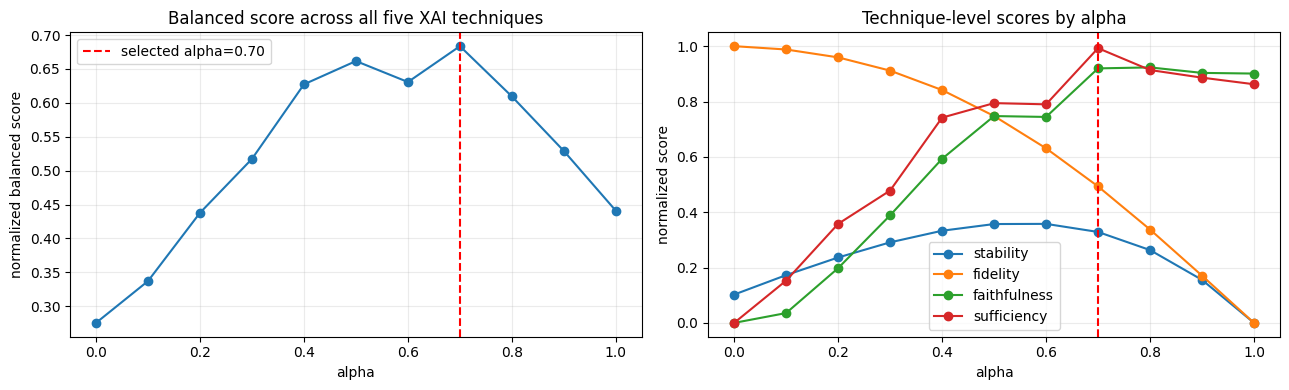

Saved alpha tuning table to xai_cacg_v3_alpha_tuning.xlsx


In [149]:
# CODEX-IMPROVE-0. Tune CACG V3 calibration alpha
# Alpha controls the blend: 0 = model/linear-surrogate strength, 1 = CACG V3 graph path strength.
# CODEX-ROLLBACK-TOP13: strict compact-stable tuner removed; using top-1 and top-3 only.
# This cell searches alpha values and selects the best balanced alpha using top-1 and top-3 perturbation metrics.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ALPHA_GRID = np.round(np.linspace(0.0, 1.0, 11), 2)
MIN_ALPHA_FOR_FINAL_SELECTION = 0.25  # keeps some CACG path-strength contribution in the final calibrated method
EVAL_K_VALUES = [1, 3]  # keep top-1 and top-3 only
def as_sample_index(df):
    df = df.copy()
    if "sample_id" in df.columns:
        return df.set_index("sample_id")
    return df
def load_or_use(var_name, file_name):
    if var_name in globals():
        return globals()[var_name].copy()
    path = Path(file_name)
    if not path.exists():
        raise FileNotFoundError(f"Missing {file_name}. Run the earlier XAI cells first.")
    return pd.read_excel(path)
required_helpers = [
   # "compactness_score",
    "explanation_stability_score",
    "explanation_fidelity_metrics",
    "faithfulness_score",
    "sufficiency_score"
]
missing_helpers = [name for name in required_helpers if name not in globals()]
if missing_helpers:
    raise NameError(
        "Missing helper(s): " + ", ".join(missing_helpers) +
        ". Run the XAI metric helper cells first."
    )
cacg_v3_weight_df = load_or_use("cacg_weight_df", "xai_cacg_concept_weights.xlsx")
linear_weight_df = load_or_use("linear_surrogate_weight_df", "xai_linear_concept_surrogate_weights.xlsx")
baseline_expl_for_alpha_df = as_sample_index(load_or_use("baseline_expl_df", "xai_baseline_sample_explanations.xlsx"))
if "concept_test_df" not in globals():
    concept_test_df = pd.read_excel("xai_concept_test_df.xlsx")
if "concept_names" not in globals():
    concept_names = [c for c in concept_test_df.columns if c not in ["sample_id", "Mortality_pred"]]

# Preserve the original test-set sample ids if concept_test_df was saved without them.
if "sample_id" not in concept_test_df.columns and Path("xai_cacg_sample_explanations.xlsx").exists():
    concept_test_df = concept_test_df.copy()
    concept_test_df["sample_id"] = pd.read_excel("xai_cacg_sample_explanations.xlsx")["sample_id"].values

if "concept_test_indexed_df" not in globals():
    concept_test_indexed_df = concept_test_df.copy()
    if "sample_id" in concept_test_indexed_df.columns:
        concept_test_indexed_df = concept_test_indexed_df.set_index("sample_id")
if "X_eval" not in globals():
    X_eval = X_test.sample(n=min(400, len(X_test)), random_state=42).copy()
if "train_feature_means" not in globals():
    train_feature_means = X_train.mean(numeric_only=True)
if "concept_feature_sets" not in globals():
    concept_feature_sets = {c: set(feats) for c, feats in concept_dict_X.items()}
path_strength = (
    cacg_v3_weight_df
    .set_index("concept")
    .loc[concept_names, "abs_total_influence"]
    .astype(float)
)
path_strength = path_strength / path_strength.max()
model_coef = (
    linear_weight_df
    .set_index("concept")
    .loc[concept_names, "coef"]
    .astype(float)
)
model_sign = np.sign(model_coef).replace(0, 1)
model_strength = model_coef.abs()
model_strength = model_strength / model_strength.max()
def build_calibrated_explainer(alpha):
    alpha = float(alpha)
    eps = 1e-12
    strength = (path_strength.clip(lower=eps) ** alpha) * (model_strength.clip(lower=eps) ** (1 - alpha))
    weight = model_sign * strength

    expl_df = concept_test_df[concept_names].copy()
    for concept in concept_names:
        expl_df[concept] = expl_df[concept] * float(weight.loc[concept])
    expl_df["sample_id"] = concept_test_df["sample_id"].values if "sample_id" in concept_test_df.columns else concept_test_df.index
    expl_df["Mortality_pred"] = concept_test_df["Mortality_pred"].values

    weight_df = pd.DataFrame({
        "concept": concept_names,
        "cacg_path_strength_norm": path_strength.loc[concept_names].values,
        "linear_surrogate_coef": model_coef.loc[concept_names].values,
        "linear_surrogate_strength_norm": model_strength.loc[concept_names].values,
        "calibration_alpha": alpha,
        "calibrated_weight": weight.loc[concept_names].values,
        "abs_calibrated_weight": weight.loc[concept_names].abs().values
    }).sort_values("abs_calibrated_weight", ascending=False).reset_index(drop=True)
    return weight_df, as_sample_index(expl_df)[concept_names].copy()
def evaluate_xai_row(method_name, expl_df, alpha=np.nan):
    # compact_mean, compact_std, _ = compactness_score(expl_df, concept_names, coverage_threshold=0.80)
    stab_mean, stab_std, _ = explanation_stability_score(expl_df, concept_test_indexed_df, concept_names, n_neighbors=5)
    fidelity_metrics = explanation_fidelity_metrics(expl_df, concept_test_indexed_df, concept_names)
    row = {
        "method": method_name,
        "alpha": alpha,
        # "compactness_80pct_lower_better": compact_mean,
        "stability_cosine_higher_better": stab_mean,
        "fidelity_pearson_higher_better": fidelity_metrics["pearson_fidelity"],
        "fidelity_r2_higher_better": fidelity_metrics["r2_fidelity"],
        "fidelity_mae_lower_better": fidelity_metrics["mae_fidelity"]
    }
    for k in EVAL_K_VALUES:
        faith_mean, faith_std, _ = faithfulness_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_dict_X,
            train_feature_means,
            k=k
        )
        suff_mean, suff_std, _ = sufficiency_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_feature_sets,
            train_feature_means,
            k=k
        )
        row[f"faithfulness_k{k}_higher_better"] = faith_mean
        row[f"sufficiency_k{k}_lower_better"] = suff_mean
    return row
baseline_alpha_row = evaluate_xai_row(
    "PC+IDA baseline",
    baseline_expl_for_alpha_df[concept_names],
    alpha=np.nan
)
alpha_metric_rows = []
for alpha in ALPHA_GRID:
    _, alpha_expl_df = build_calibrated_explainer(alpha)
    alpha_metric_rows.append(evaluate_xai_row(
        f"CACG V3 calibrated alpha={alpha:.2f}",
        alpha_expl_df,
        alpha=alpha
    ))
alpha_score_source_df = pd.DataFrame([baseline_alpha_row] + alpha_metric_rows)

metric_direction = {
    col: ("higher" if col.endswith("higher_better") else "lower")
    for col in alpha_score_source_df.columns
    if col not in ["method", "alpha"]
}
technique_groups = {
    "stability": ["stability_cosine_higher_better"],
    "fidelity": [
        "fidelity_pearson_higher_better",
        "fidelity_r2_higher_better",
        "fidelity_mae_lower_better"
    ],
    "faithfulness": [f"faithfulness_k{k}_higher_better" for k in EVAL_K_VALUES],
    "sufficiency": [f"sufficiency_k{k}_lower_better" for k in EVAL_K_VALUES]
}
for col, direction in metric_direction.items():
    values = alpha_score_source_df[col].astype(float)
    min_value = values.min()
    max_value = values.max()
    if np.isclose(max_value, min_value):
        alpha_score_source_df[f"score_{col}"] = 0.5
    elif direction == "higher":
        alpha_score_source_df[f"score_{col}"] = (values - min_value) / (max_value - min_value)
    else:
        alpha_score_source_df[f"score_{col}"] = (max_value - values) / (max_value - min_value)

for technique, cols in technique_groups.items():
    alpha_score_source_df[f"score_{technique}"] = alpha_score_source_df[[f"score_{col}" for col in cols]].mean(axis=1)

technique_score_cols = [f"score_{name}" for name in technique_groups]
alpha_score_source_df["balanced_all_five_xai_score"] = alpha_score_source_df[technique_score_cols].mean(axis=1)

baseline_values = alpha_score_source_df[alpha_score_source_df["method"] == "PC+IDA baseline"].iloc[0]

def count_wins_vs_baseline(row):
    wins = 0
    losses = 0
    ties = 0
    for col, direction in metric_direction.items():
        candidate_value = float(row[col])
        baseline_value = float(baseline_values[col])
        if np.isclose(candidate_value, baseline_value, rtol=1e-5, atol=1e-8):
            ties += 1
        elif direction == "higher" and candidate_value > baseline_value:
            wins += 1
        elif direction == "lower" and candidate_value < baseline_value:
            wins += 1
        else:
            losses += 1
    return pd.Series({"wins_vs_baseline": wins, "losses_vs_baseline": losses, "ties_vs_baseline": ties})

cacg_v3_alpha_search_df = alpha_score_source_df[alpha_score_source_df["method"] != "PC+IDA baseline"].copy()
cacg_v3_alpha_search_df = pd.concat(
    [cacg_v3_alpha_search_df, cacg_v3_alpha_search_df.apply(count_wins_vs_baseline, axis=1)],
    axis=1
)

selectable_alpha_df = cacg_v3_alpha_search_df[cacg_v3_alpha_search_df["alpha"] >= MIN_ALPHA_FOR_FINAL_SELECTION].copy()
best_alpha_row = selectable_alpha_df.sort_values(
    ["balanced_all_five_xai_score", "wins_vs_baseline", "alpha"],
    ascending=[False, False, True]
).iloc[0]

BEST_CALIBRATION_ALPHA = float(best_alpha_row["alpha"])
CALIBRATION_ALPHA = BEST_CALIBRATION_ALPHA

alpha_display_cols = [
    "alpha",
    "balanced_all_five_xai_score",
    "wins_vs_baseline",
    "losses_vs_baseline",
    "ties_vs_baseline",
    "score_stability",
    "score_fidelity",
    "score_faithfulness",
    "score_sufficiency"
]
print("Alpha meaning: 0 = model/linear-surrogate strength, 1 = CACG V3 graph path strength")
print(f"Selected BEST_CALIBRATION_ALPHA = {BEST_CALIBRATION_ALPHA:.2f}")
display(cacg_v3_alpha_search_df[alpha_display_cols].sort_values("balanced_all_five_xai_score", ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_df = cacg_v3_alpha_search_df.sort_values("alpha")
axes[0].plot(plot_df["alpha"], plot_df["balanced_all_five_xai_score"], marker="o")
axes[0].axvline(BEST_CALIBRATION_ALPHA, color="red", linestyle="--", label=f"selected alpha={BEST_CALIBRATION_ALPHA:.2f}")
axes[0].set_title("Balanced score across all five XAI techniques")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("normalized balanced score")
axes[0].legend()
axes[0].grid(alpha=0.25)
for col in technique_score_cols:
    axes[1].plot(plot_df["alpha"], plot_df[col], marker="o", label=col.replace("score_", ""))
axes[1].axvline(BEST_CALIBRATION_ALPHA, color="red", linestyle="--")
axes[1].set_title("Technique-level scores by alpha")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("normalized score")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()
cacg_v3_alpha_search_df.to_excel("xai_cacg_v3_alpha_tuning.xlsx", index=False)
print("Saved alpha tuning table to xai_cacg_v3_alpha_tuning.xlsx")

Using calibration alpha: 0.70
CACG V3 calibrated concept weights


,concept,cacg_path_strength_norm,linear_surrogate_coef,linear_surrogate_strength_norm,calibration_alpha,calibrated_weight,abs_calibrated_weight
0,Fitness,0.800000,-0.146886,0.699271,0.7,-0.768346,0.768346
1,Cardiometabolic,0.608739,0.210056,1.000000,0.7,0.706483,0.706483
2,Obesity/diabetes,1.000000,-0.064354,0.306368,0.7,-0.701250,0.701250
3,Dyslipidemia,0.608739,-0.127256,0.605817,0.7,-0.607861,0.607861
4,Hypertension,0.486991,0.113461,0.540146,0.7,0.502363,0.502363


All five XAI techniques: calibrated CACG V3 vs PC+IDA baseline


,method,stability_cosine_higher_better,fidelity_pearson_higher_better,fidelity_r2_higher_better,fidelity_mae_lower_better,faithfulness_k1_higher_better,sufficiency_k1_lower_better,faithfulness_k3_higher_better,sufficiency_k3_lower_better
0,PC+IDA baseline,0.989138,0.428889,0.183945,0.195349,0.039242,0.031532,0.054369,0.014889
1,CACG V3 calibrated,0.987880,0.447293,0.200071,0.195830,0.043011,0.030797,0.054962,0.014296


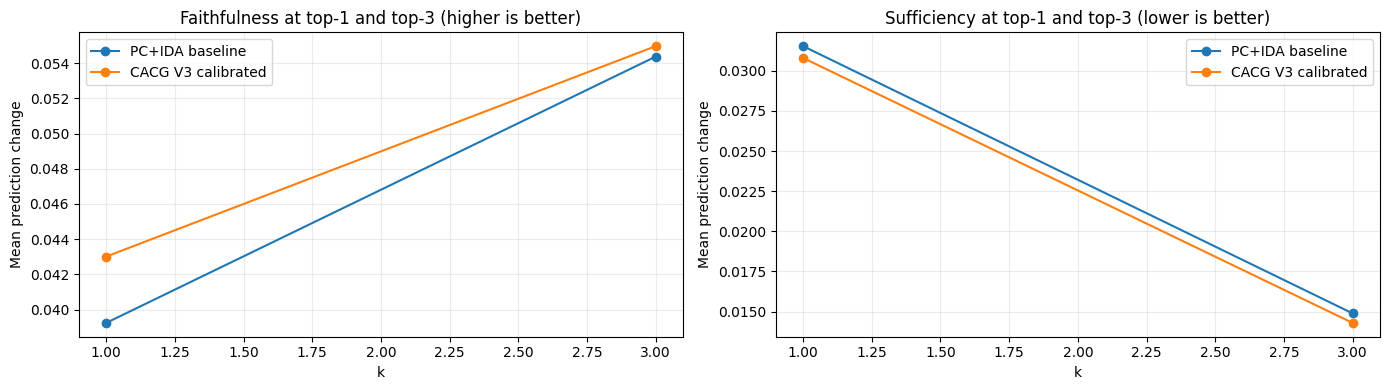

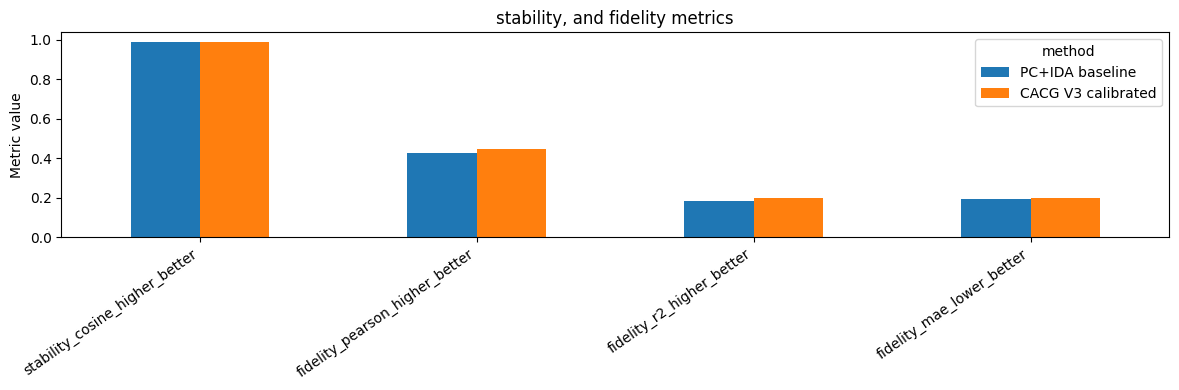

Saved calibrated CACG V3 weights, explanations, and all-five-XAI metric tables.


In [150]:
# CODEX-IMPROVE-1. Calibrated CACG V3 explanation weights
# CODEX-ROLLBACK-TOP13: alpha-only calibration; faithfulness/sufficiency use top-1 and top-3 only.
# Goal: keep CACG V3 as the final causal graph, but improve its XAI behavior by calibrating concept weights.
# Rationale: CACG V3 path weights are structural and all-positive; the model's concept effects are signed.
# This cell blends CACG V3 path strength with linear-surrogate concept strength.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
CALIBRATION_ALPHA = float(globals().get("BEST_CALIBRATION_ALPHA", 0.50))
EVAL_K_VALUES = [1, 3]  # keep top-1 and top-3 only
print(f"Using calibration alpha: {CALIBRATION_ALPHA:.2f}")
def as_sample_index(df):
    df = df.copy()
    if "sample_id" in df.columns:
        return df.set_index("sample_id")
    return df
def load_or_use(var_name, file_name):
    if var_name in globals():
        return globals()[var_name].copy()
    path = Path(file_name)
    if not path.exists():
        raise FileNotFoundError(f"Missing {file_name}. Run the earlier XAI cells first.")
    return pd.read_excel(path)
cacg_v3_weight_df = load_or_use("cacg_weight_df", "xai_cacg_concept_weights.xlsx")
linear_weight_df = load_or_use("linear_surrogate_weight_df", "xai_linear_concept_surrogate_weights.xlsx")

if "concept_test_df" not in globals():
    concept_test_df = pd.read_excel("xai_concept_test_df.xlsx")
if "concept_names" not in globals():
    concept_names = [c for c in concept_test_df.columns if c not in ["sample_id", "Mortality_pred"]]

# Preserve the original test-set sample ids if concept_test_df was saved without them.
if "sample_id" not in concept_test_df.columns and Path("xai_cacg_sample_explanations.xlsx").exists():
    concept_test_df = concept_test_df.copy()
    concept_test_df["sample_id"] = pd.read_excel("xai_cacg_sample_explanations.xlsx")["sample_id"].values
path_strength = (
    cacg_v3_weight_df
    .set_index("concept")
    .loc[concept_names, "abs_total_influence"]
    .astype(float)
)
path_strength = path_strength / path_strength.max()

model_coef = (
    linear_weight_df
    .set_index("concept")
    .loc[concept_names, "coef"]
    .astype(float)
)
model_sign = np.sign(model_coef).replace(0, 1)
model_strength = model_coef.abs()
model_strength = model_strength / model_strength.max()

calibrated_strength = (path_strength ** CALIBRATION_ALPHA) * (model_strength ** (1 - CALIBRATION_ALPHA))
calibrated_weight = model_sign * calibrated_strength

cacg_v3_calibrated_weight_df = pd.DataFrame({
    "concept": concept_names,
    "cacg_path_strength_norm": path_strength.loc[concept_names].values,
    "linear_surrogate_coef": model_coef.loc[concept_names].values,
    "linear_surrogate_strength_norm": model_strength.loc[concept_names].values,
    "calibration_alpha": CALIBRATION_ALPHA,
    "calibrated_weight": calibrated_weight.loc[concept_names].values,
    "abs_calibrated_weight": calibrated_weight.loc[concept_names].abs().values
}).sort_values("abs_calibrated_weight", ascending=False).reset_index(drop=True)
print("CACG V3 calibrated concept weights")
display(cacg_v3_calibrated_weight_df)
cacg_v3_calibrated_expl_df = concept_test_df[concept_names].copy()
for concept in concept_names:
    cacg_v3_calibrated_expl_df[concept] = (
        cacg_v3_calibrated_expl_df[concept] * float(calibrated_weight.loc[concept])
    )
cacg_v3_calibrated_expl_df["sample_id"] = concept_test_df["sample_id"].values if "sample_id" in concept_test_df.columns else concept_test_df.index
cacg_v3_calibrated_expl_df["Mortality_pred"] = concept_test_df["Mortality_pred"].values
cacg_v3_calibrated_expl_indexed_df = as_sample_index(cacg_v3_calibrated_expl_df)[concept_names].copy()
# Compare calibrated CACG V3 directly against the PC+IDA baseline.
baseline_expl_for_calib_df = as_sample_index(load_or_use("baseline_expl_df", "xai_baseline_sample_explanations.xlsx"))[concept_names]
if "concept_test_indexed_df" not in globals():
    concept_test_indexed_df = concept_test_df.copy()
    if "sample_id" in concept_test_indexed_df.columns:
        concept_test_indexed_df = concept_test_indexed_df.set_index("sample_id")
required_helpers = [
  #  "compactness_score",
    "explanation_stability_score",
    "explanation_fidelity_metrics",
    "faithfulness_score",
    "sufficiency_score"
]
missing_helpers = [name for name in required_helpers if name not in globals()]
if missing_helpers:
    raise NameError(
        "Missing helper(s): " + ", ".join(missing_helpers) +
        ". Run the XAI metric helper cells first."
    )
if "X_eval" not in globals():
    X_eval = X_test.sample(n=min(400, len(X_test)), random_state=42).copy()
if "train_feature_means" not in globals():
    train_feature_means = X_train.mean(numeric_only=True)
if "concept_feature_sets" not in globals():
    concept_feature_sets = {c: set(feats) for c, feats in concept_dict_X.items()}
calibration_metric_rows = []
comparison_explainers = {
    "PC+IDA baseline": baseline_expl_for_calib_df,
    "CACG V3 calibrated": cacg_v3_calibrated_expl_indexed_df,
}
for method_name, expl_df in comparison_explainers.items():
    stab_mean, stab_std, _ = explanation_stability_score(expl_df, concept_test_indexed_df, concept_names, n_neighbors=5)
    fidelity_metrics = explanation_fidelity_metrics(expl_df, concept_test_indexed_df, concept_names)
    metric_row = {
        "method": method_name,
        "stability_cosine_higher_better": stab_mean,
        "fidelity_pearson_higher_better": fidelity_metrics["pearson_fidelity"],
        "fidelity_r2_higher_better": fidelity_metrics["r2_fidelity"],
        "fidelity_mae_lower_better": fidelity_metrics["mae_fidelity"]
    }
    for k in EVAL_K_VALUES:
        faith_mean, faith_std, _ = faithfulness_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_dict_X,
            train_feature_means,
            k=k
        )
        suff_mean, suff_std, _ = sufficiency_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_feature_sets,
            train_feature_means,
            k=k
        )
        metric_row[f"faithfulness_k{k}_higher_better"] = faith_mean
        metric_row[f"sufficiency_k{k}_lower_better"] = suff_mean
    calibration_metric_rows.append(metric_row)
cacg_v3_calibrated_all_xai_metric_df = pd.DataFrame(calibration_metric_rows)
print("All five XAI techniques: calibrated CACG V3 vs PC+IDA baseline")
display(cacg_v3_calibrated_all_xai_metric_df)
# Long-form table for plotting and easy paper-ready reporting.
all_xai_long_rows = []
for _, row in cacg_v3_calibrated_all_xai_metric_df.iterrows():
    for col in cacg_v3_calibrated_all_xai_metric_df.columns:
        if col == "method":
            continue
        direction = "higher_better" if col.endswith("higher_better") else "lower_better"
        technique = col.split("_")[0]
        all_xai_long_rows.append({
            "method": row["method"],
            "xai_technique": technique,
            "metric": col,
            "direction": direction,
            "value": row[col]
        })
cacg_v3_calibrated_all_xai_long_df = pd.DataFrame(all_xai_long_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
faith_cols = [f"faithfulness_k{k}_higher_better" for k in EVAL_K_VALUES]
suff_cols = [f"sufficiency_k{k}_lower_better" for k in EVAL_K_VALUES]
for _, row in cacg_v3_calibrated_all_xai_metric_df.iterrows():
    axes[0].plot(EVAL_K_VALUES, [row[c] for c in faith_cols], marker="o", label=row["method"])
    axes[1].plot(EVAL_K_VALUES, [row[c] for c in suff_cols], marker="o", label=row["method"])
axes[0].set_title("Faithfulness at top-1 and top-3 (higher is better)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Mean prediction change")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].set_title("Sufficiency at top-1 and top-3 (lower is better)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Mean prediction change")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

static_cols = [
    "stability_cosine_higher_better",
    "fidelity_pearson_higher_better",
    "fidelity_r2_higher_better",
    "fidelity_mae_lower_better"
]
static_plot_df = cacg_v3_calibrated_all_xai_metric_df.set_index("method")[static_cols].T
static_plot_df.plot(kind="bar", figsize=(12, 4))
plt.title("stability, and fidelity metrics")
plt.ylabel("Metric value")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()
cacg_v3_calibrated_weight_df.to_excel("xai_cacg_v3_calibrated_weights.xlsx", index=False)
cacg_v3_calibrated_expl_df.to_excel("xai_cacg_v3_calibrated_sample_explanations.xlsx", index=False)
cacg_v3_calibrated_all_xai_metric_df.to_excel("xai_cacg_v3_calibrated_all_xai_metrics.xlsx", index=False)
cacg_v3_calibrated_all_xai_long_df.to_excel("xai_cacg_v3_calibrated_all_xai_metrics_long.xlsx", index=False)
print("Saved calibrated CACG V3 weights, explanations, and all-five-XAI metric tables.")



In [151]:
# ============================================================
# FINAL XAI METRICS BLOCK
# PC+IDA baseline vs calibrated CACG-V3
# Produces one clean table with all explanation-level metrics.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr


# ------------------------------------------------------------
# 1. Utility functions
# ------------------------------------------------------------

def as_sample_index(df):
    df = df.copy()
    if "sample_id" in df.columns:
        return df.set_index("sample_id")
    return df


def align_explainer_to_X(expl_df, X_input, concept_names):
    expl_use = as_sample_index(expl_df)[concept_names].copy()
    X_use = X_input.copy()

    common_idx = expl_use.index.intersection(X_use.index)

    if len(common_idx) > 0:
        return expl_use.loc[common_idx].copy(), X_use.loc[common_idx].copy()

    if len(expl_use) == len(X_use):
        expl_use = expl_use.copy()
        expl_use.index = X_use.index
        return expl_use, X_use

    raise ValueError("Could not align explanation rows with X rows. Check sample_id or index values.")


def compactness_score(expl_df, concept_names, coverage_threshold=0.80):
    n_concepts_needed = []

    expl_use = expl_df[concept_names].copy()

    for idx in expl_use.index:
        vals = expl_use.loc[idx, concept_names].abs()
        vals = vals.replace([np.inf, -np.inf], np.nan).dropna()

        total = float(vals.sum())

        if total <= 0:
            n_concepts_needed.append(0)
            continue

        vals_sorted = vals.sort_values(ascending=False)
        cumulative_share = vals_sorted.cumsum() / total
        needed = int((cumulative_share < coverage_threshold).sum() + 1)
        n_concepts_needed.append(needed)

    return {
        "compactness_80pct_lower_better": float(np.mean(n_concepts_needed)),
        "compactness_std": float(np.std(n_concepts_needed))
    }


def explanation_stability_score(expl_df, concept_df, concept_names, n_neighbors=5):
    expl_use = expl_df[concept_names].copy()
    concept_use = concept_df[concept_names].copy()

    common_idx = expl_use.index.intersection(concept_use.index)
    expl_use = expl_use.loc[common_idx].copy()
    concept_use = concept_use.loc[common_idx].copy()

    valid_mask = (~expl_use.isna().any(axis=1)) & (~concept_use.isna().any(axis=1))
    expl_use = expl_use.loc[valid_mask].copy()
    concept_use = concept_use.loc[valid_mask].copy()

    if len(expl_use) <= n_neighbors:
        raise ValueError(f"Not enough valid rows. Need more than {n_neighbors}, got {len(expl_use)}.")

    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, metric="euclidean")
    nbrs.fit(concept_use.values)

    _, indices = nbrs.kneighbors(concept_use.values)

    similarities = []

    for i in range(len(concept_use)):
        neigh_ids = indices[i][1:]
        x = expl_use.iloc[i].values.reshape(1, -1)
        neigh = expl_use.iloc[neigh_ids].values
        sims = cosine_similarity(x, neigh)[0]
        similarities.extend(sims.tolist())

    return {
        "stability_cosine_higher_better": float(np.mean(similarities)),
        "stability_std": float(np.std(similarities))
    }


def explanation_fidelity_metrics(expl_df, concept_df, concept_names):
    expl_use = expl_df[concept_names].copy()
    concept_use = concept_df[["Mortality_pred"]].copy()

    common_idx = expl_use.index.intersection(concept_use.index)
    expl_use = expl_use.loc[common_idx].copy()
    concept_use = concept_use.loc[common_idx].copy()

    valid_mask = (~expl_use.isna().any(axis=1)) & (~concept_use.isna().any(axis=1))
    expl_use = expl_use.loc[valid_mask].copy()
    concept_use = concept_use.loc[valid_mask].copy()

    expl_total = expl_use.sum(axis=1).values
    y_true = concept_use["Mortality_pred"].values

    if len(expl_total) < 2:
        return {
            "fidelity_pearson_higher_better": np.nan,
            "fidelity_r2_higher_better": np.nan,
            "fidelity_mae_lower_better": np.nan
        }

    b, a = np.polyfit(expl_total, y_true, deg=1)
    y_hat = a + b * expl_total

    return {
        "fidelity_pearson_higher_better": float(pearsonr(expl_total, y_true)[0]),
        "fidelity_r2_higher_better": float(r2_score(y_true, y_hat)),
        "fidelity_mae_lower_better": float(mean_absolute_error(y_true, y_hat))
    }


def perturb_concept_in_X(X_input, concept_name, concept_dict_X, reference_means):
    X_new = X_input.copy()

    for feat in concept_dict_X.get(concept_name, []):
        if feat in X_new.columns and feat in reference_means.index:
            if pd.api.types.is_numeric_dtype(X_new[feat]):
                X_new[feat] = X_new[feat].astype(float)
                X_new.loc[:, feat] = float(reference_means[feat])

    return X_new


def keep_only_top_concepts_in_X(X_input, top_concepts, concept_feature_sets, reference_means):
    X_new = X_input.copy()

    kept_features = set()

    for concept in top_concepts:
        kept_features = kept_features.union(concept_feature_sets.get(concept, set()))

    all_concept_features = sorted(set().union(*concept_feature_sets.values()))

    features_to_perturb = [
        feat for feat in all_concept_features
        if feat not in kept_features
    ]

    for feat in features_to_perturb:
        if feat in X_new.columns and feat in reference_means.index:
            if pd.api.types.is_numeric_dtype(X_new[feat]):
                X_new[feat] = X_new[feat].astype(float)
                X_new.loc[:, feat] = float(reference_means[feat])

    return X_new


def faithfulness_score(expl_df, X_input, model, concept_names, concept_dict_X, reference_means, k=1):
    expl_use, X_use = align_explainer_to_X(expl_df, X_input, concept_names)

    base_pred = model.predict_proba(X_use)[:, 1]
    changes = []

    for row_pos, sample_id in enumerate(X_use.index):
        top_concepts = (
            expl_use.loc[sample_id, concept_names]
            .abs()
            .sort_values(ascending=False)
            .head(k)
            .index
            .tolist()
        )

        X_perturbed = X_use.loc[[sample_id]].copy()

        for concept in top_concepts:
            X_perturbed = perturb_concept_in_X(
                X_perturbed,
                concept,
                concept_dict_X,
                reference_means
            )

        perturbed_pred = model.predict_proba(X_perturbed)[:, 1][0]
        changes.append(abs(float(base_pred[row_pos] - perturbed_pred)))

    return {
        f"faithfulness_k{k}_higher_better": float(np.mean(changes)),
        f"faithfulness_k{k}_std": float(np.std(changes))
    }


def sufficiency_score(expl_df, X_input, model, concept_names, concept_feature_sets, reference_means, k=1):
    expl_use, X_use = align_explainer_to_X(expl_df, X_input, concept_names)

    base_pred = model.predict_proba(X_use)[:, 1]
    changes = []

    for row_pos, sample_id in enumerate(X_use.index):
        top_concepts = (
            expl_use.loc[sample_id, concept_names]
            .abs()
            .sort_values(ascending=False)
            .head(k)
            .index
            .tolist()
        )

        X_sufficient = keep_only_top_concepts_in_X(
            X_use.loc[[sample_id]].copy(),
            top_concepts,
            concept_feature_sets,
            reference_means
        )

        sufficient_pred = model.predict_proba(X_sufficient)[:, 1][0]
        changes.append(abs(float(base_pred[row_pos] - sufficient_pred)))

    return {
        f"sufficiency_k{k}_lower_better": float(np.mean(changes)),
        f"sufficiency_k{k}_std": float(np.std(changes))
    }


def aopc_score(expl_df, X_input, model, concept_names, concept_dict_X, reference_means, k_values=(1, 3)):
    expl_use, X_use = align_explainer_to_X(expl_df, X_input, concept_names)

    base_pred = model.predict_proba(X_use)[:, 1]
    max_k = min(max(k_values), len(concept_names))

    deletion_by_k = {k: [] for k in k_values}
    aopc_by_k = {k: [] for k in k_values}

    for row_pos, sample_id in enumerate(X_use.index):
        ordered_concepts = (
            expl_use.loc[sample_id, concept_names]
            .abs()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

        cumulative_changes = []

        for step_k in range(1, max_k + 1):
            selected_concepts = ordered_concepts[:step_k]

            X_perturbed = X_use.loc[[sample_id]].copy()

            for concept in selected_concepts:
                X_perturbed = perturb_concept_in_X(
                    X_perturbed,
                    concept,
                    concept_dict_X,
                    reference_means
                )

            perturbed_pred = model.predict_proba(X_perturbed)[:, 1][0]
            cumulative_changes.append(abs(float(base_pred[row_pos] - perturbed_pred)))

        for k in k_values:
            k_use = min(k, max_k)
            deletion_by_k[k].append(cumulative_changes[k_use - 1])
            aopc_by_k[k].append(float(np.mean(cumulative_changes[:k_use])))

    summary = {}

    for k in k_values:
        summary[f"deletion_top{k}_higher_better"] = float(np.mean(deletion_by_k[k]))
        summary[f"aopc_top{k}_higher_better"] = float(np.mean(aopc_by_k[k]))
        summary[f"std_aopc_top{k}"] = float(np.std(aopc_by_k[k]))

    return summary


# ------------------------------------------------------------
# 2. Prepare final explainers
# ------------------------------------------------------------

K_VALUES = [1, 3]
N_EVAL = 400

if "concept_names" not in globals():
    concept_names = [
        c for c in concept_test_df.columns
        if c not in ["sample_id", "Mortality_pred"]
    ]

if "X_eval" not in globals():
    X_eval = X_test.sample(n=min(N_EVAL, len(X_test)), random_state=42).copy()

if "train_feature_means" not in globals():
    train_feature_means = X_train.mean(numeric_only=True)

concept_feature_sets = {
    c: set(feats)
    for c, feats in concept_dict_X.items()
}

concept_test_indexed_df = concept_test_df.copy()
if "sample_id" in concept_test_indexed_df.columns:
    concept_test_indexed_df = concept_test_indexed_df.set_index("sample_id")

explainers_final = {
    "PC+IDA baseline": as_sample_index(baseline_expl_df)[concept_names],
    "Calibrated CACG-V3": as_sample_index(cacg_v3_calibrated_expl_df)[concept_names]
}


# ------------------------------------------------------------
# 3. Compute all final XAI metrics in one place
# ------------------------------------------------------------

xai_final_rows = []

for method_name, expl_df in explainers_final.items():

    row = {
        "method": method_name
    }

    row.update(compactness_score(
        expl_df,
        concept_names,
        coverage_threshold=0.80
    ))

    row.update(explanation_stability_score(
        expl_df,
        concept_test_indexed_df,
        concept_names,
        n_neighbors=5
    ))

    row.update(explanation_fidelity_metrics(
        expl_df,
        concept_test_indexed_df,
        concept_names
    ))

    for k in K_VALUES:
        row.update(faithfulness_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_dict_X,
            train_feature_means,
            k=k
        ))

        row.update(sufficiency_score(
            expl_df,
            X_eval.copy(),
            clf,
            concept_names,
            concept_feature_sets,
            train_feature_means,
            k=k
        ))

    row.update(aopc_score(
        expl_df,
        X_eval.copy(),
        clf,
        concept_names,
        concept_dict_X,
        train_feature_means,
        k_values=K_VALUES
    ))

    xai_final_rows.append(row)


xai_final_summary_df = pd.DataFrame(xai_final_rows)


# ------------------------------------------------------------
# 4. Long-format version for paper plotting
# ------------------------------------------------------------

xai_final_long_rows = []

for _, row in xai_final_summary_df.iterrows():
    method = row["method"]

    for col in xai_final_summary_df.columns:
        if col == "method":
            continue

        if col.endswith("_higher_better"):
            direction = "higher_better"
            metric_name = col.replace("_higher_better", "")
        elif col.endswith("_lower_better"):
            direction = "lower_better"
            metric_name = col.replace("_lower_better", "")
        else:
            direction = "descriptive"
            metric_name = col

        xai_final_long_rows.append({
            "method": method,
            "metric": metric_name,
            "direction": direction,
            "value": row[col]
        })

xai_final_long_df = pd.DataFrame(xai_final_long_rows)


# ------------------------------------------------------------
# 5. Display and save
# ------------------------------------------------------------

print("Final XAI metric summary: PC+IDA baseline vs calibrated CACG-V3")
display(xai_final_summary_df)

print("Final XAI metric summary, long format")
display(xai_final_long_df)

xai_final_summary_df.to_excel(
    "final_xai_metrics_pc_ida_vs_calibrated_cacgv3.xlsx",
    index=False
)

xai_final_long_df.to_excel(
    "final_xai_metrics_pc_ida_vs_calibrated_cacgv3_long.xlsx",
    index=False
)

print("Saved final_xai_metrics_pc_ida_vs_calibrated_cacgv3.xlsx")
print("Saved final_xai_metrics_pc_ida_vs_calibrated_cacgv3_long.xlsx")

Final XAI metric summary: PC+IDA baseline vs calibrated CACG-V3


,method,compactness_80pct_lower_better,compactness_std,stability_cosine_higher_better,stability_std,fidelity_pearson_higher_better,fidelity_r2_higher_better,fidelity_mae_lower_better,faithfulness_k1_higher_better,faithfulness_k1_std,...,faithfulness_k3_higher_better,faithfulness_k3_std,sufficiency_k3_lower_better,sufficiency_k3_std,deletion_top1_higher_better,aopc_top1_higher_better,std_aopc_top1,deletion_top3_higher_better,aopc_top3_higher_better,std_aopc_top3
0,PC+IDA baseline,3.184807,0.657579,0.989138,0.020996,0.428889,0.183945,0.195349,0.039242,0.083424,...,0.054369,0.092541,0.014889,0.047734,0.039242,0.039242,0.083424,0.054369,0.048937,0.085469
1,Calibrated CACG-V3,3.429071,0.596464,0.987880,0.019251,0.447293,0.200071,0.195830,0.043011,0.088735,...,0.054962,0.092571,0.014296,0.047174,0.043011,0.043011,0.088735,0.054962,0.049024,0.086924


Final XAI metric summary, long format


,method,metric,direction,value
0,PC+IDA baseline,compactness_80pct,lower_better,3.184807
1,PC+IDA baseline,compactness_std,descriptive,0.657579
2,PC+IDA baseline,stability_cosine,higher_better,0.989138
3,PC+IDA baseline,stability_std,descriptive,0.020996
4,PC+IDA baseline,fidelity_pearson,higher_better,0.428889
5,PC+IDA baseline,fidelity_r2,higher_better,0.183945
6,PC+IDA baseline,fidelity_mae,lower_better,0.195349
7,PC+IDA baseline,faithfulness_k1,higher_better,0.039242
8,PC+IDA baseline,faithfulness_k1_std,descriptive,0.083424
9,PC+IDA baseline,sufficiency_k1,lower_better,0.031532


Saved final_xai_metrics_pc_ida_vs_calibrated_cacgv3.xlsx
Saved final_xai_metrics_pc_ida_vs_calibrated_cacgv3_long.xlsx


Extra XAI evaluation metrics: AOPC/deletion
AOPC/deletion: higher is better.


,method,deletion_top1_higher_better,aopc_top1_higher_better,std_aopc_top1,deletion_top3_higher_better,aopc_top3_higher_better,std_aopc_top3
0,PC+IDA baseline,0.039242,0.039242,0.083424,0.054369,0.048937,0.085469
1,CACG V3 calibrated,0.043011,0.043011,0.088735,0.054962,0.049024,0.086924


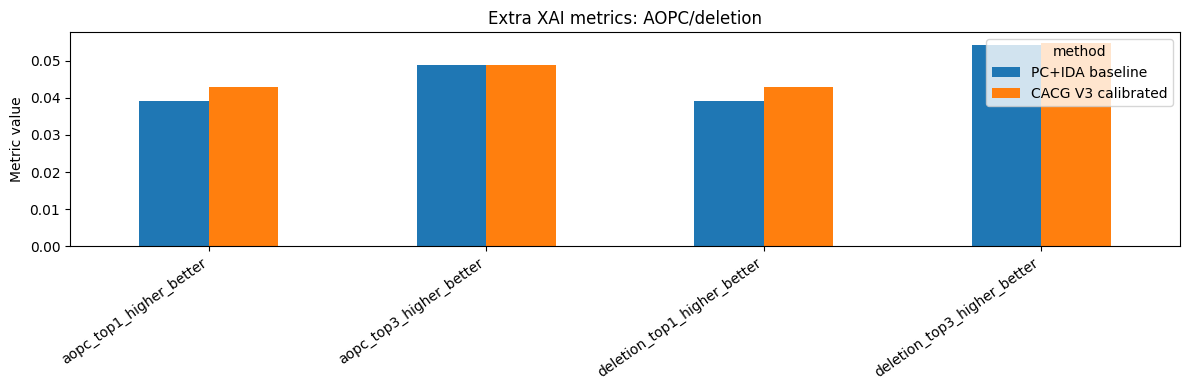

Saved extra XAI metrics to xai_extra_aopc_top1_top3.xlsx


In [152]:
# CODEX-EXTRA-XAI-1. AOPC for calibrated CACG V3 vs baseline
# Adds AOPC/deletion XAI evaluation metrics after the main five-metric comparison.
# AOPC/deletion: higher is better.
# Uses top-1 and top-3 only, matching the current final comparison setup.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXTRA_XAI_K_VALUES = [1, 3]


def as_sample_index(df):
    df = df.copy()
    if "sample_id" in df.columns:
        return df.set_index("sample_id")
    return df


def load_or_use(var_name, file_name):
    if var_name in globals():
        return globals()[var_name].copy()
    path = Path(file_name)
    if not path.exists():
        raise FileNotFoundError(f"Missing {file_name}. Run the earlier XAI cells first.")
    return pd.read_excel(path)
if "concept_test_df" not in globals():
    concept_test_df = pd.read_excel("xai_concept_test_df.xlsx")
if "concept_names" not in globals():
    concept_names = [c for c in concept_test_df.columns if c not in ["sample_id", "Mortality_pred"]]
if "X_eval" not in globals():
    X_eval = X_test.sample(n=min(400, len(X_test)), random_state=42).copy()
if "train_feature_means" not in globals():
    train_feature_means = X_train.mean(numeric_only=True)

required_objects = ["clf", "concept_dict_X", "concept_names", "X_eval", "train_feature_means"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError("Missing required object(s): " + ", ".join(missing_objects))
baseline_extra_expl_df = as_sample_index(
    load_or_use("baseline_expl_df", "xai_baseline_sample_explanations.xlsx")
)[concept_names]
calibrated_extra_expl_df = as_sample_index(
    load_or_use("cacg_v3_calibrated_expl_df", "xai_cacg_v3_calibrated_sample_explanations.xlsx")
)[concept_names]
def align_explainer_to_X(expl_df, X_input, concept_names):
    expl_use = expl_df[concept_names].copy()
    X_use = X_input.copy()

    common_idx = expl_use.index.intersection(X_use.index)
    if len(common_idx) > 0:
        return expl_use.loc[common_idx].copy(), X_use.loc[common_idx].copy()
    if len(expl_use) == len(X_use):
        expl_use = expl_use.copy()
        expl_use.index = X_use.index
        return expl_use, X_use
    raise ValueError("Could not align explanation rows with X_eval rows.")


def perturb_concepts_to_reference(X_row_df, concepts, concept_dict_X, reference_means):
    X_perturbed = X_row_df.copy()
    for concept in concepts:
        for feature in concept_dict_X.get(concept, []):
            if feature in X_perturbed.columns and feature in reference_means.index:
                X_perturbed[feature] = reference_means[feature]
    return X_perturbed
def aopc_score(
    expl_df,
    X_input,
    model,
    concept_names,
    concept_dict_X,
    reference_means,
    k_values=(1, 3)
):
    expl_use, X_use = align_explainer_to_X(expl_df, X_input, concept_names)
    base_pred = model.predict_proba(X_use)[:, 1]
    max_k = min(max(k_values), len(concept_names))

    deletion_by_k = {k: [] for k in k_values}
    aopc_by_k = {k: [] for k in k_values}

    for row_pos, sample_id in enumerate(X_use.index):
        ordered_concepts = (
            expl_use.loc[sample_id, concept_names]
            .abs()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

        cumulative_changes = []
        for step_k in range(1, max_k + 1):
            selected_concepts = ordered_concepts[:step_k]
            X_perturbed = perturb_concepts_to_reference(
                X_use.loc[[sample_id]],
                selected_concepts,
                concept_dict_X,
                reference_means
            )
            perturbed_pred = model.predict_proba(X_perturbed)[:, 1][0]
            cumulative_changes.append(abs(float(base_pred[row_pos] - perturbed_pred)))

        for k in k_values:
            k_use = min(k, max_k)
            deletion_by_k[k].append(cumulative_changes[k_use - 1])
            aopc_by_k[k].append(float(np.mean(cumulative_changes[:k_use])))
    summary = {}
    details = {}
    for k in k_values:
        summary[f"deletion_top{k}_higher_better"] = float(np.mean(deletion_by_k[k]))
        summary[f"aopc_top{k}_higher_better"] = float(np.mean(aopc_by_k[k]))
        summary[f"std_aopc_top{k}"] = float(np.std(aopc_by_k[k]))
        details[f"deletion_top{k}"] = deletion_by_k[k]
        details[f"aopc_top{k}"] = aopc_by_k[k]

    return summary, details


extra_metric_rows = []
extra_explainers = {
    "PC+IDA baseline": baseline_extra_expl_df,
    "CACG V3 calibrated": calibrated_extra_expl_df,
}
for method_name, expl_df in extra_explainers.items():
    aopc_summary, _ = aopc_score(
        expl_df,
        X_eval.copy(),
        clf,
        concept_names,
        concept_dict_X,
        train_feature_means,
        k_values=EXTRA_XAI_K_VALUES
    )

    row = {"method": method_name}
    row.update(aopc_summary)
    extra_metric_rows.append(row)

extra_xai_metric_df = pd.DataFrame(extra_metric_rows)
print("Extra XAI evaluation metrics: AOPC/deletion")
print("AOPC/deletion: higher is better.")
display(extra_xai_metric_df)
extra_plot_cols = [
    "aopc_top1_higher_better",
    "aopc_top3_higher_better",
    "deletion_top1_higher_better",
    "deletion_top3_higher_better"
]
plot_df = extra_xai_metric_df.set_index("method")[extra_plot_cols].T
plot_df.plot(kind="bar", figsize=(12, 4))
plt.title("Extra XAI metrics: AOPC/deletion")
plt.ylabel("Metric value")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()
extra_xai_metric_df.to_excel("xai_extra_aopc_top1_top3.xlsx", index=False)
print("Saved extra XAI metrics to xai_extra_aopc_top1_top3.xlsx")


# step 6: GENERATE FINAL EXPLANATIONS
The document says Stage 6 should use the CACG to produce:

causal pathways
patient-specific explanation
causal counterfactuals
visual causal graph for clinicians

## integrative part end here

In [153]:
# Step 6.1: identify causal pathways from final calibrated CACG-V3

# Use final calibrated CACG-V3 edge table
# This assumes cacg_v3_compare_df contains source, target, graph_weight
# and cacg_v3_calibrated_weight_df contains calibrated concept weights for XAI.
# For pathway extraction, we use graph edges from CACG-V3.

cacg_edges_df = cacg_v3_compare_df.copy()

# Standardize edge-weight column name for Step 6
if "cacg_weight" not in cacg_edges_df.columns:
    if "graph_weight" in cacg_edges_df.columns:
        cacg_edges_df = cacg_edges_df.rename(columns={"graph_weight": "cacg_weight"})
    else:
        raise ValueError("CACG-V3 edge table must contain either 'graph_weight' or 'cacg_weight'.")

# Build edge label if missing
if "edge" not in cacg_edges_df.columns:
    cacg_edges_df["edge"] = (
        cacg_edges_df["source"] + " -> " + cacg_edges_df["target"]
    )

# Direct causes of Mortality
direct_causes_df = cacg_edges_df[
    cacg_edges_df["target"] == "Mortality"
].copy()

# Mediated paths: source -> mediator -> Mortality
mediator_rows = []

for _, row1 in cacg_edges_df.iterrows():
    source = row1["source"]
    mediator = row1["target"]

    if mediator == "Mortality":
        continue

    # mediator -> Mortality must exist
    matches = cacg_edges_df[
        (cacg_edges_df["source"] == mediator) &
        (cacg_edges_df["target"] == "Mortality")
    ]

    for _, row2 in matches.iterrows():
        mediator_rows.append({
            "source": source,
            "mediator": mediator,
            "target": "Mortality",
            "path": f"{source} -> {mediator} -> Mortality",
            "edge1_weight": row1["cacg_weight"],
            "edge2_weight": row2["cacg_weight"],
            "path_weight": min(row1["cacg_weight"], row2["cacg_weight"])
        })

cacg_mediator_paths_df = pd.DataFrame(mediator_rows)

print("Final calibrated CACG-V3 edges:")
display(cacg_edges_df)

print("Direct causes:")
display(direct_causes_df)

print("Mediator paths:")
display(cacg_mediator_paths_df)

Final calibrated CACG-V3 edges:


,source,target,cacg_weight,edge,graph_name
0,Dyslipidemia,Cardiometabolic,1.000000,Dyslipidemia -> Cardiometabolic,CACG_v3
1,Obesity/diabetes,Cardiometabolic,0.668887,Obesity/diabetes -> Cardiometabolic,CACG_v3
2,Hypertension,Cardiometabolic,0.800000,Hypertension -> Cardiometabolic,CACG_v3
3,Obesity/diabetes,Dyslipidemia,0.333854,Obesity/diabetes -> Dyslipidemia,CACG_v3
4,Cardiometabolic,Dyslipidemia,0.962132,Cardiometabolic -> Dyslipidemia,CACG_v3
5,Obesity/diabetes,Hypertension,0.800000,Obesity/diabetes -> Hypertension,CACG_v3
6,Cardiometabolic,Mortality,1.000000,Cardiometabolic -> Mortality,CACG_v3
7,Cardiometabolic,Obesity/diabetes,0.446242,Cardiometabolic -> Obesity/diabetes,CACG_v3
8,Fitness,Obesity/diabetes,0.800000,Fitness -> Obesity/diabetes,CACG_v3


Direct causes:


,source,target,cacg_weight,edge,graph_name
6,Cardiometabolic,Mortality,1.0,Cardiometabolic -> Mortality,CACG_v3


Mediator paths:


,source,mediator,target,path,edge1_weight,edge2_weight,path_weight
0,Dyslipidemia,Cardiometabolic,Mortality,Dyslipidemia -> Cardiometabolic -> Mortality,1.000000,1.0,1.000000
1,Obesity/diabetes,Cardiometabolic,Mortality,Obesity/diabetes -> Cardiometabolic -> Mortality,0.668887,1.0,0.668887
2,Hypertension,Cardiometabolic,Mortality,Hypertension -> Cardiometabolic -> Mortality,0.800000,1.0,0.800000


In [154]:
# Step 6.2: choose a patient and inspect concept values
concept_score_cols = concept_names
patient_id = 0  # change this to any row index you want
# Use concept_test_df if available, because calibrated CACG was built on this test concept set
if "concept_test_df" in globals():
    patient_row = concept_test_df.iloc[patient_id]
else:
    patient_row = df.iloc[patient_id]
patient_concepts = patient_row[concept_score_cols].copy()
patient_concepts_df = pd.DataFrame({
    "concept": patient_concepts.index,
    "value": patient_concepts.values
}).sort_values("value", ascending=False)
patient_concepts_df

,concept,value
0,Fitness,1.046449
2,Obesity/diabetes,-0.301759
1,Hypertension,-0.553984
4,Cardiometabolic,-0.610869
3,Dyslipidemia,-0.765424


In [155]:
# Patient-specific direct drivers of Mortality using calibrated CACG-V3 weights

direct_driver_rows = []

# Build calibrated weight lookup
calibrated_weight_lookup = (
    cacg_v3_calibrated_weight_df
    .set_index("concept")["calibrated_weight"]
    .to_dict()
)

for _, row in direct_causes_df.iterrows():
    concept = row["source"]

    if concept in patient_concepts.index:
        calibrated_weight = calibrated_weight_lookup.get(concept, row["cacg_weight"])

        direct_driver_rows.append({
            "concept": concept,
            "patient_value": patient_concepts[concept],
            "pathway_weight": row["cacg_weight"],
            "calibrated_concept_weight": calibrated_weight,
            "driver_score": patient_concepts[concept] * calibrated_weight,
            "cacg_basis": f"{concept} -> Mortality"
        })

patient_direct_drivers_df = pd.DataFrame(direct_driver_rows)

if len(patient_direct_drivers_df) > 0:
    patient_direct_drivers_df = patient_direct_drivers_df.sort_values(
        "driver_score",
        ascending=False
    )

patient_direct_drivers_df

,concept,patient_value,pathway_weight,calibrated_concept_weight,driver_score,cacg_basis
0,Cardiometabolic,-0.610869,1.0,0.706483,-0.431569,Cardiometabolic -> Mortality


In [156]:
# Patient-specific mediated pathways using calibrated CACG-V3 weights

mediated_rows = []

calibrated_weight_lookup = (
    cacg_v3_calibrated_weight_df
    .set_index("concept")["calibrated_weight"]
    .to_dict()
)

for _, row in cacg_mediator_paths_df.iterrows():
    source = row["source"]
    mediator = row["mediator"]

    if source in patient_concepts.index and mediator in patient_concepts.index:
        source_calibrated_weight = calibrated_weight_lookup.get(source, 1.0)
        mediator_calibrated_weight = calibrated_weight_lookup.get(mediator, 1.0)

        source_score = patient_concepts[source] * source_calibrated_weight
        mediator_score = patient_concepts[mediator] * mediator_calibrated_weight

        # Create path label safely
        if "path" in cacg_mediator_paths_df.columns:
            path_label = row["path"]
        else:
            path_label = f"{source} -> {mediator} -> Mortality"

        mediated_rows.append({
            "source": source,
            "mediator": mediator,
            "target": "Mortality",
            "source_value": patient_concepts[source],
            "mediator_value": patient_concepts[mediator],
            "source_calibrated_weight": source_calibrated_weight,
            "mediator_calibrated_weight": mediator_calibrated_weight,
            "path_weight": row["path_weight"],
            "path_score": ((source_score + mediator_score) / 2.0) * row["path_weight"],
            "cacg_basis": path_label
        })

patient_mediated_paths_df = pd.DataFrame(mediated_rows)

if len(patient_mediated_paths_df) > 0:
    patient_mediated_paths_df = patient_mediated_paths_df.sort_values(
        "path_score",
        ascending=False
    )

patient_mediated_paths_df

,source,mediator,target,source_value,mediator_value,source_calibrated_weight,mediator_calibrated_weight,path_weight,path_score,cacg_basis
0,Dyslipidemia,Cardiometabolic,Mortality,-0.765424,-0.610869,-0.607861,0.706483,1.000000,0.016851,Dyslipidemia -> Cardiometabolic -> Mortality
1,Obesity/diabetes,Cardiometabolic,Mortality,-0.301759,-0.610869,-0.701250,0.706483,0.668887,-0.073564,Obesity/diabetes -> Cardiometabolic -> Mortality
2,Hypertension,Cardiometabolic,Mortality,-0.553984,-0.610869,0.502363,0.706483,0.800000,-0.283948,Hypertension -> Cardiometabolic -> Mortality


In [157]:
# Step 6.3: calibrated CACG-V3 causal counterfactual suggestions

counterfactual_rows = []

ace_lookup = concept_effects_df.set_index("concept")["ACE_high_minus_low"].to_dict()

# Direct suggestions
for _, row in patient_direct_drivers_df.head(3).iterrows():
    concept = row["concept"]
    ace_val = ace_lookup.get(concept, None)

    if ace_val is None:
        continue

    if ace_val < 0:
        suggested_change = f"Improve {concept} by +2 SD"
        expected_effect = "Directly decrease mortality risk"
    else:
        suggested_change = f"Reduce {concept} by -2 SD"
        expected_effect = "Directly decrease mortality risk"

    # Safe CACG basis
    if "cacg_basis" in patient_direct_drivers_df.columns:
        cacg_basis = row["cacg_basis"]
    else:
        cacg_basis = f"{concept} -> Mortality"

    # Safe calibrated weight
    if "calibrated_concept_weight" in patient_direct_drivers_df.columns:
        calibrated_weight = row["calibrated_concept_weight"]
    elif "cacg_weight" in patient_direct_drivers_df.columns:
        calibrated_weight = row["cacg_weight"]
    else:
        calibrated_weight = None

    # Safe driver score
    driver_score = row["driver_score"] if "driver_score" in patient_direct_drivers_df.columns else None

    counterfactual_rows.append({
        "type": "direct",
        "concept": concept,
        "suggested_change": suggested_change,
        "expected_effect": expected_effect,
        "cacg_basis": cacg_basis,
        "evidence": f"ACE_high_minus_low = {ace_val:.6f}",
        "calibrated_weight": calibrated_weight,
        "driver_score": driver_score
    })


# Mediated suggestions
for _, row in patient_mediated_paths_df.head(3).iterrows():
    source = row["source"]
    mediator = row["mediator"]

    # Safe CACG basis
    if "cacg_basis" in patient_mediated_paths_df.columns:
        cacg_basis = row["cacg_basis"]
    else:
        cacg_basis = f"{source} -> {mediator} -> Mortality"

    # Safe calibrated weight
    if "source_calibrated_weight" in patient_mediated_paths_df.columns:
        calibrated_weight = row["source_calibrated_weight"]
    else:
        calibrated_weight = None

    # Safe path score
    path_score = row["path_score"] if "path_score" in patient_mediated_paths_df.columns else None

    counterfactual_rows.append({
        "type": "mediated",
        "concept": source,
        "suggested_change": f"Improve {source} by +2 SD",
        "expected_effect": f"May reduce mortality risk indirectly through {mediator}",
        "cacg_basis": cacg_basis,
        "evidence": f"path_weight = {row['path_weight']:.3f}",
        "calibrated_weight": calibrated_weight,
        "path_score": path_score
    })


counterfactual_df = pd.DataFrame(counterfactual_rows)
counterfactual_df

,type,concept,suggested_change,expected_effect,cacg_basis,evidence,calibrated_weight,driver_score,path_score
0,direct,Cardiometabolic,Improve Cardiometabolic by +2 SD,Directly decrease mortality risk,Cardiometabolic -> Mortality,ACE_high_minus_low = -0.003599,0.706483,-0.431569,NaN
1,mediated,Dyslipidemia,Improve Dyslipidemia by +2 SD,May reduce mortality risk indirectly through C...,Dyslipidemia -> Cardiometabolic -> Mortality,path_weight = 1.000,-0.607861,NaN,0.016851
2,mediated,Obesity/diabetes,Improve Obesity/diabetes by +2 SD,May reduce mortality risk indirectly through C...,Obesity/diabetes -> Cardiometabolic -> Mortality,path_weight = 0.669,-0.701250,NaN,-0.073564
3,mediated,Hypertension,Improve Hypertension by +2 SD,May reduce mortality risk indirectly through C...,Hypertension -> Cardiometabolic -> Mortality,path_weight = 0.800,0.502363,NaN,-0.283948


In [158]:
# Generate patient-specific narrative from calibrated CACG-V3

narrative_parts = []

top_direct = (
    patient_direct_drivers_df.head(3)["concept"].tolist()
    if len(patient_direct_drivers_df) > 0 else []
)

top_paths = patient_mediated_paths_df.head(3)

if top_direct:
    narrative_parts.append(
        "Mortality risk is driven most directly by "
        + ", ".join(top_direct)
        + "."
    )

if len(top_paths) > 0:
    mediated_text = []
    for _, row in top_paths.iterrows():
        mediated_text.append(
            f"{row['source']} acting through {row['mediator']}"
        )

    narrative_parts.append(
        "Important mediated pathways include "
        + ", ".join(mediated_text)
        + "."
    )

counterfactual_targets = (
    counterfactual_df["concept"].dropna().unique().tolist()
    if len(counterfactual_df) > 0 else []
)

if counterfactual_targets:
    if len(counterfactual_targets) > 1:
        narrative_parts.append(
            "This suggests that improving "
            + ", ".join(counterfactual_targets[:-1])
            + ", or "
            + counterfactual_targets[-1]
            + " may help reduce mortality risk."
        )
    else:
        narrative_parts.append(
            f"This suggests that improving {counterfactual_targets[0]} may help reduce mortality risk."
        )

narrative_parts.append(
    "These conclusions are based on the patient's concept values combined with the final calibrated CACG-V3."
)

patient_narrative = " ".join(narrative_parts)
print(patient_narrative)

Mortality risk is driven most directly by Cardiometabolic. Important mediated pathways include Dyslipidemia acting through Cardiometabolic, Obesity/diabetes acting through Cardiometabolic, Hypertension acting through Cardiometabolic. This suggests that improving Cardiometabolic, Dyslipidemia, Obesity/diabetes, or Hypertension may help reduce mortality risk. These conclusions are based on the patient's concept values combined with the final calibrated CACG-V3.


In [159]:
# Step 6 combined explanation package from calibrated CACG-V3

print("PATIENT-SPECIFIC CONCEPT VALUES")
display(patient_concepts_df)

print("\nDIRECT DRIVERS OF MORTALITY")
display(patient_direct_drivers_df)

print("\nMEDIATED PATHWAYS")
display(patient_mediated_paths_df)

print("\nCOUNTERFACTUAL SUGGESTIONS")
display(counterfactual_df)

print("\nNARRATIVE")
print(patient_narrative)

PATIENT-SPECIFIC CONCEPT VALUES


,concept,value
0,Fitness,1.046449
2,Obesity/diabetes,-0.301759
1,Hypertension,-0.553984
4,Cardiometabolic,-0.610869
3,Dyslipidemia,-0.765424



DIRECT DRIVERS OF MORTALITY


,concept,patient_value,pathway_weight,calibrated_concept_weight,driver_score,cacg_basis
0,Cardiometabolic,-0.610869,1.0,0.706483,-0.431569,Cardiometabolic -> Mortality



MEDIATED PATHWAYS


,source,mediator,target,source_value,mediator_value,source_calibrated_weight,mediator_calibrated_weight,path_weight,path_score,cacg_basis
0,Dyslipidemia,Cardiometabolic,Mortality,-0.765424,-0.610869,-0.607861,0.706483,1.000000,0.016851,Dyslipidemia -> Cardiometabolic -> Mortality
1,Obesity/diabetes,Cardiometabolic,Mortality,-0.301759,-0.610869,-0.701250,0.706483,0.668887,-0.073564,Obesity/diabetes -> Cardiometabolic -> Mortality
2,Hypertension,Cardiometabolic,Mortality,-0.553984,-0.610869,0.502363,0.706483,0.800000,-0.283948,Hypertension -> Cardiometabolic -> Mortality



COUNTERFACTUAL SUGGESTIONS


,type,concept,suggested_change,expected_effect,cacg_basis,evidence,calibrated_weight,driver_score,path_score
0,direct,Cardiometabolic,Improve Cardiometabolic by +2 SD,Directly decrease mortality risk,Cardiometabolic -> Mortality,ACE_high_minus_low = -0.003599,0.706483,-0.431569,NaN
1,mediated,Dyslipidemia,Improve Dyslipidemia by +2 SD,May reduce mortality risk indirectly through C...,Dyslipidemia -> Cardiometabolic -> Mortality,path_weight = 1.000,-0.607861,NaN,0.016851
2,mediated,Obesity/diabetes,Improve Obesity/diabetes by +2 SD,May reduce mortality risk indirectly through C...,Obesity/diabetes -> Cardiometabolic -> Mortality,path_weight = 0.669,-0.701250,NaN,-0.073564
3,mediated,Hypertension,Improve Hypertension by +2 SD,May reduce mortality risk indirectly through C...,Hypertension -> Cardiometabolic -> Mortality,path_weight = 0.800,0.502363,NaN,-0.283948



NARRATIVE
Mortality risk is driven most directly by Cardiometabolic. Important mediated pathways include Dyslipidemia acting through Cardiometabolic, Obesity/diabetes acting through Cardiometabolic, Hypertension acting through Cardiometabolic. This suggests that improving Cardiometabolic, Dyslipidemia, Obesity/diabetes, or Hypertension may help reduce mortality risk. These conclusions are based on the patient's concept values combined with the final calibrated CACG-V3.


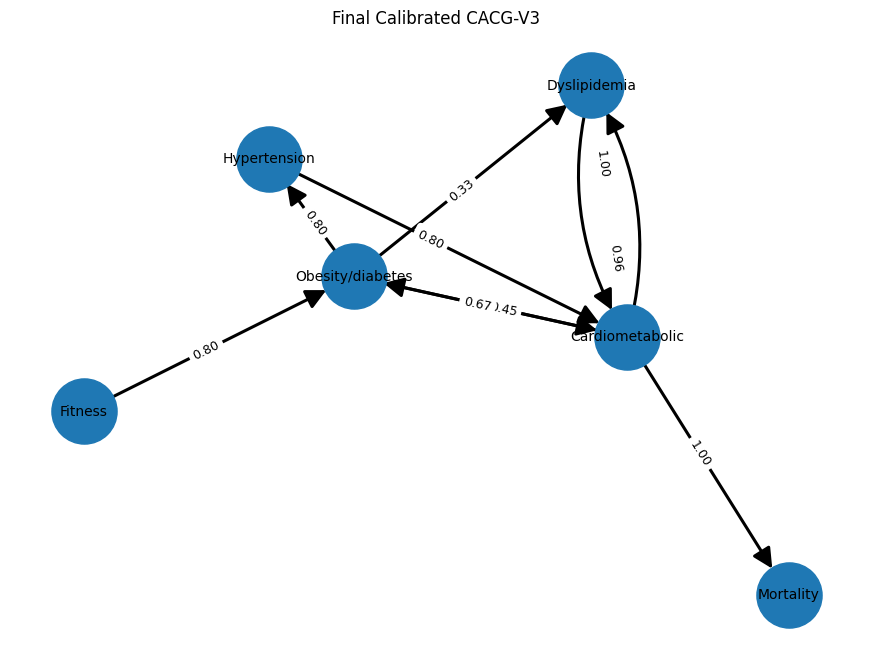

In [160]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in cacg_edges_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["cacg_weight"]
    )

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2200)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10)

# Split curved and straight edges for clarity
curved_edges = [
    ("Cardiometabolic", "Dyslipidemia"),
    ("Dyslipidemia", "Cardiometabolic")
]

straight_edges = [e for e in G.edges() if e not in curved_edges]

# Draw straight edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=straight_edges,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=2.2,
    min_source_margin=15,
    min_target_margin=22
)

# Draw curved edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=curved_edges,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=2.2,
    min_source_margin=15,
    min_target_margin=22,
    connectionstyle="arc3,rad=0.22"
)

# Edge labels
edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
}

straight_edge_labels = {
    e: edge_labels[e]
    for e in straight_edges
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=straight_edge_labels,
    font_size=9,
    label_pos=0.45
)

curved_edge_labels = {
    e: edge_labels[e]
    for e in curved_edges
    if e in edge_labels
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=curved_edge_labels,
    font_size=9,
    label_pos=0.3
)

plt.title("Final Calibrated CACG-V3")
plt.axis("off")
plt.show()

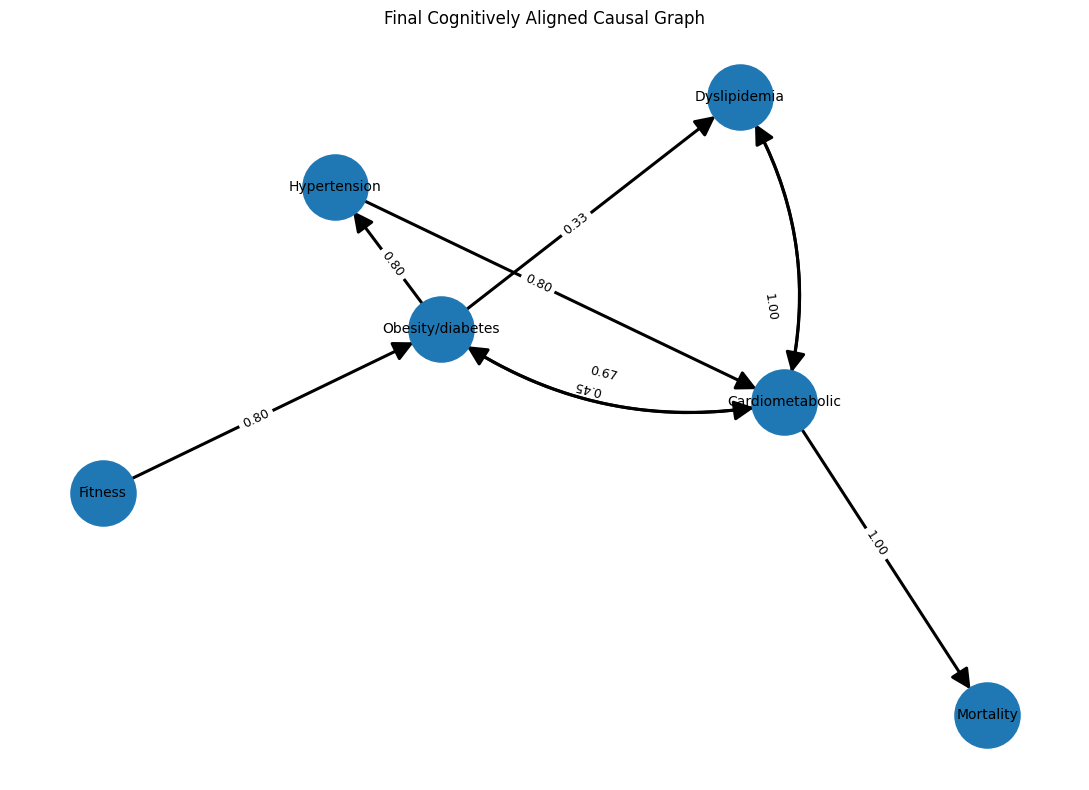

In [181]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Build graph
G = nx.DiGraph()

for _, row in cacg_edges_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["cacg_weight"]
    )

# Figure setup
plt.figure(figsize=(11, 8))
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2200
)

# Draw node labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

# Edges that need curvature for clarity
curved_edges_positive = [
    ("Cardiometabolic", "Dyslipidemia"),
    ("Obesity/diabetes", "Cardiometabolic")
]

curved_edges_negative = [
    ("Dyslipidemia", "Cardiometabolic"),
    ("Cardiometabolic", "Obesity/diabetes")
]

curved_edges = curved_edges_positive + curved_edges_negative

# Keep only edges that actually exist in G
curved_edges_positive = [e for e in curved_edges_positive if G.has_edge(*e)]
curved_edges_negative = [e for e in curved_edges_negative if G.has_edge(*e)]
curved_edges = curved_edges_positive + curved_edges_negative

straight_edges = [e for e in G.edges() if e not in curved_edges]

# Draw straight edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=straight_edges,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=2.2,
    min_source_margin=15,
    min_target_margin=22
)

# Draw curved edges, positive curve
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=curved_edges_positive,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=2.2,
    min_source_margin=15,
    min_target_margin=22,
    connectionstyle="arc3,rad=0.22"
)

# Draw curved edges, negative curve
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=curved_edges_negative,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=2.2,
    min_source_margin=15,
    min_target_margin=22,
    connectionstyle="arc3,rad=-0.22"
)

# Edge labels
edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
}

# Labels for straight edges, excluding the problematic overlapping pair
problematic_edges = [
    ("Obesity/diabetes", "Cardiometabolic"),
    ("Cardiometabolic", "Obesity/diabetes")
]

regular_straight_labels = {
    e: edge_labels[e]
    for e in straight_edges
    if e not in problematic_edges
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=regular_straight_labels,
    font_size=9,
    label_pos=0.45,
    rotate=True
)

# Labels for curved edges except the problematic pair
regular_curved_labels_positive = {
    e: edge_labels[e]
    for e in curved_edges_positive
    if e not in problematic_edges
}

regular_curved_labels_negative = {
    e: edge_labels[e]
    for e in curved_edges_negative
    if e not in problematic_edges
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=regular_curved_labels_positive,
    font_size=9,
    label_pos=0.30,
    rotate=True
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=regular_curved_labels_negative,
    font_size=9,
    label_pos=0.70,
    rotate=True
)

# Manual labels for Obesity/diabetes and Cardiometabolic edges
def draw_manual_edge_label(u, v, text, offset=(0.0, 0.0), fontsize=9):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    # midpoint
    x = (x1 + x2) / 2 + offset[0]
    y = (y1 + y2) / 2 + offset[1]

    # angle of edge
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))

    plt.text(
        x,
        y,
        text,
        fontsize=fontsize,
        rotation=angle,
        rotation_mode="anchor",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.5
        )
    )

# Separate the overlapping labels clearly
if G.has_edge("Obesity/diabetes", "Cardiometabolic"):
    draw_manual_edge_label(
        "Obesity/diabetes",
        "Cardiometabolic",
        edge_labels[("Obesity/diabetes", "Cardiometabolic")],
        offset=(-0.02, -0.02)
    )

if G.has_edge("Cardiometabolic", "Obesity/diabetes"):
    draw_manual_edge_label(
        "Cardiometabolic",
        "Obesity/diabetes",
        edge_labels[("Cardiometabolic", "Obesity/diabetes")],
        offset=(-0.055, -0.055)
    )

# Title and layout
plt.title("Final Cognitively Aligned Causal Graph")
plt.axis("off")
plt.tight_layout()

# Optional: save high-quality PNG for Overleaf
plt.savefig(
    "final_cacg_graph.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [161]:
patient_concepts_df.to_excel("stage6_calibrated_cacgv3_patient_concepts.xlsx", index=False)
patient_direct_drivers_df.to_excel("stage6_calibrated_cacgv3_direct_drivers.xlsx", index=False)
patient_mediated_paths_df.to_excel("stage6_calibrated_cacgv3_mediated_paths.xlsx", index=False)
counterfactual_df.to_excel("stage6_calibrated_cacgv3_counterfactuals.xlsx", index=False)
cacg_edges_df.to_excel("stage6_calibrated_cacgv3_edges.xlsx", index=False)

print("Saved stage6_calibrated_cacgv3_patient_concepts.xlsx")
print("Saved stage6_calibrated_cacgv3_direct_drivers.xlsx")
print("Saved stage6_calibrated_cacgv3_mediated_paths.xlsx")
print("Saved stage6_calibrated_cacgv3_counterfactuals.xlsx")
print("Saved stage6_calibrated_cacgv3_edges.xlsx")

Saved stage6_calibrated_cacgv3_patient_concepts.xlsx
Saved stage6_calibrated_cacgv3_direct_drivers.xlsx
Saved stage6_calibrated_cacgv3_mediated_paths.xlsx
Saved stage6_calibrated_cacgv3_counterfactuals.xlsx
Saved stage6_calibrated_cacgv3_edges.xlsx


# Step 7: VALIDATION AND EVALUATION 

In [162]:
# Stage 7 setup for calibrated CACG-V3

print("Final calibrated CACG-V3 edges:")
display(cacg_v3_compare_df)

print("Calibrated CACG-V3 concept weights:")
display(cacg_v3_calibrated_weight_df)

print("Patient concept values:")
display(patient_concepts_df)

print("Calibrated CACG-V3 counterfactual suggestions:")
display(counterfactual_df)

Final calibrated CACG-V3 edges:


,source,target,graph_weight,edge,graph_name
0,Dyslipidemia,Cardiometabolic,1.000000,Dyslipidemia -> Cardiometabolic,CACG_v3
1,Obesity/diabetes,Cardiometabolic,0.668887,Obesity/diabetes -> Cardiometabolic,CACG_v3
2,Hypertension,Cardiometabolic,0.800000,Hypertension -> Cardiometabolic,CACG_v3
3,Obesity/diabetes,Dyslipidemia,0.333854,Obesity/diabetes -> Dyslipidemia,CACG_v3
4,Cardiometabolic,Dyslipidemia,0.962132,Cardiometabolic -> Dyslipidemia,CACG_v3
5,Obesity/diabetes,Hypertension,0.800000,Obesity/diabetes -> Hypertension,CACG_v3
6,Cardiometabolic,Mortality,1.000000,Cardiometabolic -> Mortality,CACG_v3
7,Cardiometabolic,Obesity/diabetes,0.446242,Cardiometabolic -> Obesity/diabetes,CACG_v3
8,Fitness,Obesity/diabetes,0.800000,Fitness -> Obesity/diabetes,CACG_v3


Calibrated CACG-V3 concept weights:


,concept,cacg_path_strength_norm,linear_surrogate_coef,linear_surrogate_strength_norm,calibration_alpha,calibrated_weight,abs_calibrated_weight
0,Fitness,0.800000,-0.146886,0.699271,0.7,-0.768346,0.768346
1,Cardiometabolic,0.608739,0.210056,1.000000,0.7,0.706483,0.706483
2,Obesity/diabetes,1.000000,-0.064354,0.306368,0.7,-0.701250,0.701250
3,Dyslipidemia,0.608739,-0.127256,0.605817,0.7,-0.607861,0.607861
4,Hypertension,0.486991,0.113461,0.540146,0.7,0.502363,0.502363


Patient concept values:


,concept,value
0,Fitness,1.046449
2,Obesity/diabetes,-0.301759
1,Hypertension,-0.553984
4,Cardiometabolic,-0.610869
3,Dyslipidemia,-0.765424


Calibrated CACG-V3 counterfactual suggestions:


,type,concept,suggested_change,expected_effect,cacg_basis,evidence,calibrated_weight,driver_score,path_score
0,direct,Cardiometabolic,Improve Cardiometabolic by +2 SD,Directly decrease mortality risk,Cardiometabolic -> Mortality,ACE_high_minus_low = -0.003599,0.706483,-0.431569,NaN
1,mediated,Dyslipidemia,Improve Dyslipidemia by +2 SD,May reduce mortality risk indirectly through C...,Dyslipidemia -> Cardiometabolic -> Mortality,path_weight = 1.000,-0.607861,NaN,0.016851
2,mediated,Obesity/diabetes,Improve Obesity/diabetes by +2 SD,May reduce mortality risk indirectly through C...,Obesity/diabetes -> Cardiometabolic -> Mortality,path_weight = 0.669,-0.701250,NaN,-0.073564
3,mediated,Hypertension,Improve Hypertension by +2 SD,May reduce mortality risk indirectly through C...,Hypertension -> Cardiometabolic -> Mortality,path_weight = 0.800,0.502363,NaN,-0.283948


In [163]:
# Step 7.1: Faithfulness check using calibrated CACG-V3 counterfactual suggestions

faithfulness_rows = []

baseline_proba_all = clf.predict_proba(X_test)[:, 1]
baseline_mean_proba = baseline_proba_all.mean()

for _, row in counterfactual_df.iterrows():
    concept = row["concept"]
    suggestion = row["suggested_change"]
    expected_effect_text = row["expected_effect"]

    # infer intervention magnitude from suggestion text
    if "+2 SD" in suggestion:
        alpha_val = 2.0
    elif "-2 SD" in suggestion:
        alpha_val = -2.0
    elif "+1 SD" in suggestion:
        alpha_val = 1.0
    elif "-1 SD" in suggestion:
        alpha_val = -1.0
    else:
        alpha_val = None

    if alpha_val is None:
        continue

    X_cf = intervene_on_concept(
        X_test.copy(),
        concept,
        alpha_val,
        concept_dict_X,
        concept_feature_stats
    )

    cf_proba_all = clf.predict_proba(X_cf)[:, 1]
    cf_mean_proba = cf_proba_all.mean()
    delta_proba = cf_mean_proba - baseline_mean_proba

    effect_text = expected_effect_text.lower()

    if ("decrease mortality risk" in effect_text) or ("reduce mortality risk" in effect_text):
        expected_direction = "decrease"
        faithfulness_pass = int(delta_proba < 0)
    elif "increase mortality risk" in effect_text:
        expected_direction = "increase"
        faithfulness_pass = int(delta_proba > 0)
    else:
        expected_direction = "unknown"
        faithfulness_pass = 0

    faithfulness_rows.append({
        "concept": concept,
        "suggested_change": suggestion,
        "expected_effect": expected_effect_text,
        "baseline_mean_proba": baseline_mean_proba,
        "counterfactual_mean_proba": cf_mean_proba,
        "delta_mean_proba": delta_proba,
        "expected_direction": expected_direction,
        "faithfulness_pass": faithfulness_pass,
        "cacg_basis": row["cacg_basis"],
        "calibrated_weight": row.get("calibrated_weight", None)
    })

faithfulness_check_df = pd.DataFrame(faithfulness_rows)
faithfulness_check_df

,concept,suggested_change,expected_effect,baseline_mean_proba,counterfactual_mean_proba,delta_mean_proba,expected_direction,faithfulness_pass,cacg_basis,calibrated_weight
0,Cardiometabolic,Improve Cardiometabolic by +2 SD,Directly decrease mortality risk,0.370806,0.369155,-0.001651,decrease,1,Cardiometabolic -> Mortality,0.706483
1,Dyslipidemia,Improve Dyslipidemia by +2 SD,May reduce mortality risk indirectly through C...,0.370806,0.369155,-0.001651,decrease,1,Dyslipidemia -> Cardiometabolic -> Mortality,-0.607861
2,Obesity/diabetes,Improve Obesity/diabetes by +2 SD,May reduce mortality risk indirectly through C...,0.370806,0.369155,-0.001651,decrease,1,Obesity/diabetes -> Cardiometabolic -> Mortality,-0.701250
3,Hypertension,Improve Hypertension by +2 SD,May reduce mortality risk indirectly through C...,0.370806,0.370806,0.000000,decrease,0,Hypertension -> Cardiometabolic -> Mortality,0.502363


In [164]:
faithfulness_check_df.to_excel(
    "stage7_calibrated_cacgv3_faithfulness_check.xlsx",
    index=False
)

print("Saved stage7_calibrated_cacgv3_faithfulness_check.xlsx")

Saved stage7_calibrated_cacgv3_faithfulness_check.xlsx


In [165]:
# Faithfulness summary for calibrated CACG-V3

if len(faithfulness_check_df) > 0:
    faithfulness_rate = faithfulness_check_df["faithfulness_pass"].mean()
else:
    faithfulness_rate = 0.0

print("Baseline mean probability:", baseline_mean_proba)
print("Number of calibrated CACG-V3 counterfactual suggestions tested:", len(faithfulness_check_df))
print("Faithfulness rate:", faithfulness_rate)
print("Faithfulness:")
print(f"Calibrated CACG-V3 counterfactual suggestions matching model response: {faithfulness_rate:.3f}")
print(f"Number of suggestions tested: {len(faithfulness_check_df)}")

Baseline mean probability: 0.3708058433170031
Number of calibrated CACG-V3 counterfactual suggestions tested: 4
Faithfulness rate: 0.75
Faithfulness:
Calibrated CACG-V3 counterfactual suggestions matching model response: 0.750
Number of suggestions tested: 4


In [166]:
counterfactual_df["suggested_change"]

0     Improve Cardiometabolic by +2 SD
1        Improve Dyslipidemia by +2 SD
2    Improve Obesity/diabetes by +2 SD
3        Improve Hypertension by +2 SD
Name: suggested_change, dtype: str

In [167]:
faithfulness_check_df.to_excel("stage7_faithfulness_check.xlsx", index=False)
print("Saved stage7_faithfulness_check.xlsx")

Saved stage7_faithfulness_check.xlsx


Step 7.2 cognitive alignment check

The proposal says to evaluate whether the explanation matches clinical reasoning. Since your HCG is the proxy for human reasoning, a practical check is to compare edge overlap of CACG vs HCG and MCG vs HCG.

In [168]:
# Step 7.2: Cognitive alignment check using calibrated CACG-V3 edge structure

mcg_edges_set = set(mcg_df["edge"])
hcg_edges_set = set(hcg_df["edge"])

# Use calibrated CACG-V3 graph structure
if "edge" not in cacg_v3_compare_df.columns:
    cacg_v3_compare_df["edge"] = (
        cacg_v3_compare_df["source"] + " -> " + cacg_v3_compare_df["target"]
    )

cacg_v3_edges_set = set(cacg_v3_compare_df["edge"])

mcg_hcg_overlap = len(mcg_edges_set.intersection(hcg_edges_set))
cacg_v3_hcg_overlap = len(cacg_v3_edges_set.intersection(hcg_edges_set))
total_hcg_edges = len(hcg_edges_set)

mcg_alignment_ratio = mcg_hcg_overlap / total_hcg_edges if total_hcg_edges > 0 else 0.0
cacg_v3_alignment_ratio = cacg_v3_hcg_overlap / total_hcg_edges if total_hcg_edges > 0 else 0.0

alignment_improvement = cacg_v3_alignment_ratio - mcg_alignment_ratio

print("MCG-HCG overlap:", mcg_hcg_overlap)
print("Calibrated CACG-V3-HCG overlap:", cacg_v3_hcg_overlap)
print("Total HCG edges:", total_hcg_edges)
print("MCG cognitive alignment ratio:", mcg_alignment_ratio)
print("Calibrated CACG-V3 cognitive alignment ratio:", cacg_v3_alignment_ratio)
print("Alignment improvement:", alignment_improvement)

MCG-HCG overlap: 2
Calibrated CACG-V3-HCG overlap: 6
Total HCG edges: 6
MCG cognitive alignment ratio: 0.3333333333333333
Calibrated CACG-V3 cognitive alignment ratio: 1.0
Alignment improvement: 0.6666666666666667


In [169]:
# Cognitive alignment summary table for calibrated CACG-V3

cognitive_alignment_df = pd.DataFrame([
    {
        "graph": "MCG",
        "overlap_with_HCG": mcg_hcg_overlap,
        "total_HCG_edges": total_hcg_edges,
        "alignment_ratio": mcg_alignment_ratio
    },
    {
        "graph": "Calibrated CACG-V3",
        "overlap_with_HCG": cacg_v3_hcg_overlap,
        "total_HCG_edges": total_hcg_edges,
        "alignment_ratio": cacg_v3_alignment_ratio
    },
    {
        "graph": "Improvement",
        "overlap_with_HCG": None,
        "total_HCG_edges": None,
        "alignment_ratio": alignment_improvement
    }
])

display(cognitive_alignment_df)

cognitive_alignment_df.to_excel(
    "stage7_calibrated_cacgv3_cognitive_alignment_check.xlsx",
    index=False
)

print("Saved stage7_calibrated_cacgv3_cognitive_alignment_check.xlsx")

,graph,overlap_with_HCG,total_HCG_edges,alignment_ratio
0,MCG,2.0,6.0,0.333333
1,Calibrated CACG-V3,6.0,6.0,1.000000
2,Improvement,NaN,NaN,0.666667


Saved stage7_calibrated_cacgv3_cognitive_alignment_check.xlsx


LLM INPUT:
"Evaluate whether the following explanation of a model's intervention effects aligns with clinical reasoning: 'Improving cardiometabolic health by +2 SD is expected to directly decrease mortality risk. Additionally, improving mediators like dyslipidemia, hypertension, and obesity/diabetes by +2 SD is expected to indirectly reduce mortality risk through their effects on cardiometabolic health.' Provide feedback on the clinical plausibility and alignment of these explanations with medical guidelines." avoid unnecessary detail and remain to the point


LLM OUTPUT:
The explanation is clinically plausible. Improving cardiometabolic health (e.g., blood pressure, cholesterol, and glucose metabolism) is well-established in reducing mortality risk, particularly related to cardiovascular diseases and diabetes. The proposed indirect effect of improving mediators like dyslipidemia, hypertension, and obesity/diabetes aligns with clinical understanding, as these factors are key components of cardiometabolic health and their improvement is linked to reduced mortality risk through better management of underlying conditions.

Step 7.3 robustness test, alpha sensitivity

The proposal asks to test intervention stability and stable causal edges. A practical robustness check is to recompute direct concept effects at different alpha magnitudes.

In [170]:
# Step 7.3 final calibrated CACG-V3 robustness block
# This block recomputes robustness_effects_df, filters it to calibrated CACG-V3 explanation concepts,
# creates pivot/rank tables, and saves all outputs.

import pandas as pd

# Recompute direct concept effects across intervention magnitudes
def compute_direct_concept_effects_for_alpha(
    alpha_value,
    X_base,
    concept_dict_X,
    concept_feature_stats,
    clf,
    baseline_proba
):
    rows = []

    for concept, cols in concept_dict_X.items():
        X_low = intervene_on_concept(
            X_base,
            concept,
            -alpha_value,
            concept_dict_X,
            concept_feature_stats
        )

        X_high = intervene_on_concept(
            X_base,
            concept,
            +alpha_value,
            concept_dict_X,
            concept_feature_stats
        )

        proba_low = clf.predict_proba(X_low)[:, 1]
        proba_high = clf.predict_proba(X_high)[:, 1]

        rows.append({
            "concept": concept,
            "alpha": alpha_value,
            "low_mean_proba": proba_low.mean(),
            "high_mean_proba": proba_high.mean(),
            "ACE_high_minus_low": proba_high.mean() - proba_low.mean()
        })

    return pd.DataFrame(rows)


# Intervention magnitudes used for robustness checking
robust_alpha_list = [1.0, 2.0]

# Baseline prediction probability on test set
baseline_proba = clf.predict_proba(X_test)[:, 1].mean()

# Create robustness_effects_df
robustness_frames = []

for alpha_value in robust_alpha_list:
    df_alpha = compute_direct_concept_effects_for_alpha(
        alpha_value,
        X_test,
        concept_dict_X,
        concept_feature_stats,
        clf,
        baseline_proba
    )
    robustness_frames.append(df_alpha)

robustness_effects_df = pd.concat(robustness_frames, ignore_index=True)


# Keep robustness view focused on calibrated CACG-V3 explanation concepts
calibrated_explanation_concepts = counterfactual_df["concept"].dropna().unique().tolist()

robustness_effects_calibrated_df = robustness_effects_df[
    robustness_effects_df["concept"].isin(calibrated_explanation_concepts)
].copy()


# Pivot effect sizes by intervention magnitude
robustness_pivot_df = robustness_effects_calibrated_df.pivot(
    index="concept",
    columns="alpha",
    values="ACE_high_minus_low"
)


# Rank stability by alpha
robustness_ranks_df = robustness_effects_calibrated_df.copy()
robustness_ranks_df["abs_effect"] = robustness_ranks_df["ACE_high_minus_low"].abs()

robustness_ranks_df["rank_within_alpha"] = robustness_ranks_df.groupby("alpha")["abs_effect"].rank(
    ascending=False,
    method="dense"
)

robustness_rank_pivot_df = robustness_ranks_df.pivot(
    index="concept",
    columns="alpha",
    values="rank_within_alpha"
)


print("Calibrated CACG-V3 robustness effects:")
display(robustness_effects_calibrated_df)

print("Effect sizes by alpha:")
display(robustness_pivot_df)

print("Ranks by alpha:")
display(robustness_rank_pivot_df)


# Save calibrated CACG-V3 robustness files
robustness_effects_calibrated_df.to_excel(
    "stage7_calibrated_cacgv3_robustness_effects.xlsx",
    index=False
)

robustness_pivot_df.to_excel(
    "stage7_calibrated_cacgv3_robustness_effects_pivot.xlsx"
)

robustness_rank_pivot_df.to_excel(
    "stage7_calibrated_cacgv3_robustness_ranks.xlsx"
)

print("Saved stage7_calibrated_cacgv3_robustness_effects.xlsx")
print("Saved stage7_calibrated_cacgv3_robustness_effects_pivot.xlsx")
print("Saved stage7_calibrated_cacgv3_robustness_ranks.xlsx")

Calibrated CACG-V3 robustness effects:


,concept,alpha,low_mean_proba,high_mean_proba,ACE_high_minus_low
1,Hypertension,1.0,0.370806,0.370806,0.000000
2,Obesity/diabetes,1.0,0.372073,0.369698,-0.002375
3,Dyslipidemia,1.0,0.372073,0.369698,-0.002375
4,Cardiometabolic,1.0,0.372073,0.369698,-0.002375
6,Hypertension,2.0,0.370806,0.370806,0.000000
7,Obesity/diabetes,2.0,0.372754,0.369155,-0.003599
8,Dyslipidemia,2.0,0.372754,0.369155,-0.003599
9,Cardiometabolic,2.0,0.372754,0.369155,-0.003599


Effect sizes by alpha:


alpha,1.0,2.0
concept,,
Cardiometabolic,-0.002375,-0.003599
Dyslipidemia,-0.002375,-0.003599
Hypertension,0.000000,0.000000
Obesity/diabetes,-0.002375,-0.003599


Ranks by alpha:


alpha,1.0,2.0
concept,,
Cardiometabolic,1.0,1.0
Dyslipidemia,1.0,1.0
Hypertension,2.0,2.0
Obesity/diabetes,1.0,1.0


Saved stage7_calibrated_cacgv3_robustness_effects.xlsx
Saved stage7_calibrated_cacgv3_robustness_effects_pivot.xlsx
Saved stage7_calibrated_cacgv3_robustness_ranks.xlsx


In [171]:
# Keep robustness view focused on calibrated CACG-V3 explanation concepts

calibrated_explanation_concepts = counterfactual_df["concept"].dropna().unique().tolist()

robustness_effects_calibrated_df = robustness_effects_df[
    robustness_effects_df["concept"].isin(calibrated_explanation_concepts)
].copy()

display(robustness_effects_calibrated_df)

,concept,alpha,low_mean_proba,high_mean_proba,ACE_high_minus_low
1,Hypertension,1.0,0.370806,0.370806,0.000000
2,Obesity/diabetes,1.0,0.372073,0.369698,-0.002375
3,Dyslipidemia,1.0,0.372073,0.369698,-0.002375
4,Cardiometabolic,1.0,0.372073,0.369698,-0.002375
6,Hypertension,2.0,0.370806,0.370806,0.000000
7,Obesity/diabetes,2.0,0.372754,0.369155,-0.003599
8,Dyslipidemia,2.0,0.372754,0.369155,-0.003599
9,Cardiometabolic,2.0,0.372754,0.369155,-0.003599


In [172]:
# Robustness ranking stability for calibrated CACG-V3 explanation concepts

robustness_ranks_df = robustness_effects_calibrated_df.copy()
robustness_ranks_df["abs_effect"] = robustness_ranks_df["ACE_high_minus_low"].abs()
robustness_ranks_df["rank_within_alpha"] = robustness_ranks_df.groupby("alpha")["abs_effect"].rank(
    ascending=False,
    method="dense"
)

display(robustness_ranks_df.sort_values(["alpha", "rank_within_alpha"]))

,concept,alpha,low_mean_proba,high_mean_proba,ACE_high_minus_low,abs_effect,rank_within_alpha
2,Obesity/diabetes,1.0,0.372073,0.369698,-0.002375,0.002375,1.0
3,Dyslipidemia,1.0,0.372073,0.369698,-0.002375,0.002375,1.0
4,Cardiometabolic,1.0,0.372073,0.369698,-0.002375,0.002375,1.0
1,Hypertension,1.0,0.370806,0.370806,0.000000,0.000000,2.0
7,Obesity/diabetes,2.0,0.372754,0.369155,-0.003599,0.003599,1.0
8,Dyslipidemia,2.0,0.372754,0.369155,-0.003599,0.003599,1.0
9,Cardiometabolic,2.0,0.372754,0.369155,-0.003599,0.003599,1.0
6,Hypertension,2.0,0.370806,0.370806,0.000000,0.000000,2.0


In [173]:
robustness_effects_calibrated_df.to_excel(
    "stage7_calibrated_cacgv3_robustness_effects.xlsx",
    index=False
)

robustness_pivot_df.to_excel(
    "stage7_calibrated_cacgv3_robustness_effects_pivot.xlsx"
)

robustness_rank_pivot_df.to_excel(
    "stage7_calibrated_cacgv3_robustness_ranks.xlsx"
)

print("Saved calibrated CACG-V3 robustness files")

Saved calibrated CACG-V3 robustness files


In [174]:
# Final Step 7 summary for calibrated CACG-V3

print("STEP 7 SUMMARY")
print("----------------")

print("\nFaithfulness:")
print(f"Calibrated CACG-V3 counterfactual suggestions matching model response: {faithfulness_rate:.3f}")
print(f"Number of suggestions tested: {len(faithfulness_check_df)}")

print("\nCognitive alignment:")
print(f"MCG alignment ratio with HCG: {mcg_alignment_ratio:.3f}")
print(f"Calibrated CACG-V3 alignment ratio with HCG: {cacg_v3_alignment_ratio:.3f}")
print(f"Alignment improvement: {alignment_improvement:.3f}")

print("\nRobustness:")
print("Concept effects for calibrated CACG-V3 explanation concepts were evaluated across alpha = 1.0 and 2.0.")

STEP 7 SUMMARY
----------------

Faithfulness:
Calibrated CACG-V3 counterfactual suggestions matching model response: 0.750
Number of suggestions tested: 4

Cognitive alignment:
MCG alignment ratio with HCG: 0.333
Calibrated CACG-V3 alignment ratio with HCG: 1.000
Alignment improvement: 0.667

Robustness:
Concept effects for calibrated CACG-V3 explanation concepts were evaluated across alpha = 1.0 and 2.0.
